# pI plasticity and relationship to pH and Salinity

In [2]:

import pandas as pd, numpy as np

filtered_All_envs_df_with_metadata = pd.read_pickle(
    "/Users/skoog/Desktop/filtered_All_envs_df_with_metadata.pkl")

if "Average_pI" not in filtered_All_envs_df_with_metadata.columns:
    filtered_All_envs_df_with_metadata["Average_pI"] = filtered_All_envs_df_with_metadata["Median_pI"]

def wquantile(v, w, q):
    v = np.asarray(v, float); w = np.asarray(w, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0); v, w = v[m], w[m]
    if v.size == 0: return float("nan")
    o = np.argsort(v); v, w = v[o], w[o]; cw = np.cumsum(w) - 0.5 * w; cw /= w.sum()
    return float(np.interp(q, cw, v))

_df = filtered_All_envs_df_with_metadata
print(f"loaded {len(_df):,} viruses | {_df['name_full'].nunique()} lakes | "
      f"{_df['family'].nunique()} families | {_df['Environment_Bin'].nunique()} environment bins")
print("freshwater lakes present:",
      sorted(_df.loc[_df['Environment_Bin'] == 'Freshwater', 'name_full'].unique()))

ENV_PALETTE = {
    "Acidic lake":                 "#D73027",   
    "Acid-brine lakes (WATL)":     "#FC8D59",   
    "Freshwater":                  "#91CF60",   
    "Saline soda lake":            "#1A9850",   
    "Hypersaline soda lake":       "#4575B4",   
    "Alkaline-brine lakes (WATL)": "#762A83",   
    "Alkaline hydrothermal vent":  "#252525",   
    "Unclassified":                "#BDBDBD",   
}


loaded 9,040 viruses | 54 lakes | 51 families | 8 environment bins
freshwater lakes present: ['Lake Soyang', 'Lake Victoria', 'Malaren B']


In [3]:
# drop enveloped-virus families 
DROP_FAMILIES = {
    "Pleolipoviridae", "Poxviridae", "Lipothrixviridae", "Globuloviridae", "Bicaudaviridae", "Fuselloviridae",
    "Ascoviridae", "Kitaviridae", "Unclassified Pokkesviricetes", "Asfarviridae", "Unclassified Herpesvirales",
    "Herpesviridae", "Unclassified Lefavirales", "Unclassified Bunyavirales", "Tristromaviridae", "Baculoviridae",
    "Rhabdoviridae", "Unclassified Mononegavirales", "Unclassified Nidovirales", "Alloherpesviridae", "Mymonaviridae",
    "Cystoviridae", "Phenuiviridae", "Nudiviridae", "Unclassified Haloruvirales",
}

_before = len(filtered_All_envs_df_with_metadata)
_fam    = filtered_All_envs_df_with_metadata["family"].astype(str).str.strip()
_strip  = _fam.str.replace(r"^Unclassified\s+", "", regex=True)   # also catch "Unclassified <listed family>"
_drop   = _fam.isin(DROP_FAMILIES) | _strip.isin(DROP_FAMILIES)

_dropped = filtered_All_envs_df_with_metadata[_drop]
filtered_All_envs_df_with_metadata = filtered_All_envs_df_with_metadata[~_drop].reset_index(drop=True)
if "Average_pI" not in filtered_All_envs_df_with_metadata.columns:
    filtered_All_envs_df_with_metadata["Average_pI"] = filtered_All_envs_df_with_metadata["Median_pI"]

print(f"dropped {len(_dropped):,} enveloped-virus rows "
      f"({_before:,} -> {len(filtered_All_envs_df_with_metadata):,} viruses)")
if len(_dropped):
    print("by family:")
    print(_dropped["family"].astype(str).value_counts().to_string())

dropped 0 enveloped-virus rows (9,040 -> 9,040 viruses)


In [4]:

WATL_ONLY = False    

_UNINFORMATIVE = {"Unclassified", "Unknown", "nan", "NaN", "NA", ""}
_df = filtered_All_envs_df_with_metadata.copy()
_b = len(_df)

_env = _df["Environment_Bin"].astype(str).str.strip()
_df = _df[_df["Environment_Bin"].notna() & ~_env.isin(_UNINFORMATIVE)]
print(f"dropped {_b-len(_df):,} viruses with unclassified/missing Environment_Bin")

# drop the 'Unclassified'/'Unknown' FAMILY label 
_b2 = len(_df); _fam = _df["family"].astype(str).str.strip()
_df = _df[~_fam.isin(_UNINFORMATIVE)]
print(f"dropped {_b2-len(_df):,} viruses with a bare unclassified family label "
      f"(kept 'Unclassified <taxon>' catch-alls)")


df_ALL = _df.reset_index(drop=True).copy()
if "Average_pI" not in df_ALL.columns:
    df_ALL["Average_pI"] = df_ALL["Median_pI"]
print(f"df_ALL (all environments): {len(df_ALL):,} viruses | {df_ALL['Environment_Bin'].nunique()} environments")

#WATL-only subset
if WATL_ONLY:
    _b3 = len(_df)
    _df = _df[_df["Environment_Bin"].astype(str).str.contains("WATL")]
    print(f"WATL_ONLY: kept {len(_df):,} of {_b3:,} viruses")

filtered_All_envs_df_with_metadata = _df.reset_index(drop=True)
if "Average_pI" not in filtered_All_envs_df_with_metadata.columns:
    filtered_All_envs_df_with_metadata["Average_pI"] = filtered_All_envs_df_with_metadata["Median_pI"]

_d = filtered_All_envs_df_with_metadata
print(f"\nworking set: {len(_d):,} viruses | {_d['name_full'].nunique()} lakes | "
      f"{_d['family'].nunique()} families | {_d['Environment_Bin'].nunique()} environments")
print("environments:", sorted(_d['Environment_Bin'].unique()))

dropped 20 viruses with unclassified/missing Environment_Bin
dropped 40 viruses with a bare unclassified family label (kept 'Unclassified <taxon>' catch-alls)
df_ALL (all environments): 8,980 viruses | 7 environments

working set: 8,980 viruses | 53 lakes | 50 families | 7 environments
environments: ['Acid-brine lakes (WATL)', 'Acidic lake', 'Alkaline hydrothermal vent', 'Alkaline-brine lakes (WATL)', 'Freshwater', 'Hypersaline soda lake', 'Saline soda lake']


In [5]:
host_ecology = {
    # Thermophilic archaea
    
    "Rudiviridae": "Other Archaea",
    "Tristromaviridae": "Other Archaea",

    # Halophilic archaea
    
    "Sphaerolipoviridae": "Halophilic Archaea",
    "Pleolipoviridae": "Halophilic Archaea",
    "Hafunaviridae": "Halophilic Archaea",
    "Unclassified Vertoviridae": "Halophilic Archaea",
    "Vertoviridae": "Halophilic Archaea",
    "Halomagnusviridae": "Halophilic Archaea",     
    "Saparoviridae": "Halophilic Archaea",          
    "Unclassified Thumleimavirales": "Halophilic Archaea",  
    "Druskaviridae": "Halophilic Archaea",          
    "Graaviviridae": "Halophilic Archaea",          
    "Haloferuviridae": "Halophilic Archaea",       
    "Simuloviridae": "Halophilic Archaea",  
    
    # Giant viruses
    "Unclassified Pimascovirales": "Eukarya (giant viruses)",
    "Unclassified Megaviricetes": "Eukarya (giant viruses)",               
    "Allomimiviridae":     "Eukarya (giant viruses)",
    "Schizomimiviridae":   "Eukarya (giant viruses)",
    "Unclassified Algavirales": "Eukarya (giant viruses)",
    "Unclassified Imitervirales": "Eukarya (giant viruses)",
        "Mimiviridae": "Eukarya (giant viruses)",
    "Marseilleviridae": "Eukarya (giant viruses)",
    "Phycodnaviridae": "Eukarya (giant viruses)",
    "Iridoviridae": "Eukarya (vertebrates/ invertebrates)",
    "Asfarviridae": "Eukarya (vertebrates/ invertebrates)",
    "Pimascovirales": "Eukarya (giant viruses)",
    "Megaviricetes": "Eukarya (giant viruses)",

    
    # Bacterial 
    "Ackermannviridae": "Bacteria",
    "Autographiviridae": "Bacteria",
    "Casjensviridae": "Bacteria",
    "Corticoviridae": "Bacteria",
    "Demerecviridae": "Bacteria",
    "Drexlerviridae": "Bacteria",
    "Herelleviridae": "Bacteria",
    "Inoviridae": "Bacteria",
    "Mesyanzhinovviridae": "Bacteria",
    "Microviridae": "Bacteria",
    "Schitoviridae": "Bacteria",
    "Tectiviridae": "Bacteria",
    "Zobellviridae": "Bacteria",
    "Chaseviridae": "Bacteria",                    
    "Arenbergviridae": "Bacteria",                  
    "Naomviridae": "Bacteria",                     
    "Unclassified Vinavirales": "Bacteria", 
    "Unclassified Rountreeviridae": "Bacteria",
    "Unclassified Schitoviridae": "Bacteria",
    "Unclassified Straboviridae": "Bacteria",
    "Unclassified Tubulavirales": "Bacteria",
    "Unclassified Zobellviridae": "Bacteria",
    "Unclassified Ackermannviridae": "Bacteria",
    "Unclassified Autographiviridae": "Bacteria",
    "Unclassified Casjensviridae": "Bacteria",
    "Unclassified Caudoviricetes": "Bacteria",
    "Unclassified Chaseviridae": "Bacteria",
    "Unclassified Crassvirales": "Bacteria",
    "Unclassified Demerecviridae": "Bacteria",
    "Unclassified Drexlerviridae": "Bacteria",
    "Unclassified Guelinviridae": "Bacteria",
    "Unclassified Herelleviridae": "Bacteria",
    "Stanwilliamsviridae": "Bacteria",
    "Grimontviridae":      "Bacteria",
    "Pootjesviridae":      "Bacteria",
    "Unclassified Mesyanzhinovviridae": "Bacteria",
    "Unclassified Peduoviridae": "Bacteria",
    
    # Eukaryotic viruses
    "Herpesviridae": "Eukarya (vertebrates/ invertebrates)",
    "Adintoviridae": "Eukarya (vertebrates/ invertebrates)",
    "Unclassified Cressdnaviricota": "Eukarya (vertebrates/ invertebrates)",
    "Cressdnaviricota": "Eukarya (vertebrates/ invertebrates)",
    "Parvoviridae": "Eukarya (vertebrates/ invertebrates)",
    "Circoviridae": "Eukarya (vertebrates/ invertebrates)",
    "Smacoviridae": "Eukarya (vertebrates/ invertebrates)",
    
    "Tombusviridae": "Eukarya (Plants)",

    
    # Combination viruses
    "Unclassified Bamfordvirae": "Eukaryota, Archaea, and Bacteria",
    "Unclassified Preplasmiviricota": "Eukaryota, Archaea, and Bacteria",
    "Preplasmiviricota": "Eukaryota, Archaea, and Bacteria",
    
    "Kyanoviridae": "Bacteria and Archaea",
    "Straboviridae": "Bacteria and Archaea",
    "Unclassified Kyanoviridae": "Bacteria and Archaea",

    # Virophage
    "Unclassified Priklausovirales": "Virophage (GV-infected cells)",
    "Unclassified Maveriviricetes": "Virophage (GV-infected cells)",
    "Lavidaviridae": "Virophage (GV-infected cells)",


    # Unclassified (no family-level assignment)
    "Unclassified": "Unknown/Other",

    
    
}



In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from IPython.display import display

warnings.filterwarnings("ignore")

OUTDIR = "/Users/skoog/Desktop/"
os.makedirs(OUTDIR, exist_ok=True)

PICOL = "Median_pI"
WEIGHT_COL = "rpkm"
MIN_LAKES = 6
MIN_GENOMES_CV = 6
NBOOT_MODEL_PRIMARY = 1000
NBOOT_MODEL_SENSITIVITY = 200
NBOOT_CV = 2000
RANDOM_SEED = 7


def _weighted_quantile(values, weights, q=0.5):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[keep], weights[keep]
    if values.size == 0:
        return np.nan
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return float(np.interp(q, cumulative, values))


def _genome_key(frame):
    """Namespace-safe genome key: WATL vOTUs are shared; comparator ids are lake-scoped."""
    contig = frame["contig_id"].astype(str)
    lake = frame["name_full"].astype(str)
    return np.where(contig.str.startswith("WATLvirus"), contig, lake + "::" + contig)


def _safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    if len(x) < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan, np.nan
    result = spearmanr(x, y)
    return float(result.statistic), float(result.pvalue)


def _bootstrap_adjusted_r2(g, nboot, seed):
    """Lake bootstrap CI for adjusted R-squared from pI ~ pH + Salinity."""
    if nboot <= 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    estimates = []
    n = len(g)
    for _ in range(nboot):
        gg = g.iloc[rng.integers(0, n, size=n)]
        X = sm.add_constant(gg[["pH", "Salinity"]], has_constant="add")
        if len(gg) < 6 or np.linalg.matrix_rank(np.asarray(X, float)) < 3:
            continue
        try:
            fit = sm.OLS(gg["pI"], X).fit()
            if fit.df_resid > 0 and np.isfinite(fit.rsquared_adj):
                estimates.append(float(fit.rsquared_adj))
        except Exception:
            continue
    if len(estimates) < max(50, int(0.25 * nboot)):
        return np.nan, np.nan
    return tuple(np.percentile(estimates, [2.5, 97.5]).astype(float))


def _bootstrap_cv(values, nboot=2000, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2 or np.isclose(values.mean(), 0):
        return np.nan, np.nan, np.nan, np.nan
    raw = 100.0 * values.std(ddof=1) / abs(values.mean())
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(nboot):
        sample = values[rng.integers(0, len(values), size=len(values))]
        if not np.isclose(sample.mean(), 0):
            estimates.append(100.0 * sample.std(ddof=1) / abs(sample.mean()))
    if len(estimates) < 100:
        return raw, np.nan, np.nan, np.nan
    med, lo, hi = np.percentile(estimates, [50, 2.5, 97.5])
    return float(raw), float(med), float(lo), float(hi)


def _prepare_family_data(df):
    required = {PICOL, "pH", "Salinity", "family", "name_full", "Environment_Bin", "contig_id"}
    missing = sorted(required.difference(df.columns))
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    if WEIGHT_COL not in df.columns:
        raise KeyError(
            f"The weighted analysis requires a '{WEIGHT_COL}' column. "
            "Confirm that the unified pickle contains the mcf0.75 RPKM values."
        )

    d = df.copy()
    d["family"] = d["family"].astype(str).str.strip()
    for col in [PICOL, "pH", "Salinity", WEIGHT_COL]:
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d["_genome_key"] = _genome_key(d)
    d["Host_ecology"] = d["family"].map(host_ecology).fillna("Unknown/Other")
    d["Host_ecology"] = d["Host_ecology"].replace({"Thermophilic Archaea": "Other Archaea"})
    d["_is_wahl"] = d["Environment_Bin"].astype(str).str.upper().str.contains("WATL|WAHL", regex=True, na=False)
    d = d.dropna(subset=[PICOL, "pH", "Salinity", "family", "name_full", "Environment_Bin"])
    return d


def _family_lake_summaries(d, weighting):
    rows = []
    for (family, lake), g in d.groupby(["family", "name_full"], sort=False):
        values = g[PICOL].to_numpy(dtype=float)
        if weighting == "Unweighted median":
            pi_value = float(np.nanmedian(values))
        elif weighting == "RPKM-weighted median":
            pi_value = _weighted_quantile(values, g[WEIGHT_COL].to_numpy(dtype=float), 0.5)
        else:
            raise ValueError(f"Unknown weighting: {weighting}")
        rows.append({
            "family": family,
            "name_full": lake,
            "Environment_Bin": g["Environment_Bin"].dropna().iloc[0],
            "pI": pi_value,
            "pH": float(np.nanmedian(g["pH"])),
            "Salinity": float(np.nanmedian(g["Salinity"])),
            "n_genomes_lake": int(g["_genome_key"].nunique()),
            "total_RPKM_lake": float(g[WEIGHT_COL].where(g[WEIGHT_COL] > 0).sum()),
        })
    return pd.DataFrame(rows).dropna(subset=["pI", "pH", "Salinity"])


def build_family_tables(df):
    d0 = _prepare_family_data(df)
    model_rows = []
    primary_lake_table = None

    scenarios = [
        ("All environments", False),
        ("WAHL only", True),
    ]
    weighting_modes = ["Unweighted median", "RPKM-weighted median"]

    for scope_index, (scope, wahl_only) in enumerate(scenarios):
        d = d0[d0["_is_wahl"]].copy() if wahl_only else d0.copy()
        family_counts = d.groupby("family").agg(
            n_genomes=("_genome_key", "nunique"),
            n_environment_types=("Environment_Bin", "nunique"),
            host_ecology=("Host_ecology", "first"),
        )

        for weight_index, weighting in enumerate(weighting_modes):
            lake = _family_lake_summaries(d, weighting)
            if scope == "All environments" and weighting == "Unweighted median":
                primary_lake_table = lake.copy()

            for fam, g in lake.groupby("family"):
                n_lakes = int(g["name_full"].nunique())
                rho_ph, p_ph = _safe_spearman(g["pI"], g["pH"]) if n_lakes >= MIN_LAKES else (np.nan, np.nan)
                rho_sal, p_sal = _safe_spearman(g["pI"], g["Salinity"]) if n_lakes >= MIN_LAKES else (np.nan, np.nan)

                adj_r2 = aic = p_model = ci_lo = ci_hi = np.nan
                if n_lakes >= MIN_LAKES:
                    X = sm.add_constant(g[["pH", "Salinity"]], has_constant="add")
                    if np.linalg.matrix_rank(np.asarray(X, float)) == 3:
                        fit = sm.OLS(g["pI"], X).fit()
                        if fit.df_resid > 0:
                            adj_r2 = float(fit.rsquared_adj)
                            aic = float(fit.aic)
                            p_model = float(fit.f_pvalue) if np.isfinite(fit.f_pvalue) else np.nan
                            nboot = (
                                NBOOT_MODEL_PRIMARY
                                if scope == "All environments" and weighting == "Unweighted median"
                                else NBOOT_MODEL_SENSITIVITY
                            )
                            ci_lo, ci_hi = _bootstrap_adjusted_r2(
                                g,
                                nboot=nboot,
                                seed=RANDOM_SEED + 1000 * scope_index + 100 * weight_index + len(model_rows),
                            )

                count_row = family_counts.loc[fam]
                model_rows.append({
                    "scope": scope,
                    "weighting": weighting,
                    "family": fam,
                    "host_ecology": count_row["host_ecology"],
                    "n_lakes": n_lakes,
                    "n_environment_types": int(count_row["n_environment_types"]),
                    "n_unique_genomes": int(count_row["n_genomes"]),
                    "median_genomes_per_lake": float(g["n_genomes_lake"].median()),
                    "total_RPKM": float(g["total_RPKM_lake"].sum()),
                    "rho_pH": rho_ph,
                    "p_pH": p_ph,
                    "rho_salinity": rho_sal,
                    "p_salinity": p_sal,
                    "adjusted_R2": adj_r2,
                    "adjusted_R2_CI_low": ci_lo,
                    "adjusted_R2_CI_high": ci_hi,
                    "AIC": aic,
                    "p_model": p_model,
                })

    models = pd.DataFrame(model_rows)
    models["q_pH"] = np.nan
    models["q_salinity"] = np.nan
    models["q_model"] = np.nan

    for _, idx in models.groupby(["scope", "weighting"]).groups.items():
        idx = list(idx)
        for pcol, qcol in [("p_pH", "q_pH"), ("p_salinity", "q_salinity"), ("p_model", "q_model")]:
            pvals = models.loc[idx, pcol].to_numpy(dtype=float)
            valid = np.isfinite(pvals)
            if valid.any():
                models.loc[np.asarray(idx)[valid], qcol] = multipletests(pvals[valid], method="fdr_bh")[1]

    def _driver(row):
        p_h = pd.notna(row.q_pH) and row.q_pH < 0.05
        sal = pd.notna(row.q_salinity) and row.q_salinity < 0.05
        if p_h and sal:
            return "Both"
        if p_h:
            return "pH"
        if sal:
            return "Salinity"
        return "Neither"

    models["significant_correlate"] = models.apply(_driver, axis=1)

    # Plasticity is calculated once from UNIQUE viral genomes across all environments.
    unique_genomes = (
        d0.sort_values(WEIGHT_COL, ascending=False)
          .drop_duplicates("_genome_key")
          .copy()
    )
    unique_genomes = unique_genomes[
        ~unique_genomes["family"].str.casefold().isin({"unclassified", "unclassified caudoviricetes"})
    ]

    plasticity_rows = []
    for fam_index, (fam, g) in enumerate(unique_genomes.groupby("family")):
        raw, boot, lo, hi = _bootstrap_cv(
            g[PICOL].to_numpy(dtype=float),
            nboot=NBOOT_CV,
            seed=RANDOM_SEED + fam_index,
        )
        plasticity_rows.append({
            "family": fam,
            "host_ecology": g["Host_ecology"].iloc[0],
            "n_unique_genomes": int(g["_genome_key"].nunique()),
            "median_pI": float(np.nanmedian(g[PICOL])),
            "CV_raw": raw,
            "CV_bootstrap": boot,
            "CV_CI_low": lo,
            "CV_CI_high": hi,
        })

    plasticity = pd.DataFrame(plasticity_rows)
    plasticity_plot = plasticity[
        (plasticity["n_unique_genomes"] >= MIN_GENOMES_CV)
        & plasticity["CV_bootstrap"].notna()
    ].copy()

    if len(plasticity_plot) >= 3:
        rho_agree, p_agree = spearmanr(plasticity_plot["CV_raw"], plasticity_plot["CV_bootstrap"])
        rho_n, p_n = spearmanr(plasticity_plot["CV_bootstrap"], plasticity_plot["n_unique_genomes"])
        print(
            f"Plasticity diagnostics: raw vs stabilized rho={rho_agree:.3f}, p={p_agree:.3g}; "
            f"stabilized CV vs n rho={rho_n:.3f}, p={p_n:.3g}"
        )

    primary = models[
        (models["scope"] == "All environments")
        & (models["weighting"] == "Unweighted median")
        & (models["n_lakes"] >= MIN_LAKES)
    ].copy()

    models.to_csv(os.path.join(OUTDIR, "family_environment_models_all_scenarios.csv"), index=False)
    primary.to_csv(os.path.join(OUTDIR, "family_environment_models_primary.csv"), index=False)
    plasticity.to_csv(os.path.join(OUTDIR, "family_plasticity_bootstrap.csv"), index=False)
    primary_lake_table.to_csv(os.path.join(OUTDIR, "family_lake_medians_primary.csv"), index=False)

    xlsx_path = os.path.join(OUTDIR, "Figure4_family_analysis_tables.xlsx")
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        models.to_excel(writer, sheet_name="all_scenarios", index=False)
        primary.to_excel(writer, sheet_name="primary_Fig4", index=False)
        plasticity.to_excel(writer, sheet_name="plasticity", index=False)
        primary_lake_table.to_excel(writer, sheet_name="primary_lake_medians", index=False)

    print(f"Family models saved to: {xlsx_path}")
    print(f"Primary Figure 4 families: {len(primary)}")
    print(f"Plasticity families (n>={MIN_GENOMES_CV} unique genomes): {len(plasticity_plot)}")

    display(
        primary[[
            "family", "n_lakes", "n_environment_types", "n_unique_genomes",
            "rho_pH", "q_pH", "rho_salinity", "q_salinity",
            "adjusted_R2", "adjusted_R2_CI_low", "adjusted_R2_CI_high", "AIC", "q_model"
        ]].sort_values("adjusted_R2", ascending=False).round(3)
    )

    return models, primary, plasticity, plasticity_plot, primary_lake_table


family_models_all, family_models_primary, family_plasticity_all, family_plasticity_plot, family_lake_primary = build_family_tables(df_ALL)


Plasticity diagnostics: raw vs stabilized rho=1.000, p=1.09e-173; stabilized CV vs n rho=0.025, p=0.907
Family models saved to: /Users/skoog/Desktop/Figure4_family_analysis_tables.xlsx
Primary Figure 4 families: 14
Plasticity families (n>=6 unique genomes): 24


,family,n_lakes,n_environment_types,n_unique_genomes,rho_pH,q_pH,rho_salinity,q_salinity,adjusted_R2,adjusted_R2_CI_low,adjusted_R2_CI_high,AIC,q_model
13,Halomagnusviridae,11,2,26,-0.428,0.663,0.090,0.925,0.425,-0.202,0.918,-17.954,0.209
16,Kyanoviridae,19,3,153,-0.232,0.790,-0.390,0.576,0.317,-0.057,0.761,17.116,0.129
24,Saparoviridae,10,2,11,-0.097,0.973,-0.395,0.576,0.264,-0.023,0.983,-4.485,0.397
32,Unclassified Caudoviricetes,53,7,6376,-0.378,0.037,-0.263,0.576,0.226,0.083,0.492,16.228,0.009
2,Autographiviridae,20,3,42,-0.647,0.029,0.306,0.576,0.162,-0.029,0.675,13.282,0.301
41,Unclassified Megaviricetes,8,4,15,-0.822,0.057,-0.061,0.953,0.132,-0.185,0.989,29.638,0.706
11,Hafunaviridae,11,3,18,0.121,0.973,-0.231,0.797,-0.035,-0.199,0.913,16.389,0.722
29,Straboviridae,11,3,11,0.019,0.973,0.352,0.576,-0.060,-0.240,0.984,37.828,0.722
22,Phycodnaviridae,10,6,28,0.012,0.973,0.383,0.576,-0.069,-0.225,0.890,27.682,0.722
44,Unclassified Thumleimavirales,6,2,4,-0.372,0.936,0.338,0.797,-0.117,-276.653,1.000,-12.302,0.722


Looks like you are using an old matplotlib version.
               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


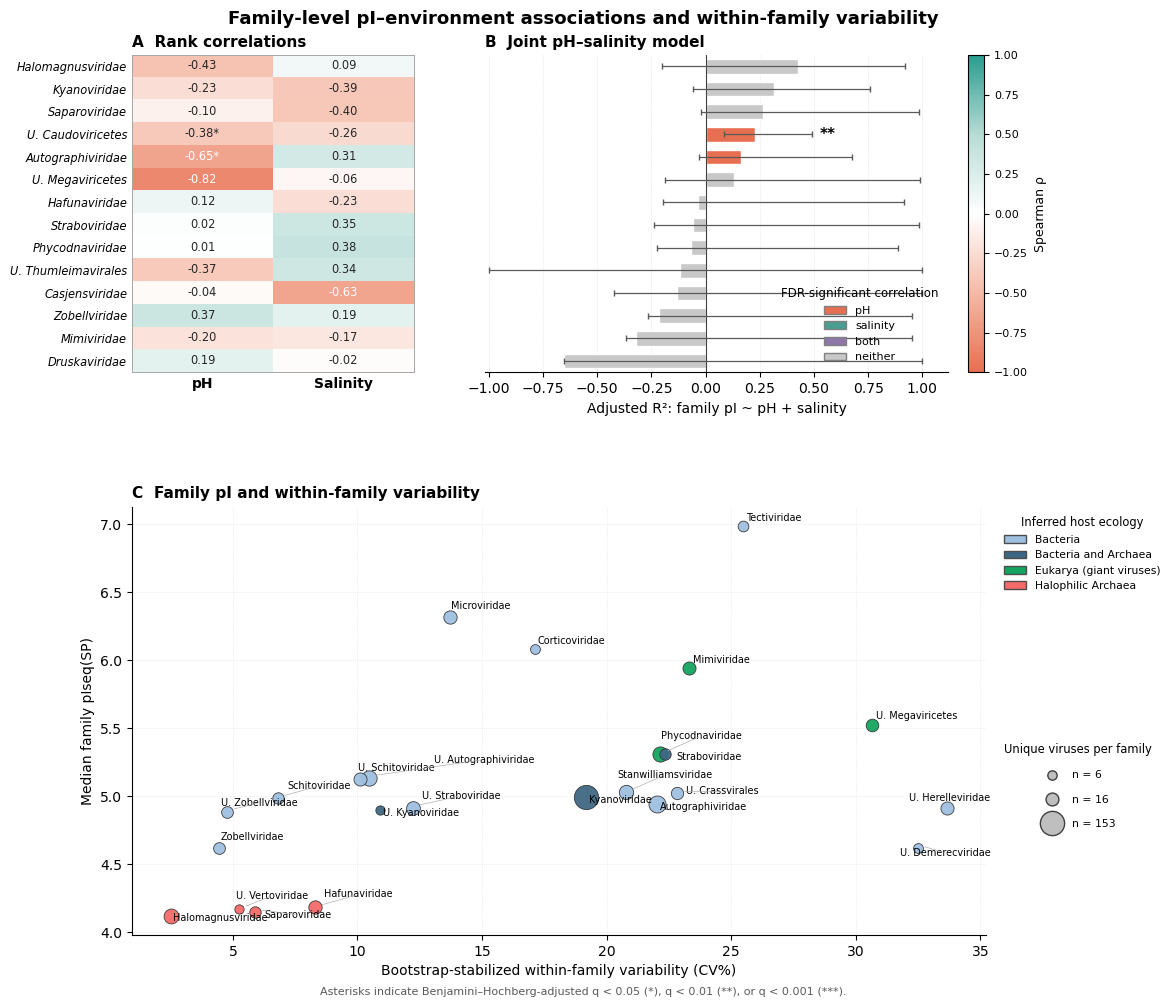

Saved:
/Users/skoog/Desktop/Figure_4_family_environment_variability.png
/Users/skoog/Desktop/Figure_4_family_environment_variability.svg


In [7]:


import os
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from adjustText import adjust_text
    HAVE_ADJUSTTEXT = True
except Exception:
    HAVE_ADJUSTTEXT = False

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "svg.fonttype": "none",
    "text.usetex": False,
})

HOST_COLORS = {
    "Bacteria": "#9FBFE0",
    "Bacteria and Archaea": "#3D6682",
    "Eukarya (giant viruses)": "#13A45F",
    "Eukarya (vertebrates/ invertebrates)": "#7F6B88",
    "Eukaryota, Archaea, and Bacteria": "#FFE46F",
    "Halophilic Archaea": "#F56969",
    "Other Archaea": "#09B0B2",
    "Virophage (GV-infected cells)": "#FD7C08",
    "Eukarya (Plants)": "#6050AF",
    "Unknown/Other": "#BDBDBD",
}

DRIVER_COLORS = {
    "pH": "#E76F51",
    "Salinity": "#4A9D8F",
    "Both": "#8D78A8",
    "Neither": "#C8C8C8",
}

RHO_CMAP = LinearSegmentedColormap.from_list(
    "rho_diverging",
    ["#E76F51", "#F5B9A6", "#FFFFFF", "#B8DCD6", "#2A9D8F"],
)


def _short_family(name):
    return str(name).replace("Unclassified ", "U. ")


def _sig_symbol(q):
    if pd.isna(q):
        return ""
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return ""


def plot_figure4(primary, plasticity, out_stem):
    fit = primary.sort_values("adjusted_R2", ascending=False).copy()
    order = fit["family"].tolist()
    fit = fit.set_index("family").loc[order]
    n_families = len(order)
    y = np.arange(n_families)

    fig = plt.figure(figsize=(12.2, 10.0))
    outer = gridspec.GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[1.0, 1.35],
        width_ratios=[0.72, 1.28],
        hspace=0.36,
        wspace=0.18,
    )
    ax_a = fig.add_subplot(outer[0, 0])
    ax_b = fig.add_subplot(outer[0, 1])
    ax_c = fig.add_subplot(outer[1, :])

#panel a

    heat = fit[["rho_pH", "rho_salinity"]].to_numpy(dtype=float)
    image = ax_a.imshow(heat, cmap=RHO_CMAP, vmin=-1, vmax=1, aspect="auto")
    for i, fam in enumerate(order):
        for j, (rho_col, q_col) in enumerate([
            ("rho_pH", "q_pH"),
            ("rho_salinity", "q_salinity"),
        ]):
            value = fit.loc[fam, rho_col]
            if np.isfinite(value):
                label = f"{value:.2f}{_sig_symbol(fit.loc[fam, q_col])}"
                color = "white" if abs(value) >= 0.58 else "0.15"
                ax_a.text(j, i, label, ha="center", va="center", fontsize=8.2, color=color)

    ax_a.set_xticks([0, 1])
    ax_a.set_xticklabels(["pH", "Salinity"], fontweight="bold")
    ax_a.set_yticks(y)
    ax_a.set_yticklabels([_short_family(f) for f in order], fontsize=8.2, fontstyle="italic")
    ax_a.set_ylim(n_families - 0.5, -0.5)
    ax_a.tick_params(length=0)
    ax_a.set_title("A  Rank correlations", loc="left", fontweight="bold", fontsize=11)
    for spine in ax_a.spines.values():
        spine.set_color("0.65")
        spine.set_linewidth(0.7)

#panel b
    values = fit["adjusted_R2"].to_numpy(dtype=float)
    lows = fit["adjusted_R2_CI_low"].to_numpy(dtype=float)
    highs = fit["adjusted_R2_CI_high"].to_numpy(dtype=float)
    bar_colors = [DRIVER_COLORS.get(fit.loc[f, "significant_correlate"], "#C8C8C8") for f in order]

    ax_b.barh(y, values, color=bar_colors, edgecolor="white", height=0.66, zorder=2)
    for i, fam in enumerate(order):
        if np.isfinite(lows[i]) and np.isfinite(highs[i]):
            lower_error = max(values[i] - max(lows[i], -1.0), 0)
            upper_error = max(min(highs[i], 1.0) - values[i], 0)
            ax_b.errorbar(
                values[i], i,
                xerr=np.array([[lower_error], [upper_error]]),
                fmt="none", ecolor="0.35", elinewidth=0.9, capsize=2.5, zorder=4,
            )
        symbol = _sig_symbol(fit.loc[fam, "q_model"])
        if symbol:
            x_text = min(highs[i], 1.0) + 0.035 if np.isfinite(highs[i]) else values[i] + 0.035
            ax_b.text(x_text, i, symbol, va="center", fontsize=11, fontweight="bold")

    ax_b.axvline(0, color="0.25", lw=0.8)
    ax_b.set_yticks(y)
    ax_b.set_yticklabels([])
    ax_b.set_ylim(n_families - 0.5, -0.5)
    ax_b.set_xlim(-1.02, 1.12)
    ax_b.set_xlabel("Adjusted R²: family pI ~ pH + salinity")
    ax_b.set_title("B  Joint pH–salinity model", loc="left", fontweight="bold", fontsize=11)
    ax_b.grid(axis="x", ls=":", lw=0.5, color="0.85")
    ax_b.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax_b.spines[spine].set_visible(False)
    ax_b.tick_params(axis="y", length=0)

    colorbar = fig.colorbar(image, ax=ax_b, fraction=0.035, pad=0.04)
    colorbar.set_label("Spearman ρ", fontsize=9)
    colorbar.ax.tick_params(labelsize=8)

    driver_handles = [
        Patch(facecolor=DRIVER_COLORS[key], edgecolor="0.5", label=label)
        for key, label in [
            ("pH", "pH"),
            ("Salinity", "salinity"),
            ("Both", "both"),
            ("Neither", "neither"),
        ]
    ]
    ax_b.legend(
        handles=driver_handles,
        title="FDR-significant correlation",
        loc="lower right",
        frameon=False,
        fontsize=8,
        title_fontsize=8.5,
    )

#panel c
    plot_data = plasticity.copy()
    n_min = int(plot_data["n_unique_genomes"].min())
    n_max = int(plot_data["n_unique_genomes"].max())

    def point_size(n):
        if n_max <= n_min:
            return 100
        scaled = (np.sqrt(n) - np.sqrt(n_min)) / (np.sqrt(n_max) - np.sqrt(n_min))
        return 45 + 260 * scaled

    ax_c.grid(ls=":", lw=0.5, color="0.88")
    ax_c.set_axisbelow(True)
    text_objects = []

    for _, row in plot_data.iterrows():
        color = HOST_COLORS.get(row["host_ecology"], "#BDBDBD")
        ax_c.scatter(
            row["CV_bootstrap"], row["median_pI"],
            s=point_size(row["n_unique_genomes"]),
            color=color, edgecolor="0.2", linewidth=0.6, alpha=0.94, zorder=3,
        )
        text_objects.append(
            ax_c.text(
                row["CV_bootstrap"] + 0.18,
                row["median_pI"] + 0.015,
                _short_family(row["family"]),
                fontsize=7.0,
            )
        )

    if HAVE_ADJUSTTEXT:
        adjust_text(
            text_objects,
            ax=ax_c,
            arrowprops=dict(arrowstyle="-", color="0.65", lw=0.45),
            expand_points=(1.2, 1.35),
            force_text=(0.25, 0.35),
        )

    ax_c.set_xlabel("Bootstrap-stabilized within-family variability (CV%)")
    ax_c.set_ylabel("Median family pIseq(SP)")
    ax_c.set_title("C  Family pI and within-family variability", loc="left", fontweight="bold", fontsize=11)
    for spine in ["top", "right"]:
        ax_c.spines[spine].set_visible(False)

    present_hosts = [h for h in HOST_COLORS if h in set(plot_data["host_ecology"])]
    host_legend = ax_c.legend(
        handles=[Patch(facecolor=HOST_COLORS[h], edgecolor="0.3", label=h) for h in present_hosts],
        title="Inferred host ecology",
        bbox_to_anchor=(1.01, 1.0),
        loc="upper left",
        frameon=False,
        fontsize=7.8,
        title_fontsize=8.3,
    )
    ax_c.add_artist(host_legend)

    size_refs = sorted(set([n_min, int(np.median(plot_data["n_unique_genomes"])), n_max]))
    ax_c.legend(
        handles=[
            Line2D(
                [], [], marker="o", linestyle="None",
                markersize=np.sqrt(point_size(n)),
                markerfacecolor="0.75", markeredgecolor="0.25",
                label=f"n = {n}",
            )
            for n in size_refs
        ],
        title="Unique viruses per family",
        bbox_to_anchor=(1.01, 0.47),
        loc="upper left",
        frameon=False,
        fontsize=7.8,
        title_fontsize=8.3,
        labelspacing=1.3,
    )

    fig.suptitle(
        "Family-level pI–environment associations and within-family variability",
        fontsize=13,
        fontweight="bold",
        y=0.995,
    )
    fig.text(
        0.5, 0.01,
        "Asterisks indicate Benjamini–Hochberg-adjusted q < 0.05 (*), q < 0.01 (**), or q < 0.001 (***).",
        ha="center", fontsize=8, color="0.35",
    )
    fig.subplots_adjust(left=0.13, right=0.83, bottom=0.07, top=0.95)

    png = out_stem + ".png"
    svg = out_stem + ".svg"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")
    plt.show()
    print("Saved:")
    print(png)
    print(svg)


plot_figure4(
    family_models_primary,
    family_plasticity_plot,
    os.path.join(OUTDIR, "Figure_4_family_environment_variability"),
)


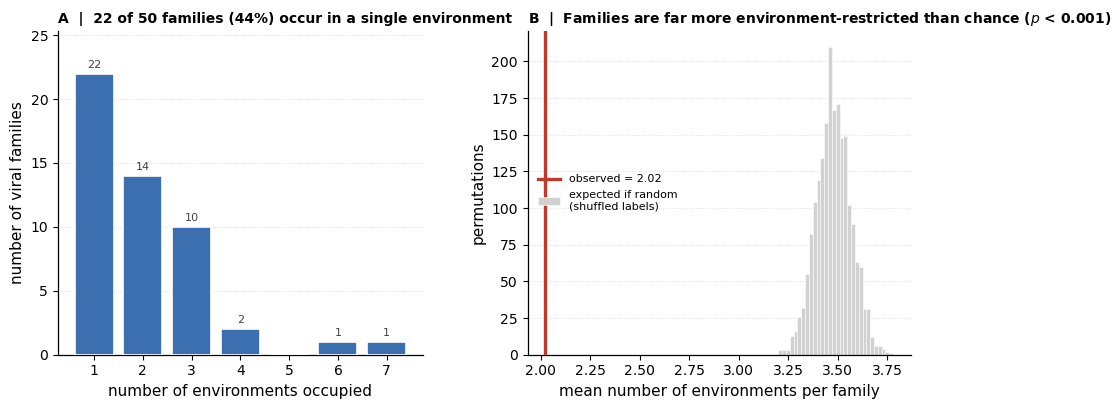

50 families | 1 env: 22 (44%) | <=2: 36 | median dominant-env fraction 0.83 | permutation p=0.0000


In [8]:
#viral spread across envs
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

_src = host_df_all if "host_df_all" in dir() else df_ALL
d = _src.copy(); d["family"] = d["family"].astype(str).str.strip()
d = d[d["Environment_Bin"].astype(str) != "Unclassified"]
idc = "contig_id" if "contig_id" in d.columns else d.columns[0]
envs = sorted(d["Environment_Bin"].astype(str).unique())

M = d.pivot_table(index="family", columns="Environment_Bin", values=idc, aggfunc="count", fill_value=0).reindex(columns=envs, fill_value=0)
n_env = (M > 0).sum(axis=1); tot = M.sum(axis=1); dom_frac = M.div(tot, axis=0).max(axis=1)

fam_labels = d["family"].values; env_labels = d["Environment_Bin"].astype(str).values
rng = np.random.default_rng(0); obs = n_env.mean(); perm = []
for _ in range(2000):
    mm = pd.crosstab(fam_labels, rng.permutation(env_labels)); perm.append((mm > 0).sum(axis=1).mean())
perm = np.array(perm); p_perm = (perm <= obs).mean()

with plt.rc_context({"font.family":"DejaVu Sans","font.size":10,"axes.titlesize":11,"axes.labelsize":11,"axes.linewidth":0.9}):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios":[1, 1.05], "wspace":0.28})
    vc = n_env.value_counts().reindex(range(1, len(envs)+1), fill_value=0)
    ax1.bar(vc.index, vc.values, color="#3B6FB0", edgecolor="white", lw=1.2, width=0.8, zorder=3)
    for x, v in zip(vc.index, vc.values):
        if v > 0: ax1.text(x, v+0.3, str(int(v)), ha="center", va="bottom", fontsize=8, color="0.25")
    ax1.set_xlabel("number of environments occupied"); ax1.set_ylabel("number of viral families")
    ax1.set_xticks(range(1, len(envs)+1)); ax1.set_ylim(0, vc.max()*1.15)
    ax1.set_axisbelow(True); ax1.grid(axis="y", ls=":", lw=0.6, color="0.85")
    ax1.set_title(f"A  |  {int((n_env==1).sum())} of {len(M)} families ({100*(n_env==1).mean():.0f}%) occur in a single environment", fontsize=10, loc="left", fontweight="bold")
    for s in ("top","right"): ax1.spines[s].set_visible(False)

    ax2.hist(perm, bins=30, color="0.82", edgecolor="white", lw=0.4, zorder=2, label="expected if random\n(shuffled labels)")
    ax2.axvline(obs, color="#C0392B", lw=2.4, zorder=4, label=f"observed = {obs:.2f}")
    ax2.set_xlabel("mean number of environments per family"); ax2.set_ylabel("permutations")
    ax2.set_axisbelow(True); ax2.grid(axis="y", ls=":", lw=0.6, color="0.85")
    ax2.set_title("B  |  Families are far more environment-restricted than chance ($p$ < 0.001)", fontsize=10, loc="left", fontweight="bold")
    ax2.legend(fontsize=8, frameon=False, loc="center left")
    for s in ("top","right"): ax2.spines[s].set_visible(False)

    OUTDIR = "/Users/skoog/Desktop/"
    fig.savefig(OUTDIR + "family_environment_specificity.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTDIR + "family_environment_specificity.svg", bbox_inches="tight")
    plt.show()

M.assign(n_envs=n_env, dom_frac=dom_frac.round(2)).to_csv(OUTDIR + "family_environment_specificity.csv")
print(f"{len(M)} families | 1 env: {int((n_env==1).sum())} ({100*(n_env==1).mean():.0f}%) | <=2: {int((n_env<=2).sum())} | "
      f"median dominant-env fraction {dom_frac.median():.2f} | permutation p={p_perm:.4f}")

In [9]:
import numpy as np, pandas as pd

def _host_group_iphop(r):
    """iPHoP host domain/phylum -> broad group. Splits archaea into Halophilic vs Other only."""
    if not r.get("has_iphop", False): return np.nan
    dom, phy = str(r.get("host_domain")), str(r.get("host_phylum"))
    if dom == "Archaea":
        return "Halophilic Archaea" if phy == "Halobacteriota" else "Other Archaea"
    if dom == "Bacteria":               return "Bacteria"
    if dom in ("Eukaryota", "Eukarya"): return "Eukarya"
    return np.nan

def _final_host_group(r):
    """Authoritative host group for a virus. iPHoP-first, else viral-family-inferred ecology."""
    if r.get("has_iphop", False):
        g = _host_group_iphop(r)
        return g if pd.notna(g) else "Unknown/Other"
    eco = r.get("Host_ecology")
    if pd.notna(eco) and str(eco) not in ("Unknown/Other", "nan", ""):
        return str(eco)
    return "Unknown/Other"

def _grp_all_hosts(r):
    """3-focal-group collapse (Bacteria / Halophilic Archaea / Other Archaea) for the by-host figures.
       iPHoP-first; inferred archaea split by ecology; everything else -> NaN (excluded)."""
    if r.get("has_iphop", False):
        g = _host_group_iphop(r)
        return {"Thermophilic Archaea": "Other Archaea"}.get(g, g)
    hg = str(r.get("Host_group")); eco = str(r.get("Host_ecology"))
    if hg == "Archaea":
        return "Halophilic Archaea" if eco == "Halophilic Archaea" else "Other Archaea"
    if hg == "Bacteria":
        return "Bacteria"
    if hg.startswith("Eukary"):
        return "Eukarya"
    return np.nan


In [10]:
# iphop host info
import re, glob, os, difflib, numpy as np, pandas as pd

HOST_DIR      = r"/Users/skoog/Desktop/"
HOST_FILENAME = "Host_prediction_to_genus_m90.csv"
HOST_RANK     = "phylum"
RANKS         = ["domain","phylum","class","order","family","genus","species"]
PICKLE        = os.path.join(HOST_DIR, "filtered_All_envs_df_with_metadata.pkl")
FILE2LAKE_OVERRIDE = {}    

def _normid(x):
    s = pd.Series(x, dtype="object").astype(str).str.strip()
    s = s.str.replace(r"\.faa$", "", regex=True)             
    s = s.str.replace("|", "_", regex=False)                
    s = s.str.replace(r"_provirus_\d+_\d+$", "", regex=True)  
    return s

_ref = pd.read_pickle(PICKLE).copy()
if "Average_pI" not in _ref.columns: _ref["Average_pI"] = _ref["Median_pI"]
_rf  = _ref["family"].astype(str).str.strip()
_ref = _ref[~(_rf.isin(DROP_FAMILIES) | _rf.str.replace(r"^Unclassified\s+","",regex=True).isin(DROP_FAMILIES))]
_ref = _ref[_ref["Environment_Bin"].notna()].copy()
_ref["_vid"]  = _normid(_ref["contig_id"])
_vid_lakes    = _ref.groupby("_vid")["name_full"].agg(lambda s: sorted(set(s)))
_env_of_lake  = _ref.drop_duplicates("name_full").set_index("name_full")["Environment_Bin"].to_dict()
_lakes_by_env = {}
for _lk, _e in _env_of_lake.items(): _lakes_by_env.setdefault(_e, []).append(_lk)
def _cleanfolder(x):
    x = re.sub(r"_split_by_contig.*$", "", str(x).lower())
    return re.sub(r"\s+", " ", re.sub(r"[_\-]", " ", x)).strip()

_hostcols = [f"host_{r}" for r in RANKS]

def _load_iphop(path):
    h = pd.read_csv(path)
    tc = "Host taxonomy" if "Host taxonomy" in h.columns else "Host genus"
    conf = "Confidence score" if "Confidence score" in h.columns else ("Confidence" if "Confidence" in h.columns else None)
    tax = h[tc].str.split(";", expand=True)
    tax = tax.iloc[:, :len(RANKS)]
    tax.columns = RANKS[:tax.shape[1]]
    for c in tax.columns:
        tax[c] = tax[c].astype(str).str.replace(r"^[a-z]__", "", regex=True).str.strip().replace({"": np.nan, "nan": np.nan})
    tax = tax.add_prefix("host_")
    for col in _hostcols:                 
        if col not in tax.columns: tax[col] = np.nan
    tax = tax[_hostcols]
    hh = pd.concat([h[["Virus"]].copy(), tax], axis=1)
    hh["Confidence score"] = h[conf] if conf else np.nan
    hh["_vid"] = _normid(hh["Virus"]); hh["_host_file"] = os.path.relpath(path, HOST_DIR)
    return hh.sort_values("Confidence score", ascending=False).drop_duplicates("_vid")

host_paths = sorted(glob.glob(os.path.join(HOST_DIR, "**", HOST_FILENAME), recursive=True))
if not host_paths:
    raise FileNotFoundError(f"No '{HOST_FILENAME}' found under {HOST_DIR} -- check HOST_DIR.")

_votu, _comp, _report = [], [], []
for p in host_paths:
    folder = os.path.relpath(p, HOST_DIR).split(os.sep)[0]
    hh = _load_iphop(p)
    matched = hh[hh["_vid"].isin(_vid_lakes.index)]
    if matched.empty:
        _report.append(dict(folder=folder[:40], kind="NO MATCH", target="-", matched=0, n_ids=len(hh))); continue
    is_votu = matched["_vid"].str.startswith("WATLvirus").mean() > 0.5
    if is_votu:
        _votu.append(matched)
        _report.append(dict(folder=folder[:40], kind="vOTU (WATL)", target="(all WATL lakes)",
                            matched=len(matched), n_ids=len(hh)))
    else:
        env_counts = {}
        for v in matched["_vid"]:
            for lk in _vid_lakes.loc[v]:
                e = _env_of_lake.get(lk); env_counts[e] = env_counts.get(e, 0) + 1
        best_env = FILE2LAKE_OVERRIDE.get(folder) or max(env_counts, key=env_counts.get)
        m2 = matched.copy(); m2["Environment_Bin"] = best_env
        _comp.append(m2)
        _report.append(dict(folder=folder[:40], kind="env-scoped", target=best_env,
                            matched=len(matched), n_ids=len(hh)))

print("iPHoP file classification:")
print(pd.DataFrame(_report).to_string(index=False))

comp_hosts = (pd.concat(_comp, ignore_index=True).sort_values("Confidence score", ascending=False)
                .drop_duplicates(["Environment_Bin","_vid"])) if _comp else \
             pd.DataFrame(columns=["Environment_Bin","_vid","Confidence score","_host_file"]+_hostcols)
votu_hosts = (pd.concat(_votu, ignore_index=True).sort_values("Confidence score", ascending=False)
                .drop_duplicates("_vid")) if _votu else \
             pd.DataFrame(columns=["_vid","Confidence score","_host_file"]+_hostcols)
hosts = pd.concat([comp_hosts, votu_hosts], ignore_index=True)

def merge_iphop(frame):
    """Namespace-aware iPHoP merge onto any frame that has (name_full, contig_id)."""
    f = frame.copy()
    f["_vid"] = _normid(f["contig_id"])
    f = f.drop(columns=[c for c in ["Virus","Confidence score","_host_file","has_iphop"]+_hostcols
                        if c in f.columns], errors="ignore")
    m = f.merge(comp_hosts[["Environment_Bin","_vid","Confidence score","_host_file"]+_hostcols],
                on=["Environment_Bin","_vid"], how="left")
    m = m.merge(votu_hosts[["_vid","Confidence score","_host_file"]+_hostcols],
                on="_vid", how="left", suffixes=("","_votu"))
    for c in _hostcols + ["Confidence score","_host_file"]:
        m[c] = m[c].fillna(m[f"{c}_votu"])
    m = m.drop(columns=[f"{c}_votu" for c in _hostcols + ["Confidence score","_host_file"]])
    m["has_iphop"] = m["host_domain"].notna()
    return m

host_df = merge_iphop(filtered_All_envs_df_with_metadata)
host_df["Host_ecology"] = host_df["family"].astype(str).str.strip().map(host_ecology)
host_df["Host_source"]  = np.where(host_df["has_iphop"], "iPHoP",
                          np.where(host_df["Host_ecology"].notna(), "Taxonomy-inferred", "Unknown"))
host_df["Host_best"]    = np.where(host_df["has_iphop"], host_df[f"host_{HOST_RANK}"], host_df["Host_ecology"])
host_df["Host_best"]    = pd.Series(host_df["Host_best"], index=host_df.index, dtype=object).fillna("Unknown/Other")

N = len(host_df); n_ip = int(host_df["has_iphop"].sum()); n_tax = int((host_df["Host_source"]=="Taxonomy-inferred").sum())
print("\nHOST-PREDICTION COVERAGE (current scope)")
print(f"  iPHoP-predicted   : {n_ip:,} / {N:,}  ({100*n_ip/N:.1f}%)")
print(f"  taxonomy-inferred : {n_tax:,} / {N:,}  ({100*n_tax/N:.1f}%)")
print(f"  combined coverage : {100*(n_ip+n_tax)/N:.1f}%   (Unknown {100*(N-n_ip-n_tax)/N:.1f}%)")
cov = host_df.groupby("Environment_Bin").agg(n=("has_iphop","size"), iPHoP=("has_iphop","sum"),
        tax=("Host_source", lambda s:(s=="Taxonomy-inferred").sum()))
cov["iPHoP_%"] = (100*cov["iPHoP"]/cov["n"]).round(1)
print("\nper environment:\n", cov.to_string())

iPHoP file classification:
                                  folder        kind                     target  matched  n_ids
Cock_soda_lake_split_by_contig_faa_updat  env-scoped           Saline soda lake      171    513
Cueva_de_la_mora_lake_11m_split_by_conti  env-scoped                Acidic lake        1      4
Cueva_de_la_mora_lake_35m_split_by_conti    NO MATCH                          -        0      2
Cueva_de_la_mora_lake_3m_split_by_contig  env-scoped                Acidic lake        1      2
Lake_Bitter_1_split_by_contig_faa_update  env-scoped      Hypersaline soda lake        1      5
Lake_Soyang_viruses_split_by_contig_faa_  env-scoped                 Freshwater       45    198
Lake_Victoria_split_by_contig_faa_update  env-scoped                 Freshwater        3     11
Lake_tanatar_TC_split_by_contig_faa_upda  env-scoped      Hypersaline soda lake        2     13
Lost_city_split_by_contig_faa_updated_re  env-scoped Alkaline hydrothermal vent       77    224
Malaren_B_spl

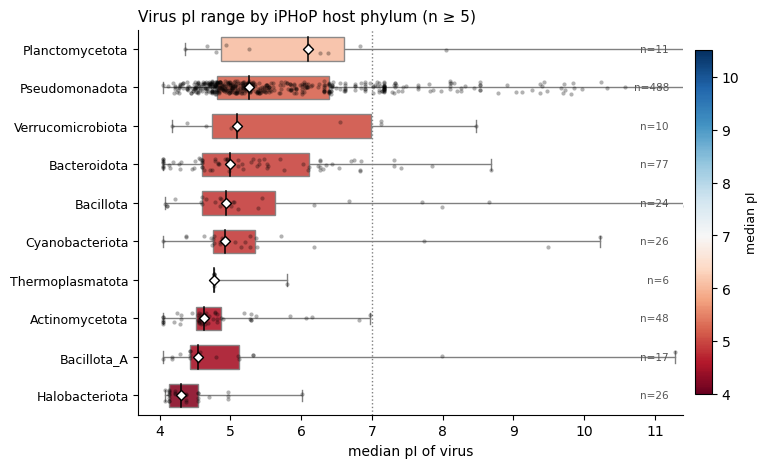

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

MIN_N, CENTER, ACIDIC_COLOR = 5, 7.0, "red"
PICOL = "Median_pI"
sub = host_df[host_df["has_iphop"]].dropna(subset=[PICOL, f"host_{HOST_RANK}"]).copy()
sub[PICOL] = pd.to_numeric(sub[PICOL], errors="coerce")

rows = []
for name, g in sub.groupby(f"host_{HOST_RANK}"):
    if len(g) < MIN_N: continue
    w = pd.to_numeric(g.get("rpkm", pd.Series(1.0, index=g.index)), errors="coerce").fillna(1.0).values
    rows.append((name, g[PICOL].values, float(np.median(g[PICOL].values)), len(g)))
rows.sort(key=lambda t: t[2])
lo = np.floor(np.nanpercentile(sub[PICOL], 1)*2)/2; hi = np.ceil(np.nanpercentile(sub[PICOL], 99)*2)/2
norm = TwoSlopeNorm(vcenter=CENTER, vmin=min(lo, CENTER-1e-6), vmax=max(hi, CENTER+1e-6))
cmap = plt.get_cmap("RdBu" if ACIDIC_COLOR == "red" else "RdBu_r")
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7.4, 0.36*len(rows) + 1.4))
bp = ax.boxplot([r[1] for r in rows], positions=np.arange(len(rows)), vert=False, widths=0.62,
                patch_artist=True, showfliers=False, whis=(0,100),
                medianprops=dict(color="black", lw=1.1), whiskerprops=dict(color="grey"),
                capprops=dict(color="grey"))
for patch, r in zip(bp["boxes"], rows): patch.set_facecolor(cmap(norm(r[2]))); patch.set_alpha(0.9); patch.set_edgecolor("grey")
for i, r in enumerate(rows):
    ax.scatter(r[1], i + rng.uniform(-0.16, 0.16, len(r[1])), s=9, color="black", alpha=0.3, zorder=3, linewidths=0)
    ax.text(hi+0.7, i, f"n={r[3]}", va="center", ha="right", fontsize=7.5, color="#555")
ax.scatter([r[2] for r in rows], np.arange(len(rows)), marker="D", s=26, color="white", edgecolor="black", zorder=4)
ax.axvline(CENTER, color="grey", ls=":", lw=1)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlim(lo-0.3, hi+0.9); ax.set_xlabel("median pI of virus")
ax.set_title(f"Virus pI range by iPHoP host {HOST_RANK} (n \u2265 {MIN_N})", fontsize=11, loc="left")
sm2 = ScalarMappable(norm=norm, cmap=cmap); sm2.set_array([])
cb = fig.colorbar(sm2, ax=ax, fraction=0.03, pad=0.02); cb.set_label("median pI", fontsize=9)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.savefig(r"/Users/skoog/Desktop/host_pI_range_iphop.png", dpi=300, bbox_inches="tight")
plt.show()

### Teasing apart host vs environment

In [14]:

import re, numpy as np, pandas as pd

HOST_BACKOFF = [
    ("Halophilic Archaea", ["Thumleimavirales","Halopanivirales","Pleolipoviridae","Sphaerolipoviridae",
        "Simuloviridae","Haloferuviridae","Graaviviridae","Vertoviridae","Hafunaviridae","Halomagnusviridae",
        "Druskaviridae","Soleiviridae","Madisaviridae","Saparoviridae","Suolaviridae","Verdandiviridae",
        "Skuldviridae","Shortaselviridae","Halspiviridae","Halobacteri"]),
    ("Thermophilic Archaea", ["Rudiviridae","Tristromaviridae","Fuselloviridae","Lipothrixviridae","Ligamenvirales",
        "Sulfolobales","Turriviridae","Portogloboviridae","Spiraviridae","Globuloviridae","Ampullaviridae",
        "Bicaudaviridae","Clavaviridae","Guttaviridae"]),
    ("Methanogen Archaea", ["Leisingerviridae","Anaerodiviridae","Methanobacteri"]),
    ("Eukarya (giant viruses)", ["Nucleocytoviricota","Megaviricetes","Imitervirales","Algavirales","Pimascovirales",
        "Mimiviridae","Phycodnaviridae","Marseilleviridae","Pandoravir","Bamfordvirae","Allomimiviridae",
        "Schizomimiviridae","Mesomimiviridae","Poxviridae","Ascoviridae","Iridoviridae"]),
    ("Virophage (GV-infected cells)", ["Lavidaviridae","Maveriviricetes","Priklausovirales","virophage"]),
    ("Eukarya (vertebrates/ invertebrates)", ["Cressdnaviricota","Circoviridae","Smacoviridae","Parvoviridae",
        "Herpesvir","Adintoviridae","Naldaviricetes","Genomoviridae","Baculoviridae","Papillomavir","Polyomavir"]),
    ("Eukarya (plants/algae)", ["Tombusviridae","Virgaviridae","Bromoviridae","Potyviridae"]),
    ("Bacteria", ["Caudoviricetes","Crassvirales","Tubulavirales","Petitvirales","Vinavirales","Peduoviridae",
        "Autographiviridae","Straboviridae","Kyanoviridae","Zobellviridae","Schitoviridae","Rountreeviridae",
        "Casjensviridae","Chaseviridae","Guelinviridae","Demerecviridae","Drexlerviridae","Herelleviridae",
        "Mesyanzhinovviridae","Ackermannviridae","Inoviridae","Microviridae","Corticoviridae","Tectiviridae","phage"]),
]
HALO_RE = re.compile(r"\bhalo", re.I)                                 # Halo* families -> haloarchaea
DEFAULT_BACTERIA_RE = re.compile(r"(viridae|virales|viricetes)\b", re.I)

def _assign(fam):
    s = str(fam)
    for cat, keys in HOST_BACKOFF:
        if any(k.lower() in s.lower() for k in keys): return cat, "keyword"
    if HALO_RE.search(s):             return "Halophilic Archaea", "halo-name heuristic"
    if DEFAULT_BACTERIA_RE.search(s): return "Bacteria", "default (Caudoviricetes)"
    return "Unknown/Other", "unassigned"

fam = host_df["family"].astype(str).str.strip()
host_df["Host_ecology"] = fam.map(host_ecology)
_res = fam.map(_assign)
host_df["_bo_cat"] = _res.map(lambda t: t[0]); host_df["_bo_via"] = _res.map(lambda t: t[1])
host_df["Host_broad"] = host_df["Host_ecology"].fillna(host_df["_bo_cat"])
host_df["Host_broad_source"] = np.where(host_df["Host_ecology"].notna(), "family map",
                                np.where(host_df["Host_broad"].eq("Unknown/Other"), "unassigned", host_df["_bo_via"]))
host_df.drop(columns=["_bo_cat","_bo_via"], inplace=True)

N = len(host_df)
print("BROAD-HOST ASSIGNMENT (viral-taxonomy based, ALL viruses):")
for lab in ["family map","keyword","halo-name","default (Caudoviricetes)","unassigned"]:
    n = int((host_df["Host_broad_source"] == lab).sum()); print(f"  {lab:<26}: {n:,} ({100*n/N:.1f}%)")
print(f"  --> total assigned: {100*(host_df['Host_broad']!='Unknown/Other').mean():.1f}%\n")

dflt = host_df.loc[host_df["Host_broad_source"]=="default (Caudoviricetes)","family"].astype(str).value_counts()
if len(dflt):
    print("families assigned Bacteria by DEFAULT rule (audit these):")
    print(dflt.to_string(), "\n")

und = host_df[host_df["Host_broad"]=="Unknown/Other"]["family"].astype(str).value_counts()
print(f">>> STILL UNCLASSIFIED: {int(und.sum())} viruses across {len(und)} family labels (full list):")
print(und.to_string() if len(und) else "   none")
und.rename_axis("family").reset_index(name="n_viruses").to_csv(r"/Users/skoog/Desktop/unclassified_families.csv", index=False)

if "host_phylum" in host_df.columns:
    _mi = int((host_df["has_iphop"] & host_df["host_phylum"].isna()).sum())
    print(f"\nsanity: iPHoP viruses missing host_phylum = {_mi} (0 => fine H1-H4 analysis loses none)")

BROAD-HOST ASSIGNMENT (viral-taxonomy based, ALL viruses):
  family map                : 8,980 (100.0%)
  keyword                   : 0 (0.0%)
  halo-name                 : 0 (0.0%)
  default (Caudoviricetes)  : 0 (0.0%)
  unassigned                : 0 (0.0%)
  --> total assigned: 100.0%

>>> STILL UNCLASSIFIED: 0 viruses across 0 family labels (full list):
   none

sanity: iPHoP viruses missing host_phylum = 0 (0 => fine H1-H4 analysis loses none)


## Environment tracking of viral pI by host group 

In [16]:
# Buildingh the ALL-ENVIRONMENTS host_df_all 
import numpy as np, pandas as pd, re
OUTDIR = "/Users/skoog/Desktop/"

_all = pd.read_pickle(PICKLE).copy()
if "Average_pI" not in _all.columns: _all["Average_pI"] = _all["Median_pI"]

_UNINF = {"Unclassified","Unknown","nan","NaN","NA",""}
_f = _all["family"].astype(str).str.strip()
_all = _all[~(_f.isin(DROP_FAMILIES) | _f.str.replace(r"^Unclassified\s+","",regex=True).isin(DROP_FAMILIES))]
_env = _all["Environment_Bin"].astype(str).str.strip()
_all = _all[_all["Environment_Bin"].notna() & ~_env.isin(_UNINF)]
_all = _all[~_all["family"].astype(str).str.strip().isin(_UNINF)].reset_index(drop=True)

host_df_all = merge_iphop(_all)

HOST_BACKOFF = [
 ("Halophilic Archaea",["Thumleimavirales","Halopanivirales","Pleolipoviridae","Sphaerolipoviridae","Simuloviridae","Haloferuviridae","Graaviviridae","Vertoviridae","Hafunaviridae","Halomagnusviridae","Druskaviridae","Soleiviridae","Madisaviridae","Saparoviridae","Suolaviridae","Verdandiviridae","Skuldviridae","Shortaselviridae","Halspiviridae","Halobacteri"]),
 ("Thermophilic Archaea",["Rudiviridae","Tristromaviridae","Fuselloviridae","Lipothrixviridae","Ligamenvirales","Sulfolobales","Turriviridae","Portogloboviridae","Spiraviridae","Globuloviridae","Ampullaviridae","Bicaudaviridae","Clavaviridae","Guttaviridae"]),
 ("Eukarya (giant viruses)",["Nucleocytoviricota","Megaviricetes","Imitervirales","Algavirales","Pimascovirales","Mimiviridae","Phycodnaviridae","Marseilleviridae","Allomimiviridae","Schizomimiviridae","Iridoviridae"]),
 ("Virophage (GV-infected cells)",["Lavidaviridae","Maveriviricetes","virophage"]),
 ("Eukarya (vertebrates/ invertebrates)",["Cressdnaviricota","Circoviridae","Smacoviridae","Parvoviridae","Herpesvir","Genomoviridae","Baculoviridae"]),
 ("Bacteria",["Caudoviricetes","Crassvirales","Tubulavirales","Petitvirales","Vinavirales","Peduoviridae","Autographiviridae","Straboviridae","Kyanoviridae","Zobellviridae","Schitoviridae","Casjensviridae","Chaseviridae","Demerecviridae","Drexlerviridae","Herelleviridae","Mesyanzhinovviridae","Ackermannviridae","Inoviridae","Microviridae","Corticoviridae","Tectiviridae","phage"]),
]
_HALO = re.compile(r"\bhalo", re.I); _DEF = re.compile(r"(viridae|virales|viricetes)\b", re.I)
def _assign(fam):
    s = str(fam)
    for cat, keys in HOST_BACKOFF:
        if any(k.lower() in s.lower() for k in keys): return cat
    if _HALO.search(s): return "Halophilic Archaea"
    if _DEF.search(s):  return "Bacteria"
    return "Unknown/Other"
_famS = host_df_all["family"].astype(str).str.strip()
host_df_all["Host_broad"] = _famS.map(host_ecology)
_m = host_df_all["Host_broad"].isna()
host_df_all.loc[_m, "Host_broad"] = host_df_all.loc[_m, "family"].map(_assign)
host_df_all["Host_broad"] = host_df_all["Host_broad"].fillna("Unknown/Other")

print(f"ALL-ENV host_df_all: {len(host_df_all):,} viruses | {host_df_all['name_full'].nunique()} lakes | "
      f"{host_df_all['Environment_Bin'].nunique()} environments | iPHoP {host_df_all['has_iphop'].mean()*100:.1f}%")


ALL-ENV host_df_all: 8,980 viruses | 53 lakes | 7 environments | iPHoP 8.6%


In [17]:
# Merged host grouping: iPHoP where available, inferred (Host_broad) otherwise
def _harmonize(hb):
    hb = str(hb)
    if hb in ("Eukarya (giant viruses)","Eukarya (vertebrates/ invertebrates)",
              "Eukarya (plants/algae)","Virophage (GV-infected cells)"): return "Eukarya"
    if hb in ("Thermophilic Archaea","Methanogen Archaea"): return "Other Archaea"
    return hb   

def _merged(r):
    if r.get("has_iphop", False):
        g = _host_group_iphop(r)
        return g if pd.notna(g) else _harmonize(r.get("Host_broad"))
    return _harmonize(r.get("Host_broad"))

host_df_all["Host_merged"] = host_df_all.apply(_merged, axis=1)
host_df_all.loc[host_df_all["Host_merged"].isna(), "Host_merged"] = "Unknown/Other"

_prov = pd.Series(np.where(host_df_all["has_iphop"], "iPHoP", "inferred")).value_counts()
print("merged-label provenance:", _prov.to_dict())
print("merged groups:", host_df_all.loc[host_df_all.Host_merged!="Unknown/Other","Host_merged"].value_counts().to_dict())

merged-label provenance: {'inferred': 8211, 'iPHoP': 769}
merged groups: {'Bacteria': 8547, 'Bacteria and Archaea': 178, 'Halophilic Archaea': 160, 'Eukarya': 82, 'Other Archaea': 13}


In [18]:
#composition of the 'Other Archaea' group 
oa = host_df_all[host_df_all.apply(_host_group_iphop, axis=1) == "Other Archaea"]
print(f"'Other Archaea' (iPHoP): {len(oa)} viruses across "
      f"{oa['name_full'].nunique()} lakes, {oa['Environment_Bin'].nunique()} environments\n")
print("host phyla:")
print(oa["host_phylum"].value_counts().to_string())
print("\nby environment:")
print(oa["Environment_Bin"].value_counts().to_string())
print("\nby lake:")
print(oa["name_full"].value_counts().to_string())

'Other Archaea' (iPHoP): 13 viruses across 8 lakes, 5 environments

host phyla:
host_phylum
Thermoplasmatota     6
Nanoarchaeota        2
Methanobacteriota    2
Thermoproteota       2
Asgardarchaeota      1

by environment:
Environment_Bin
Alkaline-brine lakes (WATL)    5
Alkaline hydrothermal vent     4
Saline soda lake               2
Hypersaline soda lake          1
Freshwater                     1

by lake:
name_full
Lost City         4
Pink Lake         2
Cock Soda Lake    2
Balicup Lake      1
Lake Clifton      1
Pink Lake         1
Lake Tanatar-5    1
Malaren B         1


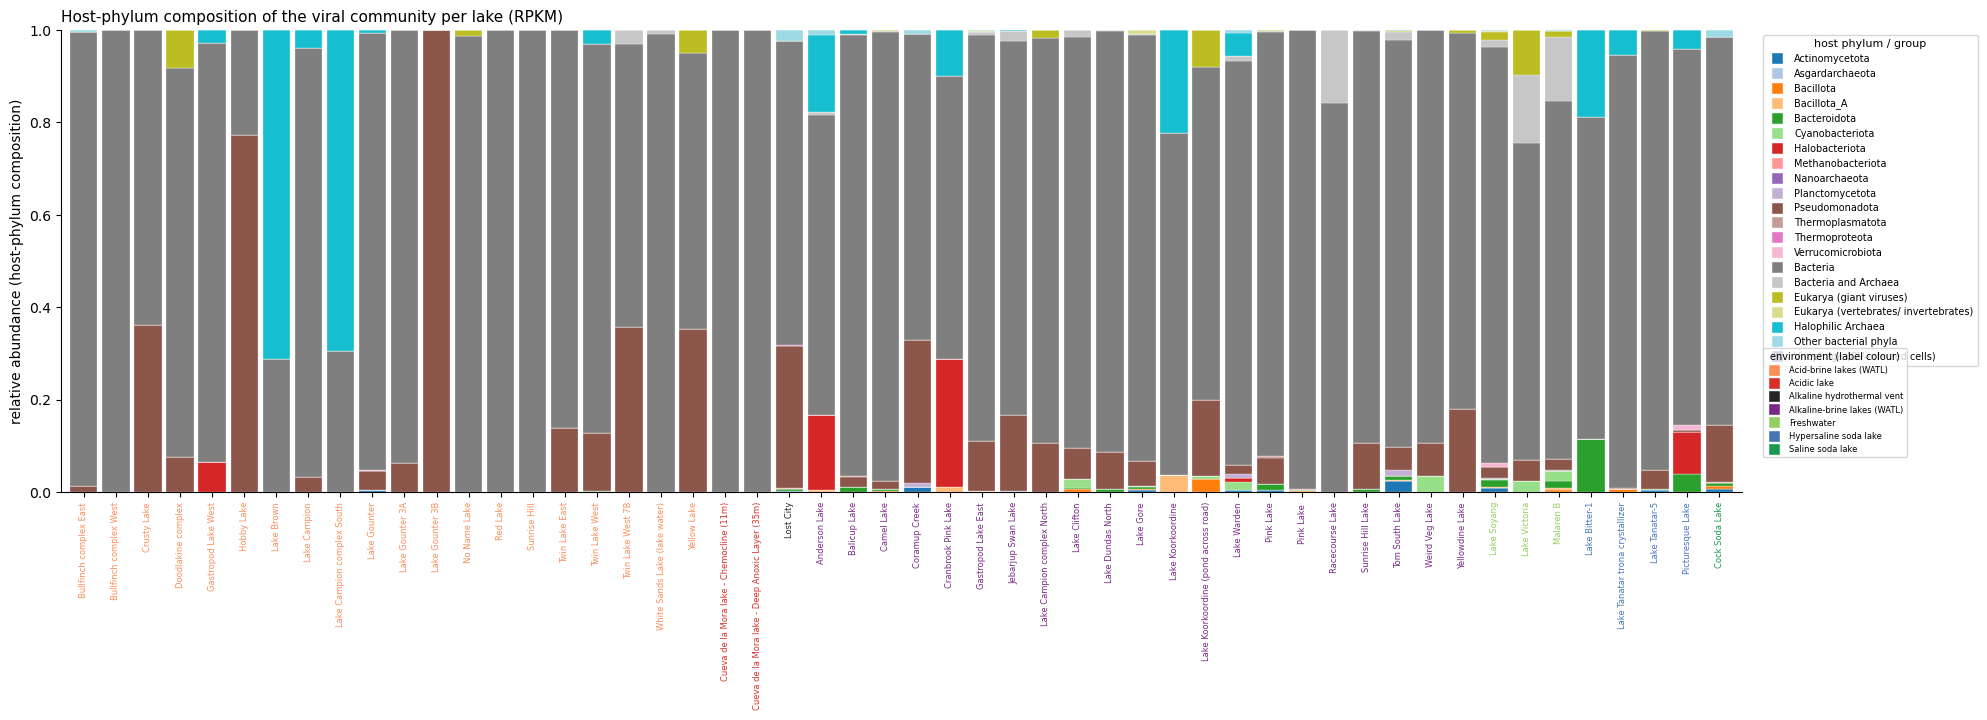

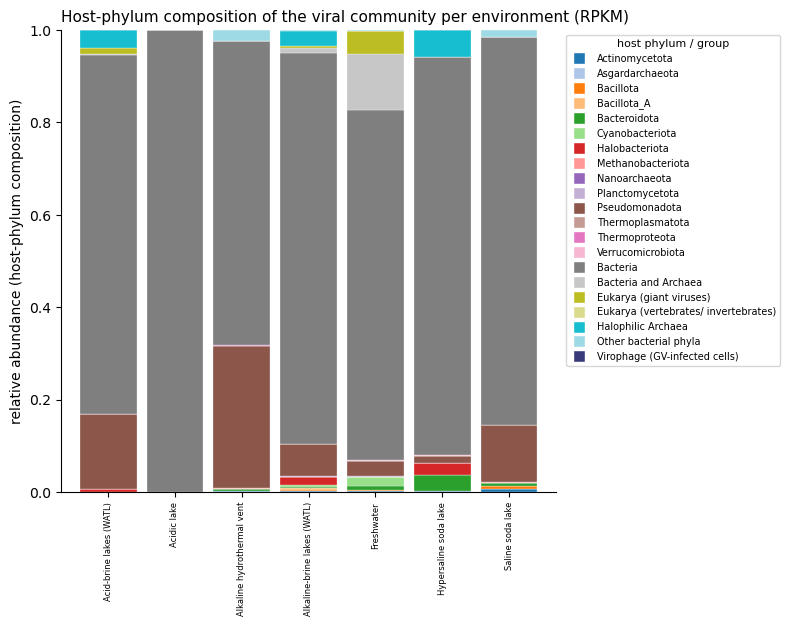

In [19]:
# Host-phylum composition of the viral community, per lake or per environment (RPKM) 
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def host_composition_bars(host_df, X_LEVEL="name_full", TOP_BACT_PHYLA=8, out_png=None, out_csv=None):
    d = host_df.copy(); d["rpkm"] = pd.to_numeric(d.get("rpkm",1.0), errors="coerce").fillna(0.0)
    d = d.dropna(subset=["name_full","Environment_Bin"])
    if "has_iphop" not in d.columns: d["has_iphop"] = d.get("host_domain", pd.Series(index=d.index)).notna()
    for c in ("host_phylum","host_domain","Host_broad"): d[c] = d.get(c, pd.Series(index=d.index, dtype=object)).astype(object)

    ip = d[d["has_iphop"] & d["host_phylum"].notna()]
    phy2dom = ip.groupby("host_phylum")["host_domain"].first(); counts = ip["host_phylum"].value_counts()
    bact = [p for p in counts.index if phy2dom.get(p) == "Bacteria"][:TOP_BACT_PHYLA]
    keep = set(phy2dom.index[phy2dom.ne("Bacteria")]) | set(bact)
    d["hostcat"] = d.apply(lambda r: (r["host_phylum"] if (r["has_iphop"] and pd.notna(r["host_phylum"]) and r["host_phylum"] in keep)
                            else ("Other bacterial phyla" if (r["has_iphop"] and pd.notna(r["host_phylum"])) else r["Host_broad"])), axis=1)

    comp = d.groupby([X_LEVEL,"hostcat"])["rpkm"].sum().reset_index()
    tot  = d.groupby(X_LEVEL)["rpkm"].sum(); comp["frac"] = comp["rpkm"]/comp[X_LEVEL].map(tot)
    piv  = comp.pivot_table(index=X_LEVEL, columns="hostcat", values="frac", fill_value=0)

    envmap = d.groupby("name_full")["Environment_Bin"].first() if X_LEVEL=="name_full" else None
    xorder = sorted(piv.index, key=lambda l: (str(envmap.get(l)), l)) if X_LEVEL=="name_full" else sorted(piv.index)
    piv = piv.loc[xorder]
    cats = sorted(piv.columns, key=lambda c: (c not in keep, str(c))); piv = piv[cats]   # archaea/euk phyla at the bottom
    pal = {c:col for c,col in zip(cats, list(plt.get_cmap("tab20").colors)+list(plt.get_cmap("tab20b").colors))}
    envcol = {e: ENV_PALETTE.get(e, "0.6") for e in sorted(d["Environment_Bin"].unique())}

    fig, ax = plt.subplots(figsize=(0.34*len(xorder)+4, 6)); bottom = np.zeros(len(xorder)); X = np.arange(len(xorder))
    for c in cats:
        ax.bar(X, piv[c].values, bottom=bottom, color=pal[c], width=0.85, edgecolor="white", lw=0.2); bottom += piv[c].values
    ax.set_xticks(X); ax.set_xticklabels(xorder, rotation=90, fontsize=6)
    if X_LEVEL=="name_full":
        for i,l in enumerate(xorder): ax.get_xticklabels()[i].set_color(envcol.get(envmap.get(l),"k"))
    ax.set_ylabel("relative abundance (host-phylum composition)"); ax.set_ylim(0,1); ax.set_xlim(-0.7,len(xorder)-0.3)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    leg = [Line2D([0],[0],marker="s",color="w",markerfacecolor=pal[c],markersize=9,label=c) for c in cats]
    l1 = ax.legend(handles=leg, title="host phylum / group", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=7, title_fontsize=8)
    if X_LEVEL=="name_full":
        ax.add_artist(l1)
        eleg = [Line2D([0],[0],marker="s",color="w",markerfacecolor=envcol[e],markersize=9,label=e) for e in sorted(envcol)]
        ax.legend(handles=eleg, title="environment (label colour)", bbox_to_anchor=(1.01,0.32), loc="upper left", fontsize=6, title_fontsize=7)
    ax.set_title(f"Host-phylum composition of the viral community per {'lake' if X_LEVEL=='name_full' else 'environment'} (RPKM)", fontsize=11, loc="left")
    if out_png: fig.savefig(out_png, dpi=300, bbox_inches="tight")
    if out_csv: piv.to_csv(out_csv)
    plt.show(); return fig

OUTDIR = "/Users/skoog/Desktop/"
src = host_df_all if "host_df_all" in dir() else host_df
_ = host_composition_bars(src, "name_full",       out_png=OUTDIR+"host_composition_per_lake.png", out_csv=OUTDIR+"host_composition_per_lake.csv")
_ = host_composition_bars(src, "Environment_Bin", out_png=OUTDIR+"host_composition_per_env.png",  out_csv=OUTDIR+"host_composition_per_env.csv")

In [20]:

import numpy as np, pandas as pd

def _collapse4(label):
    s = str(label)
    if "Virophage" in s:            return "Virophage"
    if "Eukary" in s:               return "Eukarya"
    a, b = ("Archaea" in s), ("Bacteria" in s)
    if a and b:                     return "Bacteria and Archaea"   # Straboviridae/Kyanoviridae etc.
    if a:                           return "Archaea"
    if b:                           return "Bacteria"
    return np.nan                    # mixed / unmappable -> Unknown/Other

def _iphop_domain4(r):
    if not r.get("has_iphop", False): return np.nan
    dom = str(r.get("host_domain"))
    return {"Archaea":"Archaea", "Bacteria":"Bacteria",
            "Eukaryota":"Eukarya", "Eukarya":"Eukarya"}.get(dom, np.nan)

def add_host_group(df):
    d = df.copy()
    fam   = d["family"].astype(str).str.strip()
    g_ip  = d.apply(_iphop_domain4, axis=1)          # iPHoP domain (real host call)
    g_fam = fam.map(host_ecology).map(_collapse4)    # family-dict fallback
    d["Host_group"] = g_ip
    need = d["Host_group"].isna()
    d.loc[need, "Host_group"] = g_fam[need]
    d["Host_group_source"] = np.where(g_ip.notna(), "iPHoP",
                              np.where(g_fam.notna(), "family-dict", "unassigned"))
    d["Host_group"] = d["Host_group"].fillna("Unknown/Other")
    return d

host_df_all = add_host_group(host_df_all)
watl_df     = host_df_all[host_df_all["Environment_Bin"].astype(str)
                          .str.contains("WATL")].copy()

def _cov(d, name):
    N = len(d); src = d["Host_group_source"].value_counts()
    print(f"\n{name}: {N:,} viruses")
    for k in ["iPHoP", "family-dict", "unassigned"]:
        n = int(src.get(k, 0)); print(f"   {k:<12}: {n:,} ({100*n/max(N,1):.1f}%)")
    print("   groups:", d.loc[d.Host_group != 'Unknown/Other', 'Host_group']
                          .value_counts().to_dict())

_cov(host_df_all, "ALL environments")
_cov(watl_df,     "WATL only")



ALL environments: 8,980 viruses
   iPHoP       : 769 (8.6%)
   family-dict : 8,211 (91.4%)
   unassigned  : 0 (0.0%)
   groups: {'Bacteria': 8547, 'Bacteria and Archaea': 178, 'Archaea': 173, 'Eukarya': 81, 'Virophage': 1}

WATL only: 5,021 viruses
   iPHoP       : 410 (8.2%)
   family-dict : 4,611 (91.8%)
   unassigned  : 0 (0.0%)
   groups: {'Bacteria': 4770, 'Archaea': 148, 'Bacteria and Archaea': 72, 'Eukarya': 30, 'Virophage': 1}


## pI vs pH / salinity... WATL & all-env fits overlaid, by host group

In [21]:
lake_env = host_df_all.drop_duplicates("name_full")[["name_full","pH","Salinity"]].dropna()
from scipy.stats import spearmanr
rho, p = spearmanr(lake_env["pH"], lake_env["Salinity"])
print(f"pH vs Salinity across lakes: ρ = {rho:.3f}, p = {p:.4f}, n = {len(lake_env)} lakes")

pH vs Salinity across lakes: ρ = -0.293, p = 0.0332, n = 53 lakes


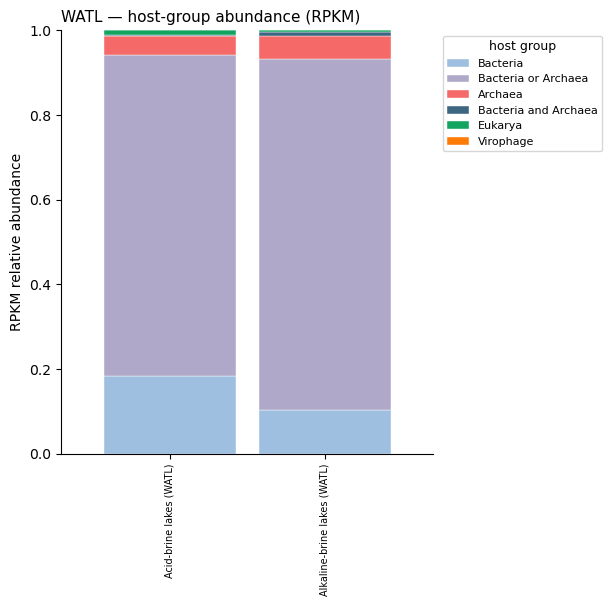

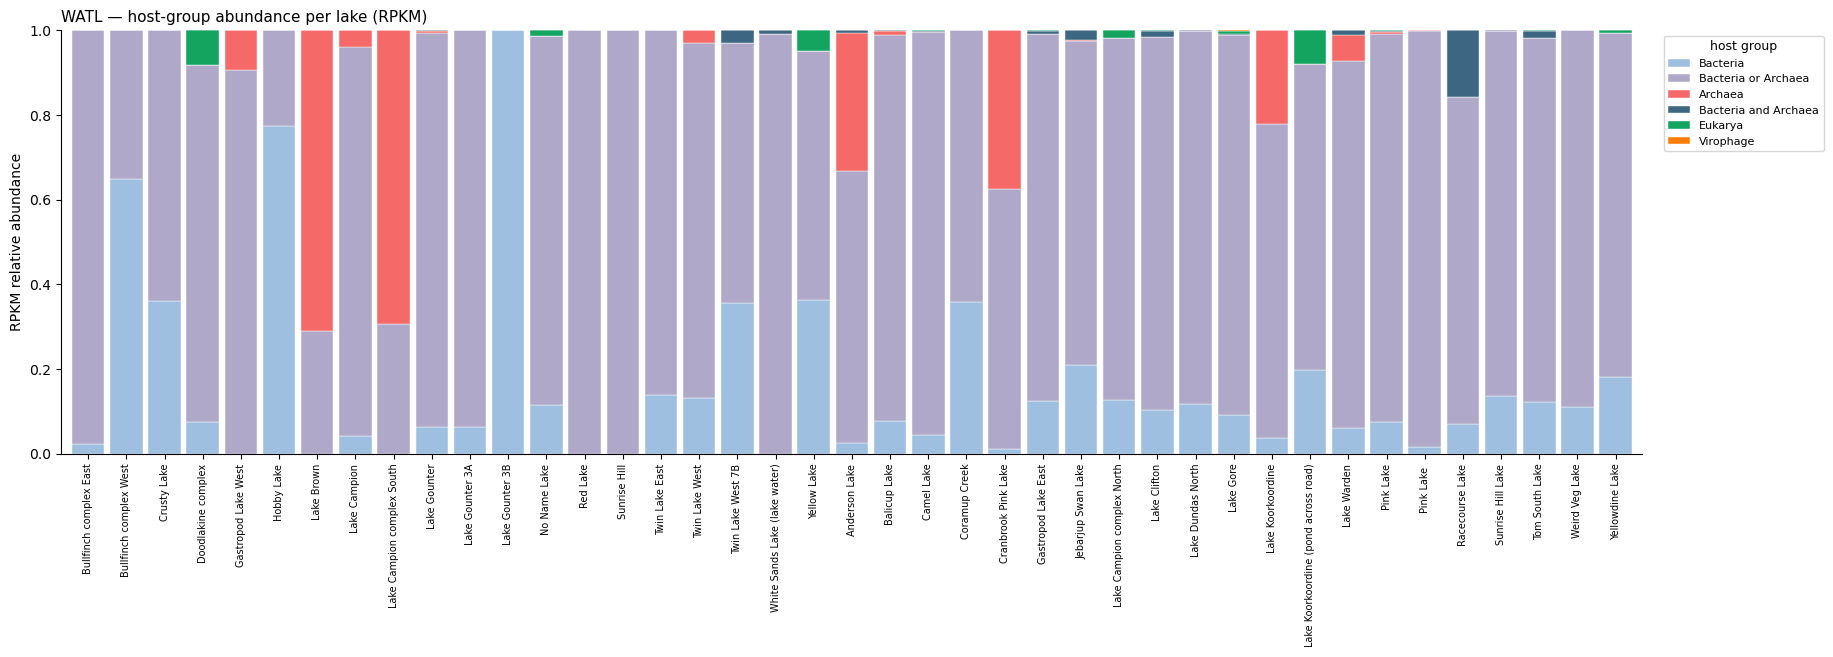

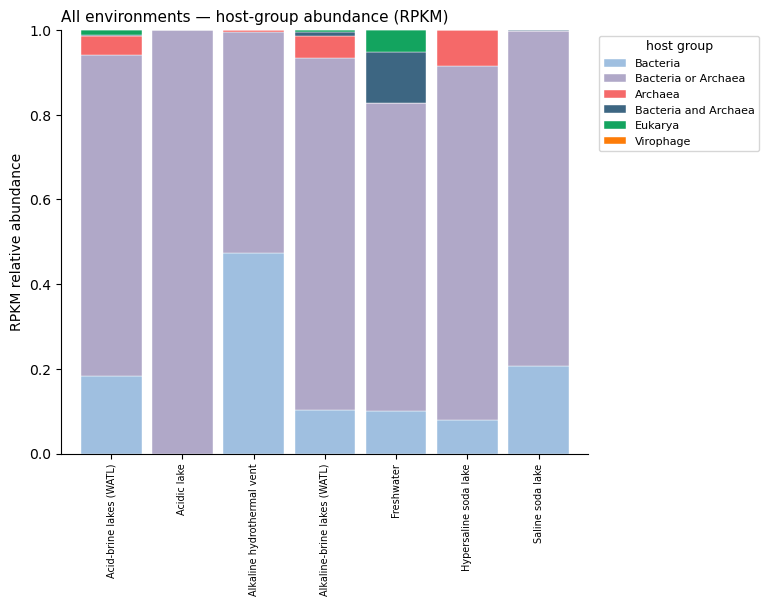

In [22]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
GROUP_PAL   = {"Bacteria":"#9FBFE0", "Archaea":"#F56969", "Eukarya":"#13A45F",
               "Virophage":"#FD7C08", "Bacteria and Archaea":"#3D6682",
               "Bacteria or Archaea":"#B0A8C8", "Unknown/Other":"#B9B9B9"}
GROUP_ORDER = ["Bacteria", "Bacteria or Archaea", "Archaea", "Bacteria and Archaea",
               "Eukarya", "Virophage", "Unknown/Other"]

# broad host group, but family-default Unclassified Caudoviricetes -> "Bacteria or Archaea"
def _boa_group(r):
    fam = str(r.get("family")).strip().lower()
    hg  = str(r.get("Host_group"))
    if (not r.get("has_iphop", False)) and fam == "unclassified caudoviricetes" and hg == "Bacteria":
        return "Bacteria or Archaea"
    return hg

def host_group_stack(df, x_level="Environment_Bin", title="", out_png=None, out_csv=None):
    d = df.copy(); d["rpkm"] = pd.to_numeric(d.get("rpkm", 1.0), errors="coerce").fillna(0.0)
    d = d.dropna(subset=[x_level])
    d["_hg"] = d.apply(_boa_group, axis=1)                      # <-- split-aware grouping
    comp = d.groupby([x_level, "_hg"])["rpkm"].sum().reset_index()
    tot  = d.groupby(x_level)["rpkm"].sum()
    comp["frac"] = comp["rpkm"] / comp[x_level].map(tot)
    piv  = comp.pivot_table(index=x_level, columns="_hg", values="frac", fill_value=0)
    cats = [c for c in GROUP_ORDER if c in piv.columns]
    if x_level == "name_full":
        envmap = d.groupby("name_full")["Environment_Bin"].first()
        xorder = sorted(piv.index, key=lambda l: (str(envmap.get(l)), l))
    else:
        xorder = sorted(piv.index)
    piv = piv.loc[xorder, cats]
    fig, ax = plt.subplots(figsize=(0.4*len(xorder) + 4, 5.5))
    bottom = np.zeros(len(xorder)); X = np.arange(len(xorder))
    for c in cats:
        ax.bar(X, piv[c].values, bottom=bottom, color=GROUP_PAL[c], width=0.85,
               edgecolor="white", lw=0.3, label=c); bottom += piv[c].values
    ax.set_xticks(X); ax.set_xticklabels(xorder, rotation=90, fontsize=7)
    ax.set_ylim(0, 1); ax.set_xlim(-0.7, len(xorder) - 0.3)
    ax.set_ylabel("RPKM relative abundance")
    ax.set_title(title or f"Host-group abundance per "
                 f"{'lake' if x_level=='name_full' else 'environment'} (RPKM)",
                 fontsize=11, loc="left")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.legend(title="host group", bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=8, title_fontsize=9)
    if out_png: fig.savefig(out_png, dpi=300, bbox_inches="tight")
    if out_csv: piv.to_csv(out_csv)
    plt.show(); return piv

_ = host_group_stack(watl_df, "Environment_Bin",
                     "WATL \u2014 host-group abundance (RPKM)",
                     OUTDIR + "hostgroup_abund_WATL_env.png",  OUTDIR + "hostgroup_abund_WATL_env.csv")
_ = host_group_stack(watl_df, "name_full",
                     "WATL \u2014 host-group abundance per lake (RPKM)",
                     OUTDIR + "hostgroup_abund_WATL_lake.png", OUTDIR + "hostgroup_abund_WATL_lake.csv")
_ = host_group_stack(host_df_all, "Environment_Bin",
                     "All environments \u2014 host-group abundance (RPKM)",
                     OUTDIR + "hostgroup_abund_ALLENV_env.png", OUTDIR + "hostgroup_abund_ALLENV_env.csv")

overall: 8,980 viruses
  iPHoP-predicted     : 769 (8.6%)
  + family-inferred   : 8,211 (91.4%)   <- added by host assumptions
  = combined coverage : 8,980 (100.0%)
  still unknown       : 0 (0.0%)

by environment:
 _src                         iPHoP  family-inferred  unknown     n  pct_iphop  pct_combined
Environment_Bin                                                                            
Acid-brine lakes (WATL)         86              994        0  1080        8.0         100.0
Acidic lake                      2               14        0    16       12.5         100.0
Alkaline hydrothermal vent      76              423        0   499       15.2         100.0
Alkaline-brine lakes (WATL)    324             3617        0  3941        8.2         100.0
Freshwater                      86             1117        0  1203        7.1         100.0
Hypersaline soda lake           24              240        0   264        9.1         100.0
Saline soda lake               171             

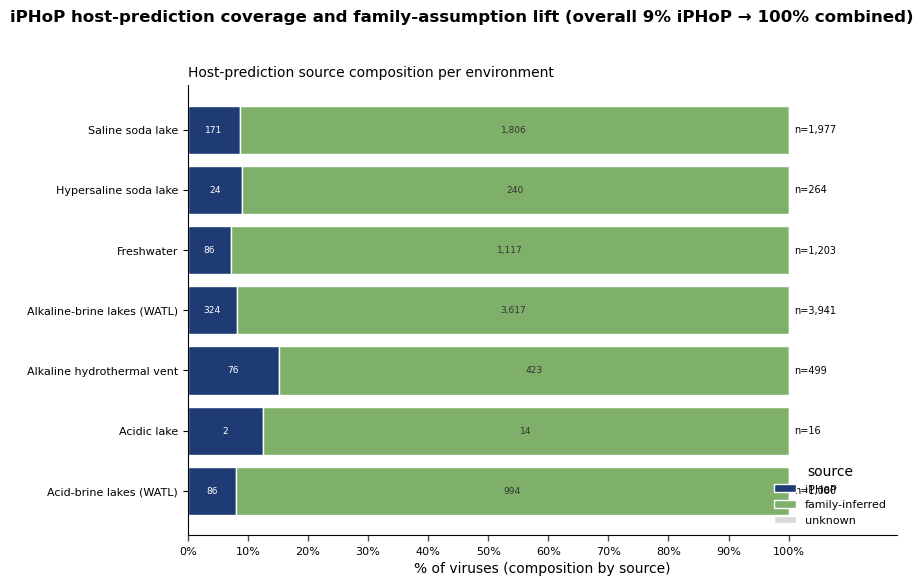

Saved: /Users/skoog/Desktop/iPHoP_host_prediction_coverage.svg


In [23]:
# iPHoP coverage and how much the family-based host assumptions ADD 
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"  
plt.rcParams["font.family"] = "DejaVu Sans"

OUTDIR = "/Users/skoog/Desktop/"
os.makedirs(OUTDIR, exist_ok=True)

INFER_COL = "Host_group"  

d = host_df_all.copy()
d["_src"] = np.where(
    d["has_iphop"],
    "iPHoP",
    np.where(d[INFER_COL].astype(str).ne("Unknown/Other"), "family-inferred", "unknown")
)

N = len(d)
n_ip = int((d["_src"] == "iPHoP").sum())
n_inf = int((d["_src"] == "family-inferred").sum())
n_unk = int((d["_src"] == "unknown").sum())

print(f"overall: {N:,} viruses")
print(f"  iPHoP-predicted     : {n_ip:,} ({100*n_ip/N:.1f}%)")
print(f"  + family-inferred   : {n_inf:,} ({100*n_inf/N:.1f}%)   <- added by host assumptions")
print(f"  = combined coverage : {n_ip+n_inf:,} ({100*(n_ip+n_inf)/N:.1f}%)")
print(f"  still unknown       : {n_unk:,} ({100*n_unk/N:.1f}%)")

tab = (
    d.groupby(["Environment_Bin", "_src"]).size().unstack(fill_value=0)
    .reindex(columns=["iPHoP", "family-inferred", "unknown"], fill_value=0)
)
tab["n"] = tab.sum(axis=1)
tab["pct_iphop"] = (100 * tab["iPHoP"] / tab["n"]).round(1)
tab["pct_combined"] = (100 * (tab["iPHoP"] + tab["family-inferred"]) / tab["n"]).round(1)

print("\nby environment:\n", tab.sort_values("pct_combined").to_string())

order = tab.sort_values("pct_combined").index
y = np.arange(len(order))
COL = {"iPHoP": "#1f3b73", "family-inferred": "#7FB069", "unknown": "#d9d9d9"}

fig, ax2 = plt.subplots(figsize=(9, 0.5 * len(order) + 2.2))

props = tab[["iPHoP", "family-inferred", "unknown"]].div(tab["n"], axis=0)
left = np.zeros(len(order))

for seg in ["iPHoP", "family-inferred", "unknown"]:
    vals = props.loc[order, seg].to_numpy(dtype=float) * 100
    raw_counts = tab.loc[order, seg].to_numpy(dtype=int)

    ax2.barh(y, vals, left=left, color=COL[seg], edgecolor="white", label=seg)

    for yi, (v, l, raw) in enumerate(zip(vals, left, raw_counts)):
        if v > 4:
            ax2.text(
                l + v / 2, yi, f"{raw:,}",
                ha="center", va="center", fontsize=6.5,
                color="white" if seg == "iPHoP" else "0.2"
            )

    left += vals

for yi, env in enumerate(order):
    ax2.text(101, yi, f"n={int(tab.loc[env, 'n']):,}", va="center", fontsize=7)

ax2.set_yticks(y)
ax2.set_yticklabels(order, fontsize=8)
ax2.set_xlim(0, 118)
ax2.set_xticks(np.arange(0, 101, 10))
ax2.set_xticklabels([f"{t}%" for t in np.arange(0, 101, 10)], fontsize=8)
ax2.tick_params(axis="x", which="major", length=4.5, width=1.0, direction="out", bottom=True, color="0.3")
ax2.set_xlabel("% of viruses (composition by source)")
ax2.set_title("Host-prediction source composition per environment", fontsize=10, loc="left")
ax2.legend(title="source", fontsize=8, loc="lower right", frameon=False)

for s in ("top", "right"):
    ax2.spines[s].set_visible(False)

fig.suptitle(
    f"iPHoP host-prediction coverage and family-assumption lift "
    f"(overall {100*n_ip/N:.0f}% iPHoP → {100*(n_ip+n_inf)/N:.0f}% combined)",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()

svg_path = os.path.join(OUTDIR, "iPHoP_host_prediction_coverage.svg")
fig.savefig(svg_path, format="svg", bbox_inches="tight")

plt.show()
print("Saved:", svg_path)

In [24]:

import pandas as pd, numpy as np

d = host_df_all.copy()
if "Host_ecology" not in d.columns:
    d["Host_ecology"] = d["family"].astype(str).str.strip().map(host_ecology)
for col in ["host_domain","host_phylum","host_class","host_order","host_family","host_genus"]:
    if col not in d.columns: d[col] = np.nan

d["_has_iphop"]    = d["has_iphop"].fillna(False)
d["_has_inferred"] = d["Host_ecology"].notna() & (~d["Host_ecology"].astype(str).isin(["Unknown/Other","nan",""]))

d["host_assignment_source"] = np.where(d["_has_iphop"], "iPHoP",
                              np.where(d["_has_inferred"], "family-inferred", "unassigned"))

d["final_host_group"] = d.apply(_final_host_group, axis=1)

def _final_domain(r):
    if r["_has_iphop"]: return str(r.get("host_domain"))
    if r["_has_inferred"]:
        eco = str(r["Host_ecology"])
        if eco == "Bacteria":                         return "Bacteria"
        if eco in ("Halophilic Archaea","Thermophilic Archaea","Other Archaea"): return "Archaea"
        if eco == "Bacteria and Archaea":             return "Bacteria and Archaea"
        if eco == "Eukaryota, Archaea, and Bacteria": return "Eukaryota, Archaea, and Bacteria"
        if eco.startswith("Eukary"):                  return "Eukaryota"
        if "Virophage" in eco:                        return "Eukaryota (virophage)"
        return eco
    return "Unassigned"
d["assigned_host_domain"] = d.apply(_final_domain, axis=1)

def _host_name(r):
    if r["_has_iphop"]:
        for rank in ["host_genus","host_family","host_order","host_class","host_phylum","host_domain"]:
            v = r.get(rank)
            if pd.notna(v) and str(v).strip() not in ("","nan"): return str(v)
        return "(iPHoP, rank unresolved)"
    if r["_has_inferred"]: return str(r["Host_ecology"])
    return "Unassigned"
d["assigned_host"] = d.apply(_host_name, axis=1)

for rank in ["host_phylum","host_class","host_order","host_family","host_genus"]:
    d[rank] = np.where(d["_has_iphop"], d[rank].astype(str).replace("nan",""), "")
d["family_inferred_ecology"] = np.where(d["_has_iphop"], "", d["Host_ecology"].astype(str).replace("nan",""))

export = d.drop_duplicates(subset=["contig_id"]).copy()
cols = ["contig_id","family","host_assignment_source","final_host_group","assigned_host_domain",
        "assigned_host","host_phylum","host_class","host_order","host_family","host_genus",
        "family_inferred_ecology","name_full","Environment_Bin","Median_pI"]
cols = [c for c in cols if c in export.columns]
out = export[cols].sort_values(["host_assignment_source","final_host_group","assigned_host","family"])

OUTDIR = "/Users/skoog/Desktop/"
out.to_csv(OUTDIR + "virus_host_assignments.csv", index=False)
print(f"Exported {len(out)} distinct viruses -> virus_host_assignments.csv\n")
print("final_host_group breakdown:"); print(out["final_host_group"].value_counts(dropna=False).to_string())
print("\nby source:"); print(out["host_assignment_source"].value_counts().to_string())
print("\nconsistency (final_host_group vs assigned_host_domain):")
print(out.groupby(["final_host_group","assigned_host_domain"]).size().reset_index(name="n").to_string(index=False))


Exported 6953 distinct viruses -> virus_host_assignments.csv

final_host_group breakdown:
final_host_group
Bacteria                                6633
Bacteria and Archaea                     160
Halophilic Archaea                        81
Eukarya (giant viruses)                   65
Other Archaea                              9
Eukarya (vertebrates/ invertebrates)       4
Virophage (GV-infected cells)              1

by source:
host_assignment_source
family-inferred    6386
iPHoP               567

consistency (final_host_group vs assigned_host_domain):
                    final_host_group  assigned_host_domain    n
                            Bacteria              Bacteria 6633
                Bacteria and Archaea  Bacteria and Archaea  160
             Eukarya (giant viruses)             Eukaryota   65
Eukarya (vertebrates/ invertebrates)             Eukaryota    4
                  Halophilic Archaea               Archaea   81
                       Other Archaea               Arc



######## Unclassified Caudoviricetes mode: exclude ########

=== Bubble correlations: permutation p, BH-FDR q, lake-bootstrap 95% CI ===
           scope                   group predictor  n_lakes     rho  p_perm  rho_lo  rho_hi  q_fdr
all environments      Halophilic Archaea        pH       17  0.0919  0.7245 -0.4079  0.5852 0.7717
all environments      Halophilic Archaea  Salinity       17 -0.4555  0.0683 -0.8544  0.0739 0.2732
all environments                Bacteria        pH       46 -0.6224  0.0001 -0.8096 -0.3686 0.0008
all environments                Bacteria  Salinity       46  0.1106  0.4597 -0.2727  0.4452 0.6839
all environments           Other Archaea        pH        8  0.2680  0.5129 -0.6193  0.8885 0.6839
all environments           Other Archaea  Salinity        8 -0.6215  0.1065 -0.9622  0.2528 0.2840
all environments Eukarya (giant viruses)        pH       17 -0.3098  0.2226 -0.7420  0.2118 0.4452
all environments Eukarya (giant viruses)  Salinity       17 -0.0762  

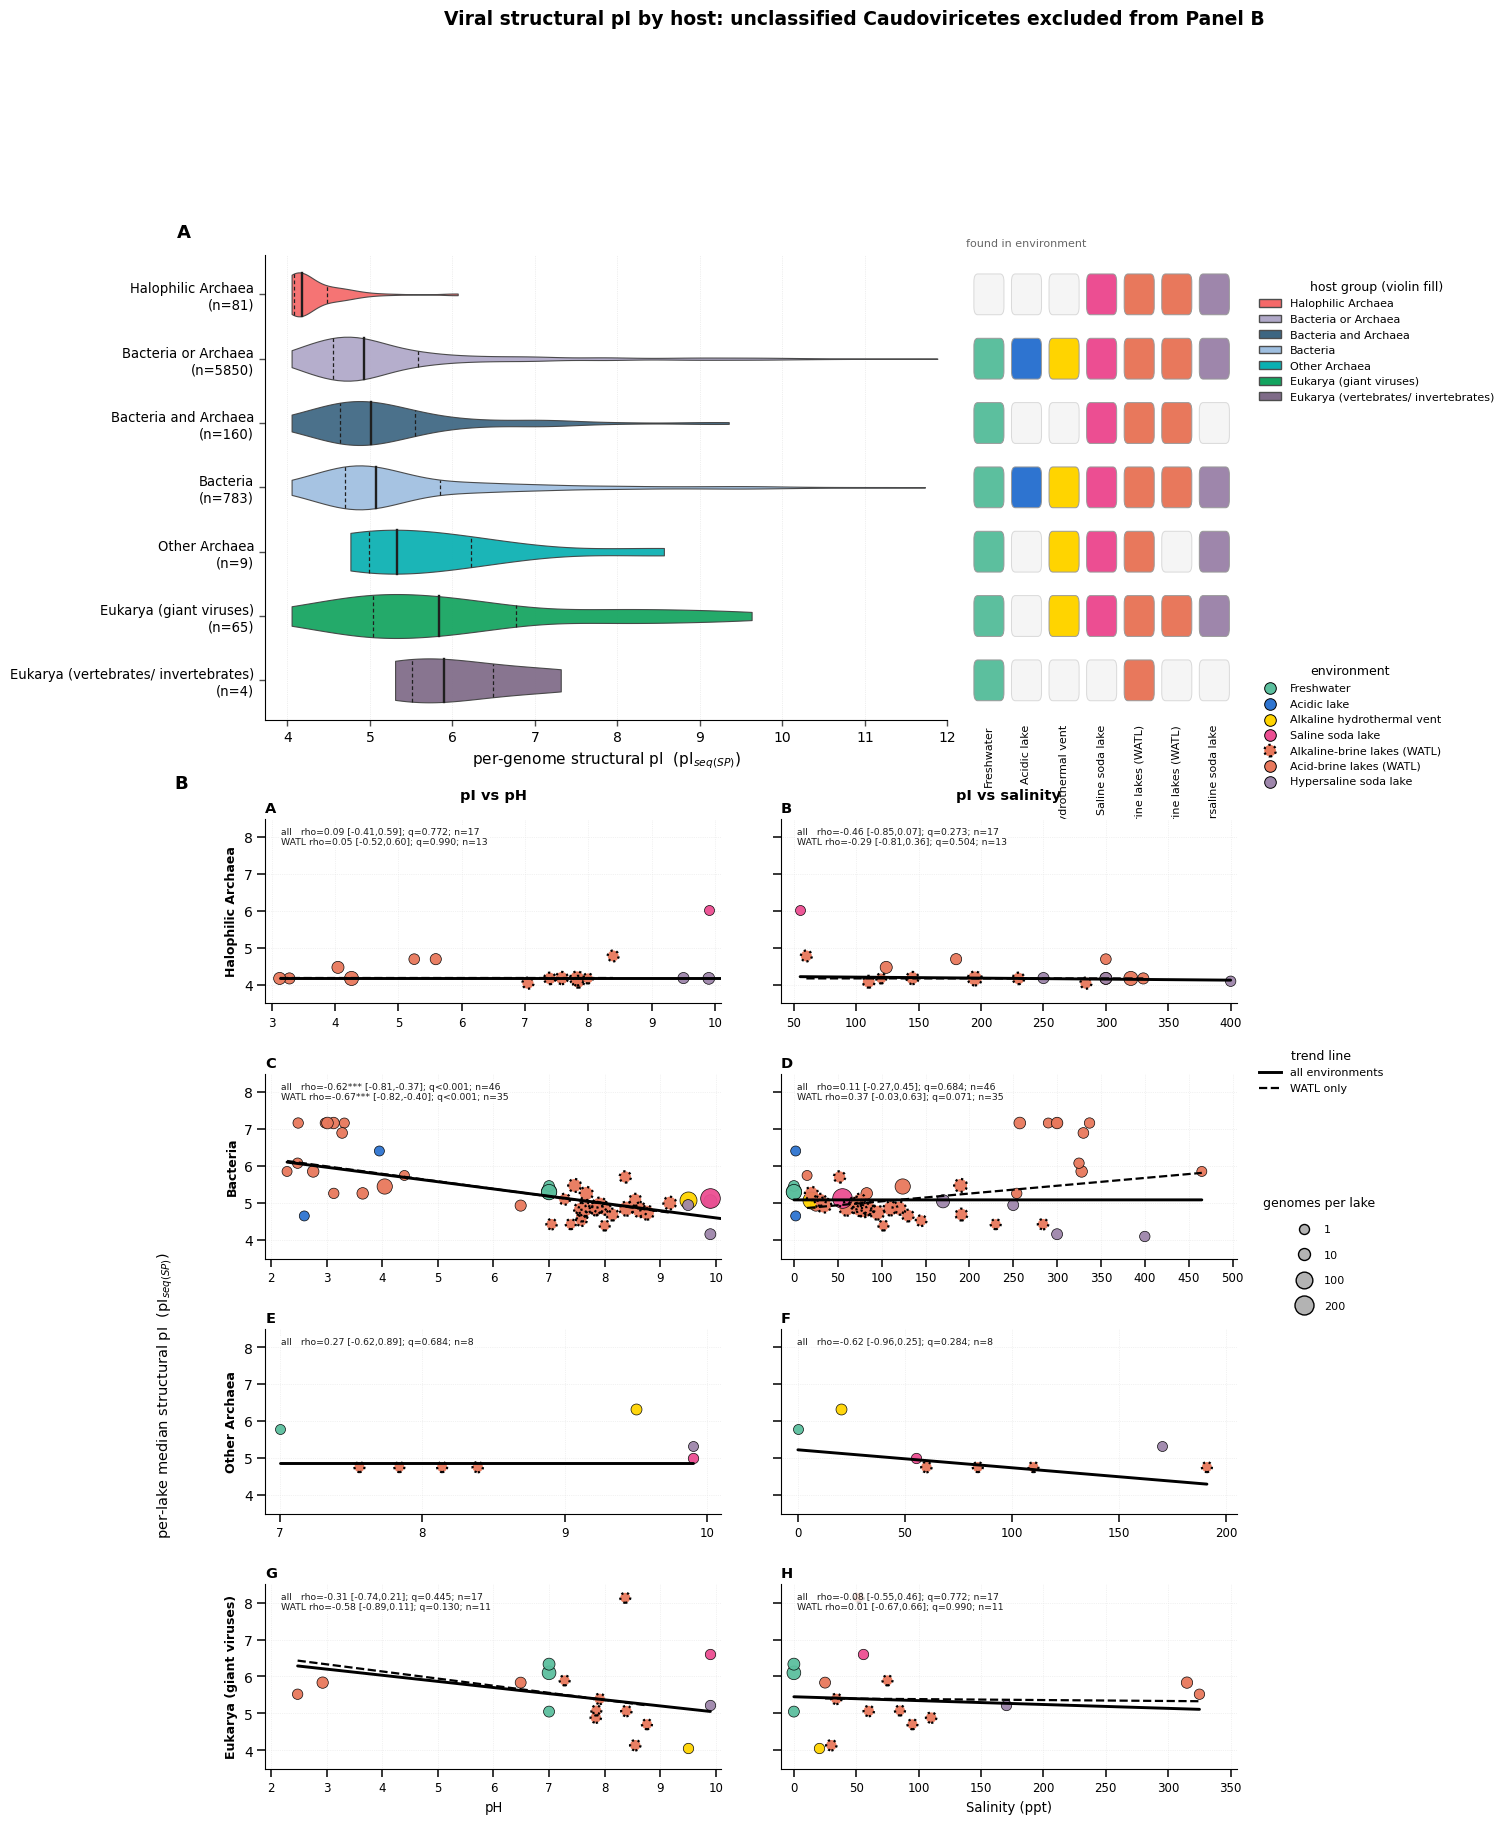

In [21]:

import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, gaussian_kde, spearmanr, rankdata, theilslopes
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings; warnings.filterwarnings("ignore")


BASE_SCATTER_ORDER = ["Halophilic Archaea", "Bacteria", "Other Archaea", "Eukarya (giant viruses)"]
UNCLASSIFIED_CAUDO_LABEL = "Unclassified Caudoviricetes"
VALID_UNCLASSIFIED_MODES = {"exclude", "bacteria", "separate"}

_ENVCOLOR = {"freshwater":"#5CBF9E","freshwater lake":"#5CBF9E","acidic lake":"#2E74D0",
    "alkaline hydrothermal vent":"#FFD400","saline soda lake":"#EC4E92",
    "alkaline-brine lake (watl)":"#E8785C","acid-brine lake (watl)":"#E8785C","hypersaline soda lake":"#9E86AB"}
_ENV_ORDER = ["Freshwater","Acidic lake","Alkaline hydrothermal vent","Saline soda lake",
              "Alkaline-brine lakes (WATL)","Acid-brine lakes (WATL)","Hypersaline soda lake"]
def _norm_env(e):
    s=str(e).lower().replace("wahl","watl"); s=re.sub(r"\blakes\b","lake",s); return re.sub(r"\s+"," ",s).strip()
def env_color(e): return _ENVCOLOR.get(_norm_env(e), "0.6")

def is_alkaline_brine(e):
    """Return True for alkaline-brine WATL/WAHL environments."""
    return _norm_env(e) == "alkaline-brine lake (watl)"

def _permutation_spearman(x, y, n_perm=9999, seed=0):
    """Two-sided permutation p-value for Spearman rho."""
    x=np.asarray(x,float); y=np.asarray(y,float)
    ok=np.isfinite(x)&np.isfinite(y); x=x[ok]; y=y[ok]
    if len(x)<4 or np.unique(x).size<2 or np.unique(y).size<2:
        return np.nan, np.nan
    rho=float(spearmanr(x,y).statistic)
    rx=rankdata(x).astype(float); ry=rankdata(y).astype(float)
    rx-=rx.mean(); ry-=ry.mean()
    den=np.sqrt(np.dot(rx,rx)*np.dot(ry,ry))
    if den==0: return np.nan, np.nan
    rng=np.random.default_rng(seed); extreme=0
    for _ in range(n_perm):
        rp=float(np.dot(rx,ry[rng.permutation(len(ry))])/den)
        if abs(rp) >= abs(rho)-1e-15: extreme += 1
    p=(extreme+1)/(n_perm+1)
    return rho,p

def _bootstrap_spearman_ci(x, y, n_boot=2000, seed=0):
    """Percentile 95% CI for rho by resampling whole lake-level rows."""
    x=np.asarray(x,float); y=np.asarray(y,float)
    ok=np.isfinite(x)&np.isfinite(y); x=x[ok]; y=y[ok]
    if len(x)<4 or np.unique(x).size<2 or np.unique(y).size<2:
        return np.nan, np.nan
    rng=np.random.default_rng(seed); vals=[]; n=len(x)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n); xb=x[idx]; yb=y[idx]
        if np.unique(xb).size<2 or np.unique(yb).size<2: continue
        r=spearmanr(xb,yb).statistic
        if np.isfinite(r): vals.append(float(r))
    if len(vals)<max(200,int(0.5*n_boot)):
        return np.nan, np.nan
    return tuple(np.percentile(vals,[2.5,97.5]))

def _bubble_stats(gl, groups, min_lakes=5, n_perm=9999, n_boot=2000, seed=7):
    """
    Primary tests: all environments (4 host groups x 2 predictors).
    Sensitivity tests: WATL only (separate family of tests).
    BH-FDR is applied separately within each scope.
    """
    rows=[]
    scopes=[("all environments",gl),("WATL only",gl[gl["_watl"]])]
    for si,(scope,base) in enumerate(scopes):
        for gi,grp in enumerate(groups):
            for pi,pred in enumerate(["pH","Salinity"]):
                sub=base.loc[base["_grp"].eq(grp),[pred,"pI","name_full"]].dropna()
                n_lakes=int(sub["name_full"].nunique())
                rho=p=lo=hi=np.nan
                if n_lakes>=min_lakes:
                    s=seed+10000*si+1000*gi+100*pi
                    rho,p=_permutation_spearman(sub[pred],sub["pI"],n_perm=n_perm,seed=s)
                    lo,hi=_bootstrap_spearman_ci(sub[pred],sub["pI"],n_boot=n_boot,seed=s+1)
                rows.append(dict(scope=scope,group=grp,predictor=pred,n_lakes=n_lakes,
                                 rho=rho,p_perm=p,rho_lo=lo,rho_hi=hi))
    S=pd.DataFrame(rows); S["q_fdr"]=np.nan
    for scope in S["scope"].unique():
        m=S["scope"].eq(scope)&S["p_perm"].notna()
        if m.any(): S.loc[m,"q_fdr"]=multipletests(S.loc[m,"p_perm"],method="fdr_bh")[1]
    return S

def _clustered_host_model(gl, groups=None):
    """
    Confirmatory host-by-environment model using one host-group median per lake
    and cluster-robust standard errors clustered by lake. pH and salinity occur
    in the same model, so each interaction is adjusted for the other variable.

    When Unclassified Caudoviricetes are shown separately, they are included as
    an additional host category, with Bacteria retained as the reference group.
    """
    d=gl.dropna(subset=["pI","pH","Salinity","_grp","name_full"]).copy()
    preferred=["Bacteria","Halophilic Archaea",UNCLASSIFIED_CAUDO_LABEL,
               "Other Archaea","Eukarya (giant viruses)"]
    requested=groups if groups is not None else preferred
    cats=[g for g in requested if g in set(d["_grp"])]
    if len(cats)<2:
        print("Clustered host interaction model skipped: fewer than two host groups.")
        return None,pd.DataFrame(),pd.DataFrame()

    reference="Bacteria" if "Bacteria" in cats else cats[0]
    d=d[d["_grp"].isin(cats)].copy()
    d["_grp"]=pd.Categorical(d["_grp"],categories=cats)
    formula=f'pI ~ C(_grp, Treatment(reference="{reference}")) * (pH + Salinity)'
    try:
        fit=smf.ols(formula,d).fit(cov_type="cluster",
            cov_kwds={"groups":d["name_full"],"use_correction":True})
    except Exception as exc:
        print("Clustered host interaction model failed:",exc)
        return None,pd.DataFrame(),pd.DataFrame()
    names=list(fit.params.index)
    tests=[]
    for pred in ["pH","Salinity"]:
        terms=[i for i,nm in enumerate(names) if ":" in nm and nm.endswith(":"+pred)]
        if terms:
            R=np.zeros((len(terms),len(names)))
            for r,i in enumerate(terms): R[r,i]=1
            wt=fit.wald_test(R,scalar=True)
            tests.append(dict(test=f"host x {pred}",Wald=float(np.asarray(wt.statistic).squeeze()),p=float(wt.pvalue)))
    T=pd.DataFrame(tests)
    if len(T): T["q_fdr"]=multipletests(T["p"],method="fdr_bh")[1]

    slopes=[]
    for pred in ["pH","Salinity"]:
        if pred not in names:
            continue
        base_idx=names.index(pred)
        for grp in cats:
            c=np.zeros(len(names)); c[base_idx]=1
            if grp!=reference:
                target=f'C(_grp, Treatment(reference="{reference}"))[T.{grp}]:{pred}'
                if target in names: c[names.index(target)]=1
            tt=fit.t_test(c); ci=np.asarray(tt.conf_int()).reshape(-1)
            slopes.append(dict(group=grp,predictor=pred,
                               slope=float(np.asarray(tt.effect).squeeze()),
                               CI_low=float(ci[0]),CI_high=float(ci[1]),p=float(tt.pvalue)))
    ST=pd.DataFrame(slopes)
    if len(ST):
        ST["q_fdr"]=np.nan
        for pred in ST["predictor"].unique():
            m=ST["predictor"].eq(pred)
            ST.loc[m,"q_fdr"]=multipletests(ST.loc[m,"p"],method="fdr_bh")[1]
    return fit,T,ST

_CATC = {"Halophilic Archaea":"#F56969","Other Archaea":"#09B0B2","Bacteria":"#9FBFE0",
    "Bacteria and Archaea":"#3D6682","Bacteria or Archaea":"#B0A8C8",
    "Eukarya (giant viruses)":"#13A45F","Eukarya (vertebrates/ invertebrates)":"#7F6B88",
    "Eukarya (Plants)":"#6050AF","Eukarya (other)":"#13A45F",
    "Virophage (GV-infected cells)":"#FD7C08",
    "Unclassified Caudoviricetes":"#C7A76A","Unknown/Other":"lightgrey"}
def _cat_color(c): return _CATC.get(c, "0.7")

# --- grouping controls for non-iPHoP Unclassified Caudoviricetes ---
def _has_iphop_prediction(r):
    value=r.get("has_iphop",False)
    return bool(value) if pd.notna(value) else False


def _is_unclassified_caudo(r):
    return str(r.get("family")).strip().lower()=="unclassified caudoviricetes"


def _cat_group(r, unclassified_mode="exclude"):
    """Panel A grouping; mode also controls how non-iPHoP unclassified Caudoviricetes appear."""
    hg=str(r.get("Host_group")); eco=str(r.get("Host_ecology"))
    has_iphop=_has_iphop_prediction(r)
    if has_iphop:
        dom=str(r.get("host_domain")); phy=str(r.get("host_phylum"))
        if dom=="Archaea": return "Halophilic Archaea" if phy=="Halobacteriota" else "Other Archaea"
        if dom=="Bacteria": return "Bacteria"
        if dom in ("Eukaryota","Eukarya"): return eco if eco.startswith("Eukary") else "Eukarya (other)"
        return dom

    if _is_unclassified_caudo(r):
        if unclassified_mode=="bacteria": return "Bacteria"
        if unclassified_mode=="separate": return UNCLASSIFIED_CAUDO_LABEL
        return "Bacteria or Archaea"

    if hg=="Archaea": return "Halophilic Archaea" if eco=="Halophilic Archaea" else "Other Archaea"
    if hg.startswith("Eukary"): return eco if eco.startswith("Eukary") else "Eukarya (other)"
    if "Virophage" in hg: return "Virophage (GV-infected cells)"
    if hg in ("Bacteria","Bacteria and Archaea"): return hg
    if hg in ("nan","None",""): return "Unknown/Other"
    return hg


def _grp_scatter(r, unclassified_mode="exclude"):  
    """Panel B grouping for the three Unclassified Caudoviricetes treatments."""
    if _has_iphop_prediction(r):
        g=_host_group_iphop(r)
        return {"Thermophilic Archaea":"Other Archaea"}.get(g,g)

    if _is_unclassified_caudo(r):
        if unclassified_mode=="exclude": return np.nan
        if unclassified_mode=="bacteria": return "Bacteria"
        if unclassified_mode=="separate": return UNCLASSIFIED_CAUDO_LABEL

    hg=str(r.get("Host_group")); eco=str(r.get("Host_ecology"))
    if hg=="Archaea": return "Halophilic Archaea" if eco=="Halophilic Archaea" else "Other Archaea"
    if hg=="Bacteria": return "Bacteria"
    if hg.startswith("Eukary"): return "Eukarya (giant viruses)" if eco=="Eukarya (giant viruses)" else np.nan
    return np.nan

def _violin(ax,v,y,color,VW):
    v=np.asarray(v,float); v=v[np.isfinite(v)]
    if len(v)<2 or np.std(v)<1e-9:
        ax.scatter(v,[y]*len(v),color=color,edgecolor="0.2",s=24,lw=0.6,zorder=3)
        if len(v): ax.plot([np.median(v)]*2,[y-VW*0.18,y+VW*0.18],color="0.12",lw=1.5,zorder=5); return
    pc=ax.violinplot([v],positions=[y],vert=False,widths=VW,showmedians=False,showextrema=False)
    b=pc["bodies"][0]; b.set_facecolor(color); b.set_alpha(0.93); b.set_edgecolor("0.25"); b.set_linewidth(0.8)
    kde=gaussian_kde(v); xs=np.linspace(v.min(),v.max(),200); dens=kde(xs); dens=dens/dens.max()*(VW/2)
    q1,med,q3=np.percentile(v,[25,50,75])
    for q,lw,ls in [(q1,0.9,(0,(3,2))),(med,1.7,"-"),(q3,0.9,(0,(3,2)))]:
        hw=np.interp(q,xs,dens); ax.plot([q,q],[y-hw,y+hw],color="0.12",lw=lw,ls=ls,zorder=5)


def build_merged_figure(host_df, PICOL=None, XMAX=12, MIN_N=3,
                        MIN_LAKES_GRP=5, MIN_VIRUSES_PER_LAKE=1,
                        N_PERM=9999, N_BOOT=2000, STATS_SEED=7,
                        unclassified_mode="exclude", figure_title=None,
                        out_svg=None, out_png=None, out_stats_csv=None):
    PICOL = PICOL or "Median_pI"
    unclassified_mode=str(unclassified_mode).strip().lower()
    if unclassified_mode not in VALID_UNCLASSIFIED_MODES:
        raise ValueError(
            f"unclassified_mode must be one of {sorted(VALID_UNCLASSIFIED_MODES)}; "
            f"received {unclassified_mode!r}."
        )
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "svg.fonttype": "none",          
        "mathtext.fontset": "dejavusans",
        "text.usetex": False,
    })

    # violin plot top
    dv = host_df.copy()
    if "Host_ecology" not in dv.columns:
        dv["Host_ecology"] = dv["family"].astype(str).str.strip().map(host_ecology).fillna("Unknown/Other")
    dv[PICOL] = pd.to_numeric(dv[PICOL], errors="coerce")
    dv["grp"] = dv.apply(lambda r:_cat_group(r,unclassified_mode), axis=1)
    dv = dv.dropna(subset=[PICOL,"grp"]); dv = dv[~dv["grp"].isin(["Unknown/Other"])]
    _envmap = dv.groupby("contig_id")["Environment_Bin"].apply(lambda s:set(s.dropna())) if "contig_id" in dv.columns else None
    if "contig_id" in dv.columns: dv = dv.drop_duplicates(subset=["contig_id"])
    envs = [e for e in _ENV_ORDER if e in set(dv["Environment_Bin"])]
    counts = dv["grp"].value_counts(); keep=[g for g in counts.index if counts[g]>=MIN_N]
    vrows=[dict(grp=g, n=int((dv.grp==g).sum()), vals=dv.loc[dv.grp==g,PICOL].values,
                median=float(dv.loc[dv.grp==g,PICOL].median()),
                envset=(set().union(*[_envmap[c] for c in dv.loc[dv.grp==g,"contig_id"] if c in _envmap]) if _envmap is not None else set(dv.loc[dv.grp==g,"Environment_Bin"].dropna().unique())))
           for g in keep]
    vtbl = pd.DataFrame(vrows)
    # ORDER Panel A by median pI (ascending -> lowest-pI group at top)
    vtbl = vtbl.sort_values("median").reset_index(drop=True)
    ordered = list(vtbl["grp"])   # keep `ordered` defined for the shared legend
    nV = len(vtbl)

    # botom scatter
    ds = host_df.copy()
    if "Host_ecology" not in ds.columns:
        ds["Host_ecology"] = ds["family"].astype(str).str.strip().map(host_ecology).fillna("Unknown/Other")
    for c in (PICOL,"pH","Salinity"): ds[c]=pd.to_numeric(ds[c],errors="coerce")
    ds["rpkm"]=pd.to_numeric(ds.get("rpkm",1.0),errors="coerce").fillna(1.0)
    ds["_grp"]=ds.apply(lambda r:_grp_scatter(r,unclassified_mode),axis=1)
    ds=ds.dropna(subset=[PICOL,"pH","Salinity","name_full","_grp"])
    scatter_order=list(BASE_SCATTER_ORDER)
    if unclassified_mode=="separate":
        
        scatter_order.insert(scatter_order.index("Bacteria")+1,UNCLASSIFIED_CAUDO_LABEL)
    ds=ds[ds["_grp"].isin(scatter_order)]
    envs_s=sorted(ds["Environment_Bin"].unique())
    gl=(ds.groupby(["_grp","name_full","Environment_Bin"]).apply(lambda g:pd.Series(
        {"pI":float(g[PICOL].median()),"pH":g["pH"].median(),"Salinity":g["Salinity"].median(),"n":len(g)})).reset_index())
    gl=gl[gl["n"]>=MIN_VIRUSES_PER_LAKE].copy()
    gl["_watl"]=gl["Environment_Bin"].astype(str).str.upper().str.contains("WATL|WAHL")
    sgroups=[g for g in scatter_order if g in set(gl["_grp"])]

    bubble_stats=_bubble_stats(gl,sgroups,min_lakes=MIN_LAKES_GRP,
                               n_perm=N_PERM,n_boot=N_BOOT,seed=STATS_SEED)
    interaction_fit,interaction_tests,interaction_slopes=_clustered_host_model(gl,groups=sgroups)
    print(f"\n\n######## Unclassified Caudoviricetes mode: {unclassified_mode} ########")
    print("\n=== Bubble correlations: permutation p, BH-FDR q, lake-bootstrap 95% CI ===")
    print(bubble_stats.round(4).to_string(index=False))
    if len(interaction_tests):
        print("\n=== Cluster-robust host interaction tests (pH and salinity in same model) ===")
        print(interaction_tests.round(4).to_string(index=False))
        print("\n=== Cluster-robust adjusted slopes by host group ===")
        print(interaction_slopes.round(4).to_string(index=False))
    if out_stats_csv:
        bubble_stats.to_csv(out_stats_csv,index=False)
        stem=re.sub(r"\.csv$","",out_stats_csv,flags=re.I)
        interaction_tests.to_csv(stem+"_interaction_tests.csv",index=False)
        interaction_slopes.to_csv(stem+"_interaction_slopes.csv",index=False)
    smin,smax=int(gl["n"].min()),int(gl["n"].max())
    def _size(n):
        min_size = 52   
        max_size = 200  
        if smax <= smin:
            return 70
        scaled = (np.sqrt(n)-np.sqrt(smin))/(np.sqrt(smax)-np.sqrt(smin))
        return min_size + scaled*(max_size-min_size)
    def _refsizes():
        nice=[1,5,10,25,50,100,150,200,250,300,400,500]; c=[x for x in nice if smin<=x<=smax]
        if smin not in c: c=[smin]+c
        top=max([x for x in nice if x<=smax],default=smax)
        if top not in c: c.append(top)
        c=sorted(set(c))
        if len(c)>4: idx=sorted(set(np.linspace(0,len(c)-1,4).round().astype(int))); c=[c[i] for i in idx]
        return c
    def _star(q):
        return "***" if (pd.notna(q) and q<.001) else "**" if (pd.notna(q) and q<.01) else "*" if (pd.notna(q) and q<.05) else ""
    def _qtxt(q):
        if pd.isna(q): return "q=NA"
        if q<0.001: return "q<0.001"
        return f"q={q:.3f}"


    nS=len(sgroups)
    fig=plt.figure(figsize=(15.7, 0.68*nV + 2.75*nS + 3.9))
    outer=GridSpec(2,2, figure=fig, height_ratios=[0.68*nV+1.3, 2.75*nS+1.4],
                   width_ratios=[1.0, 0.24], hspace=0.14, wspace=0.02)


    topgs=GridSpecFromSubplotSpec(1,2, subplot_spec=outer[0,0], width_ratios=[6,0.34*len(envs)], wspace=0.04)
    axV=fig.add_subplot(topgs[0]); axH=fig.add_subplot(topgs[1])
    xmin=np.nanmin(np.concatenate(vtbl["vals"].values)); pad=0.04*(XMAX-xmin)
    ROW=0.82; pos=np.arange(nV)[::-1]*ROW; YL=(pos.min()-0.5,pos.max()+0.5)
    axV.grid(axis="x",ls=":",lw=0.5,color="0.88"); axV.set_axisbelow(True); VW=0.56
    for i,(_,r) in enumerate(vtbl.iterrows()): _violin(axV,r["vals"],pos[i],_cat_color(r["grp"]),VW)
    axV.set_yticks(pos); axV.set_yticklabels([f"{r['grp']}\n(n={r.n})" for _,r in vtbl.iterrows()],fontsize=9.5)
    axV.set_ylim(*YL); axV.set_xlim(xmin-pad,XMAX)
    axV.set_xlabel("per-genome structural pI  (pI$_{seq(SP)}$)",fontsize=11)
    for s in ("top","right"): axV.spines[s].set_visible(False)
    axV.tick_params(which="major",length=4.5,width=1.0,direction="out",bottom=True,left=True,color="0.3"); axV.minorticks_off()
    bh,bw=0.52,0.80
    for i,(_,r) in enumerate(vtbl.iterrows()):
        for j,e in enumerate(envs):
            pres=e in r["envset"]
            axH.add_patch(FancyBboxPatch((j-bw/2,pos[i]-bh/2),bw,bh,boxstyle="round,pad=0,rounding_size=0.10",
                facecolor=env_color(e) if pres else "#F5F5F5", edgecolor="0.6" if pres else "0.85", lw=0.7, mutation_aspect=1.0, zorder=2))
    axH.set_xlim(-0.6,len(envs)-0.4); axH.set_ylim(*YL); axH.set_yticks([])
    axH.set_xticks(range(len(envs))); axH.set_xticklabels(envs,rotation=90,fontsize=8,color="black")
    for s in ("top","right","left","bottom"): axH.spines[s].set_visible(False)
    axH.tick_params(length=0); axH.set_title("found in environment",loc="left",fontsize=8,color="0.4",pad=6)
    axV.set_title("A", fontsize=13, fontweight="bold", loc="left", x=-0.13, y=1.02)

    botgs=GridSpecFromSubplotSpec(nS,2, subplot_spec=outer[1,0], wspace=0.13, hspace=0.38)
    ENVCOL={e:env_color(e) for e in envs_s}
    def fitline(ax,sub,xcol,ls,lw):
        """Robust Theil-Sen line for display; inference comes from bubble_stats."""
        x=sub[xcol].to_numpy(float); yv=sub["pI"].to_numpy(float)
        m=np.isfinite(x)&np.isfinite(yv)
        if m.sum()<max(4,MIN_LAKES_GRP) or np.unique(x[m]).size<2: return
        try:
            slope,intercept,_,_=theilslopes(yv[m],x[m],alpha=0.95)
            xs=np.linspace(x[m].min(),x[m].max(),40)
            ax.plot(xs,intercept+slope*xs,ls,color="black",lw=lw,zorder=6,solid_capstyle="round")
        except Exception:
            pass
    PAN="ABCDEFGHIJ"
    for i,grp in enumerate(sgroups):
        sub=gl[gl._grp==grp]; axp=fig.add_subplot(botgs[i,0]); axs=fig.add_subplot(botgs[i,1])
        def panel(ax,xcol,xlabel,first,bottom,pl):
            ax.set_axisbelow(True); ax.grid(axis="both",ls=":",lw=0.5,color="0.9")
            for e,gg in sub.groupby("Environment_Bin"):
                x_values = gg[xcol].to_numpy(dtype=float)
                y_values = gg["pI"].to_numpy(dtype=float)
                n_values = gg["n"].to_numpy(dtype=float)
                sizes = np.asarray([_size(n) for n in n_values], dtype=float)
                if is_alkaline_brine(e):
                    ax.scatter(x_values,y_values,s=sizes,marker="o",
                               facecolors=ENVCOL.get(e,"grey"),edgecolors="none",
                               linewidths=0,alpha=0.95,zorder=3)
                    ax.scatter(x_values,y_values,s=sizes,marker="o",
                               facecolors="none",edgecolors="black",linewidths=1.6,
                               linestyles=":",alpha=1.0,zorder=4)
                else:
                    ax.scatter(x_values,y_values,s=sizes,marker="o",
                               facecolors=ENVCOL.get(e,"grey"),edgecolors="black",
                               linewidths=0.5,alpha=0.95,zorder=3)
            fitline(ax,sub,xcol,"-",2.1)
            fitline(ax,sub[sub._watl],xcol,"--",1.6)
            lines=[]
            for scope,label in [("all environments","all  "),("WATL only","WATL")]:
                rr=bubble_stats[(bubble_stats.scope==scope)&
                                (bubble_stats.group==grp)&
                                (bubble_stats.predictor==xcol)]
                if len(rr) and pd.notna(rr.iloc[0].rho):
                    r=rr.iloc[0]
                    ci=f" [{r.rho_lo:.2f},{r.rho_hi:.2f}]" if pd.notna(r.rho_lo) else ""
                    lines.append(f"{label} rho={r.rho:.2f}{_star(r.q_fdr)}{ci}; "
                                 f"{_qtxt(r.q_fdr)}; n={int(r.n_lakes)}")
            if lines:
                ax.text(
                    0.035, 0.955, "\n".join(lines),
                    transform=ax.transAxes,
                    fontsize=6.7,
                    va="top", ha="left",
                    family="DejaVu Sans",
                    color="0.1",
                    zorder=8,
                    bbox=dict(
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.78,
                        boxstyle="round,pad=0.15",
                    ),
                )
            ax.annotate(pl,xy=(0.0,1.02),xycoords="axes fraction",fontsize=10.5,fontweight="bold",va="bottom",ha="left")
            for s in ("top","right"): ax.spines[s].set_visible(False)
            ax.minorticks_off(); ax.tick_params(axis="both",which="major",length=5.5,width=1.1,direction="out",bottom=True,left=True,color="black")
            ax.set_yticks([4,5,6,7,8])

            vals = sub[xcol].dropna().to_numpy(float)
            if len(vals):
                if xcol == "pH":
                    ph_min = max(2, int(np.floor(vals.min())))
                    ph_max = min(10, int(np.ceil(vals.max())))
                    if ph_max <= ph_min:
                        ph_max = min(10, ph_min + 1)
                    ax.set_xlim(ph_min - 0.1, ph_max + 0.1)
                    ax.set_xticks(np.arange(ph_min, ph_max + 1, 1))
                elif xcol == "Salinity":
                    sal_min = max(0, int(np.floor(vals.min() / 50.0) * 50))
                    sal_max = int(np.ceil(vals.max() / 50.0) * 50)
                    if sal_max <= sal_min:
                        sal_max = sal_min + 50
                    sal_left_pad = max(8.0, 0.03 * (sal_max - sal_min))
                    ax.set_xlim(sal_min - sal_left_pad, sal_max + 5)
                    ax.set_xticks(np.arange(sal_min, sal_max + 1, 50))

            ax.tick_params(axis="x", labelbottom=True, labelsize=8.5)
            if bottom:
                ax.set_xlabel(xlabel,fontsize=9.5)
            if first: ax.set_ylabel(f"{grp}",fontsize=9.0,fontweight="bold")
            else:
                plt.setp(ax.get_yticklabels(),visible=False)
                ax.tick_params(axis="y", labelleft=False)
        bottom=(i==nS-1)
        panel(axp,"pH","pH",True,bottom,PAN[2*i]); panel(axs,"Salinity","Salinity (ppt)",False,bottom,PAN[2*i+1])
        axp.set_ylim(3.5,8.5); axs.set_ylim(3.5,8.5)
        if i==0:
            axp.set_title("pI vs pH",fontsize=10.5,fontweight="bold",pad=14)
            axs.set_title("pI vs salinity",fontsize=10.5,fontweight="bold",pad=14)
            axp.annotate("B", xy=(-0.20,1.14), xycoords="axes fraction", fontsize=13, fontweight="bold", va="bottom", ha="left")
    fig.text(0.055,0.30,"per-lake median structural pI  (pI$_{seq(SP)}$)",rotation=90,va="center",fontsize=10.5)

#share lagened
    axL=fig.add_subplot(outer[:,1]); axL.axis("off")
    all_envs=[e for e in _ENV_ORDER if e in (set(envs)|set(envs_s))]
    env_h=[]
    for e in all_envs:
        env_h.append(axL.scatter([],[],s=70,marker="o",facecolors=env_color(e),
                                 edgecolors="black",
                                 linewidths=1.6 if is_alkaline_brine(e) else 0.7,
                                 linestyles=":" if is_alkaline_brine(e) else "-",label=e))
    host_h=[Patch(facecolor=_cat_color(g),edgecolor="0.3",label=g) for g in ordered]
    trend_h=[Line2D([0],[0],color="black",ls="-",lw=2.1,label="all environments"),
             Line2D([0],[0],color="black",ls="--",lw=1.6,label="WATL only")]
    size_h=[Line2D([],[],marker="o",linestyle="None",markersize=np.sqrt(_size(n)),markerfacecolor="0.7",markeredgecolor="black",label=str(n)) for n in _refsizes()]
    y=0.99
    l1=axL.legend(handles=host_h,title="host group (violin fill)",loc="upper left",bbox_to_anchor=(0.0,y),fontsize=8,title_fontsize=9,frameon=False); axL.add_artist(l1)
    y-=0.03+0.032*len(host_h)
    l2=axL.legend(handles=env_h,title="environment",loc="upper left",bbox_to_anchor=(0.0,y),fontsize=8,title_fontsize=9,frameon=False); axL.add_artist(l2)
    y-=0.03+0.032*len(env_h)
    l3=axL.legend(handles=trend_h,title="trend line",loc="upper left",bbox_to_anchor=(0.0,y),fontsize=8,title_fontsize=9,frameon=False); axL.add_artist(l3)
    y-=0.03+0.032*len(trend_h)
    axL.legend(handles=size_h,title="genomes per lake",loc="upper left",bbox_to_anchor=(0.0,y),fontsize=8,title_fontsize=9,labelspacing=1.4,borderpad=0.8,frameon=False)

    if figure_title is None:
        mode_titles={
            "exclude":"Viral structural pI by host: unclassified Caudoviricetes excluded from Panel B",
            "bacteria":"Viral structural pI by host: unclassified Caudoviricetes included with Bacteria",
            "separate":"Viral structural pI by host: unclassified Caudoviricetes shown separately",
        }
        figure_title=mode_titles[unclassified_mode]
    fig.suptitle(figure_title,fontsize=13.5,fontweight="bold",y=1.005)
    if out_svg: fig.savefig(out_svg,format="svg",bbox_inches="tight")
    if out_png: fig.savefig(out_png,dpi=300,bbox_inches="tight")
    plt.show()
    return fig

OUTDIR = "/Users/skoog/Desktop/"

COMMON_FIGURE_KWARGS = dict(
    PICOL="Median_pI",
    XMAX=12,
    MIN_N=3,
    MIN_LAKES_GRP=5,
    MIN_VIRUSES_PER_LAKE=1,
    N_PERM=9999,
    N_BOOT=2000,
    STATS_SEED=7,
)


fig_original = build_merged_figure(
    host_df_all,
    unclassified_mode="exclude",
    out_svg=OUTDIR + "combined_host_pI_MERGED.svg",
    out_png=OUTDIR + "combined_host_pI_MERGED.png",
    out_stats_csv=OUTDIR + "combined_host_pI_bubble_stats.csv",
    **COMMON_FIGURE_KWARGS,
)


In [22]:

import numpy as np
import pandas as pd

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

PICOL = "Median_pI"
MIN_GROUP_N = 3
N_BOOT = 2000
RANDOM_SEED = 7

def cliffs_delta(a, b):
    """
    Cliff's delta.

    Negative values mean that values in group a tend to be lower
    than values in group b.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan

    greater = sum(np.sum(x > b) for x in a)
    lower = sum(np.sum(x < b) for x in a)

    return (greater - lower) / (len(a) * len(b))


def bootstrap_median_ci(values, n_boot=N_BOOT, seed=RANDOM_SEED):
    """Bootstrap 95% CI for a group median."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    estimates = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )
        estimates[i] = np.median(sample)

    return tuple(
        np.quantile(estimates, [0.025, 0.975])
    )


def epsilon_squared_kw(H, n_total, k_groups):
    """
    Rank-based epsilon-squared effect size for Kruskal-Wallis.

    Approximate interpretation:
        ~0.01 small
        ~0.08 medium
        ~0.26 large

    Interpret continuously rather than relying strictly on cutoffs.
    """
    if n_total <= k_groups:
        return np.nan

    return max(
        0.0,
        (H - k_groups + 1) / (n_total - k_groups),
    )


d_host_stats = host_df_all.copy()

if PICOL not in d_host_stats.columns:
    raise KeyError(
        f"{PICOL!r} was not found. "
        f"Available pI columns include: "
        f"{[c for c in d_host_stats.columns if 'pI' in c]}"
    )

if "Host_ecology" not in d_host_stats.columns:
    d_host_stats["Host_ecology"] = (
        d_host_stats["family"]
        .astype(str)
        .str.strip()
        .map(host_ecology)
        .fillna("Unknown/Other")
    )

d_host_stats[PICOL] = pd.to_numeric(
    d_host_stats[PICOL],
    errors="coerce",
)

d_host_stats["host_plot_group"] = d_host_stats.apply(
    _cat_group,
    axis=1,
)

d_host_stats = d_host_stats.dropna(
    subset=[PICOL, "host_plot_group"]
)

d_host_stats = d_host_stats[
    d_host_stats["host_plot_group"] != "Unknown/Other"
].copy()

if "contig_id" in d_host_stats.columns:
    d_host_stats = d_host_stats.drop_duplicates(
        subset=["contig_id"]
    )

group_counts = (
    d_host_stats["host_plot_group"]
    .value_counts()
)

groups_to_test = group_counts[
    group_counts >= MIN_GROUP_N
].index.tolist()

d_host_stats = d_host_stats[
    d_host_stats["host_plot_group"].isin(groups_to_test)
].copy()


summary_rows = []

for i, group in enumerate(groups_to_test):
    values = d_host_stats.loc[
        d_host_stats["host_plot_group"] == group,
        PICOL,
    ].to_numpy()

    ci_low, ci_high = bootstrap_median_ci(
        values,
        seed=RANDOM_SEED + i,
    )

    summary_rows.append({
        "host_group": group,
        "n_viruses": len(values),
        "median_pI": np.median(values),
        "median_CI_low": ci_low,
        "median_CI_high": ci_high,
        "IQR_low": np.quantile(values, 0.25),
        "IQR_high": np.quantile(values, 0.75),
    })

host_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("median_pI")
    .reset_index(drop=True)
)

# GLOBAL KRUSKAL-WALLIS TEST

arrays = [
    d_host_stats.loc[
        d_host_stats["host_plot_group"] == group,
        PICOL,
    ].to_numpy()
    for group in groups_to_test
]

H, p_kw = kruskal(*arrays)

n_total = len(d_host_stats)
k_groups = len(groups_to_test)

epsilon_sq = epsilon_squared_kw(
    H,
    n_total,
    k_groups,
)


# ALL PAIRWISE MANN-WHITNEY TESTS

pairwise_rows = []

for i, group_a in enumerate(groups_to_test):
    for group_b in groups_to_test[i + 1:]:
        a = d_host_stats.loc[
            d_host_stats["host_plot_group"] == group_a,
            PICOL,
        ].to_numpy()

        b = d_host_stats.loc[
            d_host_stats["host_plot_group"] == group_b,
            PICOL,
        ].to_numpy()

        U, p = mannwhitneyu(
            a,
            b,
            alternative="two-sided",
        )

        pairwise_rows.append({
            "group_1": group_a,
            "group_2": group_b,
            "n_1": len(a),
            "n_2": len(b),
            "median_1": np.median(a),
            "median_2": np.median(b),
            "U": U,
            "p_raw": p,
            "cliffs_delta": cliffs_delta(a, b),
        })

pairwise_stats = pd.DataFrame(pairwise_rows)

pairwise_stats["q_fdr"] = multipletests(
    pairwise_stats["p_raw"],
    method="fdr_bh",
)[1]


# HALOPHILIC-ARCHAEA-FOCUSED TABLE

halophile_comparisons = pairwise_stats[
    (pairwise_stats["group_1"] == "Halophilic Archaea")
    | (pairwise_stats["group_2"] == "Halophilic Archaea")
].copy()

flip = (
    halophile_comparisons["group_2"]
    == "Halophilic Archaea"
)

halophile_comparisons.loc[
    flip,
    "cliffs_delta",
] *= -1

halophile_comparisons["comparison"] = np.where(
    halophile_comparisons["group_1"]
    == "Halophilic Archaea",
    "Halophilic Archaea vs "
    + halophile_comparisons["group_2"],
    "Halophilic Archaea vs "
    + halophile_comparisons["group_1"],
)


print("=== Figure 5A host-group summaries ===")
print(
    host_summary.round(3).to_string(index=False)
)

print("\n=== Global host-group comparison ===")
print(
    f"Kruskal-Wallis H = {H:.3f}, "
    f"df = {k_groups - 1}, "
    f"p = {p_kw:.3e}, "
    f"epsilon-squared = {epsilon_sq:.3f}, "
    f"n = {n_total:,} unique viruses"
)

print("\n=== Halophilic Archaea versus other groups ===")
print(
    halophile_comparisons[
        [
            "comparison",
            "n_1",
            "n_2",
            "median_1",
            "median_2",
            "cliffs_delta",
            "p_raw",
            "q_fdr",
        ]
    ]
    .sort_values("q_fdr")
    .round(4)
    .to_string(index=False)
)

print("\n=== All pairwise host-group comparisons ===")
print(
    pairwise_stats
    .sort_values("q_fdr")
    .round(4)
    .to_string(index=False)
)


OUTDIR = "/Users/skoog/Desktop/"

host_summary.to_csv(
    OUTDIR + "Figure5A_host_group_summary.csv",
    index=False,
)

pairwise_stats.to_csv(
    OUTDIR + "Figure5A_host_group_pairwise_statistics.csv",
    index=False,
)

halophile_comparisons.to_csv(
    OUTDIR + "Figure5A_halophilic_archaea_comparisons.csv",
    index=False,
)

print("\nSaved Figure 5A statistical tables.")

=== Figure 5A host-group summaries ===
                          host_group  n_viruses  median_pI  median_CI_low  median_CI_high  IQR_low  IQR_high
                  Halophilic Archaea         81      4.179          4.139           4.232    4.079     4.477
                 Bacteria or Archaea       5850      4.928          4.907           4.949    4.555     5.578
                Bacteria and Archaea        160      5.008          4.933           5.095    4.639     5.542
                            Bacteria        783      5.073          4.999           5.133    4.695     5.852
                       Other Archaea          9      5.332          4.985           6.453    4.985     6.221
             Eukarya (giant viruses)         65      5.834          5.152           6.132    5.038     6.769
Eukarya (vertebrates/ invertebrates)          4      5.898          5.305           7.313    5.506     6.496

=== Global host-group comparison ===
Kruskal-Wallis H = 184.910, df = 6, p = 3.073e-37, 

In [26]:
#SENSITIVITY ANALYSIS WITH PERMUTATION P, BH-FDR, LAKE-BOOTSTRAP CI, AND CLUSTER-ROBUST HOST x ENVIRONMENT INTERACTIONS
RUN_FULL_FIG5_SENSITIVITY = False  

if not RUN_FULL_FIG5_SENSITIVITY:
    pass
else:

    import os
    import re
    import warnings

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import statsmodels.formula.api as smf

    from matplotlib.lines import Line2D
    from scipy.stats import spearmanr, norm
    from statsmodels.stats.multitest import multipletests

    warnings.filterwarnings("ignore")


    
    OUTDIR = "/Users/skoog/Desktop/"
    os.makedirs(OUTDIR, exist_ok=True)

    PICOL = "Median_pI"
    DROP_MODE = "family_default_only"
    THRESHOLDS = (1, 2, 3, 4, 5)
    MIN_LAKES_FIT = 5

    PREDICTORS = ("pH", "Salinity")
    FOCAL_GROUPS = (
        "Bacteria",
        "Halophilic Archaea",
        "Other Archaea",
        "Eukarya (giant viruses)",
    )

    N_PERM = 9999
    N_BOOT = 2000
    RANDOM_SEED = 7

    def _drop_unclassified(d, mode=DROP_MODE):
        """Remove unresolved or all Unclassified Caudoviricetes."""
        is_unc = (
            d["family"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("unclassified caudoviricetes")
        )

        if mode == "all":
            keep = ~is_unc
            return d.loc[keep].copy(), int(is_unc.sum())

        if mode != "family_default_only":
            raise ValueError("DROP_MODE must be 'family_default_only' or 'all'.")

        drop_mask = is_unc & (~d["has_iphop"].fillna(False))
        return d.loc[~drop_mask].copy(), int(drop_mask.sum())


    def _group_inferred_gv(row):
        """iPHoP-first host grouping, with family ecology as fallback."""
        if bool(row.get("has_iphop", False)):
            group = _host_group_iphop(row)
            return {
                "Thermophilic Archaea": "Other Archaea",
                "Eukarya": "Eukarya (giant viruses)",
            }.get(group, group)

        host_group = str(row.get("Host_group"))
        host_ecology_value = str(row.get("Host_ecology"))

        if host_group == "Archaea":
            return (
                "Halophilic Archaea"
                if host_ecology_value == "Halophilic Archaea"
                else "Other Archaea"
            )

        if host_group == "Bacteria":
            return "Bacteria"

        if host_group.startswith("Eukary"):
            return (
                "Eukarya (giant viruses)"
                if host_ecology_value == "Eukarya (giant viruses)"
                else np.nan
            )

        return np.nan


    def _group_iphop_only_gv(row):
        """Host grouping restricted to viruses with direct iPHoP predictions."""
        if not bool(row.get("has_iphop", False)):
            return np.nan

        group = _host_group_iphop(row)
        return {
            "Thermophilic Archaea": "Other Archaea",
            "Eukarya": "Eukarya (giant viruses)",
        }.get(group, group)


    def _safe_spearman(x, y):
        """Spearman correlation with checks for inadequate or constant vectors."""
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        if len(x) < 3 or np.unique(x).size < 2 or np.unique(y).size < 2:
            return np.nan

        return float(spearmanr(x, y).statistic)


    def _spearman_permutation_p(x, y, n_perm=N_PERM, seed=RANDOM_SEED):
        """
        Two-sided permutation p-value for Spearman rho.

        Environmental labels are permuted among independent lake-level observations.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        observed = _safe_spearman(x, y)
        if not np.isfinite(observed):
            return np.nan

        rng = np.random.default_rng(seed)
        extreme = 0
        valid_permutations = 0

        for _ in range(n_perm):
            permuted = rng.permutation(y)
            rho_perm = _safe_spearman(x, permuted)

            if np.isfinite(rho_perm):
                valid_permutations += 1
                if abs(rho_perm) >= abs(observed):
                    extreme += 1

        if valid_permutations == 0:
            return np.nan

        return (extreme + 1) / (valid_permutations + 1)


    def _spearman_bootstrap_ci(x, y, n_boot=N_BOOT, seed=RANDOM_SEED, alpha=0.05):
        """
        Percentile bootstrap CI for Spearman rho.

        Resamples whole lake-level observations, not individual viruses.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        n = len(x)
        if n < 3:
            return np.nan, np.nan

        rng = np.random.default_rng(seed)
        estimates = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, size=n)
            rho_boot = _safe_spearman(x[idx], y[idx])
            if np.isfinite(rho_boot):
                estimates.append(rho_boot)

        if len(estimates) < max(100, int(0.5 * n_boot)):
            return np.nan, np.nan

        lower, upper = np.quantile(estimates, [alpha / 2, 1 - alpha / 2])
        return float(lower), float(upper)


    def _fdr_within_threshold(table):
        """
        BH-FDR correction within each scheme × scope × threshold.

        At each threshold, the tested family comprises the host-group × predictor
        correlations shown for that analytical scenario.
        """
        table = table.copy()
        table["q_fdr"] = np.nan

        group_cols = ["scheme", "scope", "threshold"]

        for _, idx in table.groupby(group_cols).groups.items():
            idx = list(idx)
            p = table.loc[idx, "p_perm"].to_numpy(dtype=float)
            valid = np.isfinite(p)

            if valid.any():
                q = multipletests(p[valid], method="fdr_bh")[1]
                table.loc[np.asarray(idx)[valid], "q_fdr"] = q

        return table


    def _prepare_scheme(host_df, scheme, pcol=PICOL, drop_mode=DROP_MODE):
        d = host_df.copy()

        required = {
            "family",
            "has_iphop",
            "Host_group",
            "name_full",
            "Environment_Bin",
            "pH",
            "Salinity",
            pcol,
        }
        missing = sorted(required.difference(d.columns))
        if missing:
            raise KeyError(f"Missing required columns: {missing}")

        if "Host_ecology" not in d.columns:
            d["Host_ecology"] = (
                d["family"]
                .astype(str)
                .str.strip()
                .map(host_ecology)
                .fillna("Unknown/Other")
            )

        for col in (pcol, "pH", "Salinity"):
            d[col] = pd.to_numeric(d[col], errors="coerce")

        d, n_dropped = _drop_unclassified(d, mode=drop_mode)

        if scheme == "iPHoP-only":
            d = d[d["has_iphop"].fillna(False)].copy()
            d["_grp"] = d.apply(_group_iphop_only_gv, axis=1)

        elif scheme == "iPHoP + inferred":
            d["_grp"] = d.apply(_group_inferred_gv, axis=1)

        else:
            raise ValueError("scheme must be 'iPHoP-only' or 'iPHoP + inferred'.")

        d = d.dropna(
            subset=[pcol, "pH", "Salinity", "name_full", "Environment_Bin", "_grp"]
        )
        d = d[d["_grp"].isin(FOCAL_GROUPS)].copy()

        # Count every viral genome at most once within a lake.
        if "contig_id" in d.columns:
            d = d.drop_duplicates(subset=["contig_id", "name_full"])

        d["_watl"] = (
            d["Environment_Bin"]
            .astype(str)
            .str.upper()
            .str.contains("WATL|WAHL", regex=True, na=False)
        )

        return d, n_dropped


    def _aggregate_lake_medians(d, threshold, pcol=PICOL):
        """Create one host-group median pI observation per lake."""
        gl = (
            d.groupby(["_grp", "name_full", "Environment_Bin", "_watl"], as_index=False)
            .agg(
                pI=(pcol, "median"),
                pH=("pH", "median"),
                Salinity=("Salinity", "median"),
                n_viruses=(pcol, "size"),
            )
        )

        return gl[gl["n_viruses"] >= threshold].copy()


    def run_correlation_sensitivity(
        host_df,
        schemes=("iPHoP-only", "iPHoP + inferred"),
        thresholds=THRESHOLDS,
        predictors=PREDICTORS,
        min_lakes_fit=MIN_LAKES_FIT,
        pcol=PICOL,
    ):
        rows = []
        dropped_counts = {}

        for scheme_index, scheme in enumerate(schemes):
            d, n_dropped = _prepare_scheme(host_df, scheme, pcol=pcol)
            dropped_counts[scheme] = n_dropped

            for threshold in thresholds:
                gl = _aggregate_lake_medians(d, threshold, pcol=pcol)

                for scope in ("all environments", "WATL only"):
                    scoped = gl if scope == "all environments" else gl[gl["_watl"]]

                    for group_index, group in enumerate(FOCAL_GROUPS):
                        group_data = scoped[scoped["_grp"] == group]

                        for predictor_index, predictor in enumerate(predictors):
                            s2 = group_data.dropna(subset=[predictor, "pI"])
                            n_lakes = int(len(s2))

                            row = {
                                "scheme": scheme,
                                "scope": scope,
                                "threshold": int(threshold),
                                "group": group,
                                "predictor": predictor,
                                "n_lakes": n_lakes,
                                "rho": np.nan,
                                "p_perm": np.nan,
                                "rho_lo": np.nan,
                                "rho_hi": np.nan,
                            }

                            if n_lakes >= min_lakes_fit:
                                x = s2[predictor].to_numpy(dtype=float)
                                y = s2["pI"].to_numpy(dtype=float)

                                # Distinct seeds prevent identical random streams across tests.
                                test_seed = (
                                    RANDOM_SEED
                                    + 100000 * scheme_index
                                    + 10000 * threshold
                                    + 1000 * (scope == "WATL only")
                                    + 100 * group_index
                                    + 10 * predictor_index
                                )

                                row["rho"] = _safe_spearman(x, y)
                                row["p_perm"] = _spearman_permutation_p(
                                    x, y, n_perm=N_PERM, seed=test_seed
                                )
                                row["rho_lo"], row["rho_hi"] = _spearman_bootstrap_ci(
                                    x, y, n_boot=N_BOOT, seed=test_seed + 1
                                )

                            rows.append(row)

        results = pd.DataFrame(rows)
        results = _fdr_within_threshold(results)

        return results, dropped_counts


    def _fit_clustered_interaction(gl, min_lakes_fit=MIN_LAKES_FIT):
        """
        Fit:
            pI ~ host_group * pH + host_group * Salinity

        Uses cluster-robust standard errors clustered by lake.
        Bacteria is the reference host group.
        """
        counts = gl.groupby("_grp")["name_full"].nunique()
        eligible = counts[counts >= min_lakes_fit].index.tolist()
        model_data = gl[gl["_grp"].isin(eligible)].copy()

        if "Bacteria" not in eligible or len(eligible) < 2:
            return None, model_data, eligible

        if model_data["name_full"].nunique() < max(8, min_lakes_fit):
            return None, model_data, eligible

        formula = (
            "pI ~ C(_grp, Treatment(reference='Bacteria')) * pH"
            " + C(_grp, Treatment(reference='Bacteria')) * Salinity"
        )

        try:
            model = smf.ols(formula, data=model_data).fit(
                cov_type="cluster",
                cov_kwds={"groups": model_data["name_full"]},
            )
            return model, model_data, eligible
        except Exception:
            return None, model_data, eligible


    def _omnibus_interaction_test(model, predictor):
        """Joint Wald test for all host × predictor interaction coefficients."""
        if model is None:
            return np.nan, np.nan, 0

        parameter_names = list(model.params.index)
        interaction_names = [
            name
            for name in parameter_names
            if (":" + predictor) in name
            or (predictor + ":") in name
        ]

        if not interaction_names:
            return np.nan, np.nan, 0

        R = np.zeros((len(interaction_names), len(parameter_names)))

        for row_index, name in enumerate(interaction_names):
            R[row_index, parameter_names.index(name)] = 1.0

        try:
            test = model.wald_test(R, scalar=True)
            return float(test.statistic), float(test.pvalue), len(interaction_names)
        except Exception:
            return np.nan, np.nan, len(interaction_names)


    def _adjusted_slope(model, group, predictor):
        """Adjusted host-specific slope and cluster-robust CI from the interaction model."""
        if model is None or predictor not in model.params.index:
            return np.nan, np.nan, np.nan, np.nan

        names = list(model.params.index)
        L = np.zeros(len(names))
        L[names.index(predictor)] = 1.0

        if group != "Bacteria":
            possible = [
                name
                for name in names
                if predictor in name
                and ":" in name
                and f"[T.{group}]" in name
            ]

            if not possible:
                return np.nan, np.nan, np.nan, np.nan

            L[names.index(possible[0])] = 1.0

        try:
            test = model.t_test(L)
            slope = float(np.asarray(test.effect).squeeze())
            se = float(np.asarray(test.sd).squeeze())
            p = float(np.asarray(test.pvalue).squeeze())
            lo = slope - norm.ppf(0.975) * se
            hi = slope + norm.ppf(0.975) * se
            return slope, lo, hi, p
        except Exception:
            return np.nan, np.nan, np.nan, np.nan


    def run_interaction_sensitivity(
        host_df,
        schemes=("iPHoP-only", "iPHoP + inferred"),
        thresholds=THRESHOLDS,
        min_lakes_fit=MIN_LAKES_FIT,
        pcol=PICOL,
    ):
        interaction_rows = []
        slope_rows = []

        for scheme in schemes:
            d, _ = _prepare_scheme(host_df, scheme, pcol=pcol)

            for threshold in thresholds:
                gl = _aggregate_lake_medians(d, threshold, pcol=pcol)

                for scope in ("all environments", "WATL only"):
                    scoped = gl if scope == "all environments" else gl[gl["_watl"]]
                    model, model_data, eligible = _fit_clustered_interaction(
                        scoped,
                        min_lakes_fit=min_lakes_fit,
                    )

                    for predictor in PREDICTORS:
                        wald, p, df_test = _omnibus_interaction_test(model, predictor)

                        interaction_rows.append(
                            {
                                "scheme": scheme,
                                "scope": scope,
                                "threshold": int(threshold),
                                "predictor": predictor,
                                "n_rows": int(len(model_data)),
                                "n_lakes": int(model_data["name_full"].nunique()),
                                "eligible_groups": "; ".join(eligible),
                                "wald": wald,
                                "df_test": int(df_test),
                                "p": p,
                            }
                        )

                        for group in eligible:
                            slope, lo, hi, p_slope = _adjusted_slope(
                                model, group, predictor
                            )

                            slope_rows.append(
                                {
                                    "scheme": scheme,
                                    "scope": scope,
                                    "threshold": int(threshold),
                                    "group": group,
                                    "predictor": predictor,
                                    "n_lakes_group": int(
                                        model_data.loc[
                                            model_data["_grp"] == group, "name_full"
                                        ].nunique()
                                    ),
                                    "slope": slope,
                                    "CI_low": lo,
                                    "CI_high": hi,
                                    "p": p_slope,
                                }
                            )

        interaction_df = pd.DataFrame(interaction_rows)
        slope_df = pd.DataFrame(slope_rows)

        # Correct the two omnibus interaction tests within each scenario.
        interaction_df["q_fdr"] = np.nan
        for _, idx in interaction_df.groupby(
            ["scheme", "scope", "threshold"]
        ).groups.items():
            idx = list(idx)
            p = interaction_df.loc[idx, "p"].to_numpy(dtype=float)
            valid = np.isfinite(p)
            if valid.any():
                interaction_df.loc[
                    np.asarray(idx)[valid], "q_fdr"
                ] = multipletests(p[valid], method="fdr_bh")[1]

        # Correct host-specific slopes within each scenario × predictor.
        slope_df["q_fdr"] = np.nan
        for _, idx in slope_df.groupby(
            ["scheme", "scope", "threshold", "predictor"]
        ).groups.items():
            idx = list(idx)
            p = slope_df.loc[idx, "p"].to_numpy(dtype=float)
            valid = np.isfinite(p)
            if valid.any():
                slope_df.loc[
                    np.asarray(idx)[valid], "q_fdr"
                ] = multipletests(p[valid], method="fdr_bh")[1]

        return interaction_df, slope_df


    _GROUP_COLORS = {
        "Halophilic Archaea": "#F56969",
        "Other Archaea": "#09B0B2",
        "Bacteria": "#9FBFE0",
        "Eukarya (giant viruses)": "#13A45F",
    }

    _PLOT_ORDER = [
        "Bacteria",
        "Halophilic Archaea",
        "Other Archaea",
        "Eukarya (giant viruses)",
    ]

    _PRED_LABEL = {
        "pH": "pH",
        "Salinity": "salinity",
    }


    def _significant(row):
        """Conservative robustness marker: q < 0.05 and bootstrap CI excludes zero."""
        if not np.isfinite(row["q_fdr"]):
            return False

        ci_excludes_zero = (
            np.isfinite(row["rho_lo"])
            and np.isfinite(row["rho_hi"])
            and (row["rho_lo"] > 0 or row["rho_hi"] < 0)
        )

        return bool(row["q_fdr"] < 0.05 and ci_excludes_zero)


    def plot_sensitivity_scope(results, scope, out_png=None, out_svg=None):
        """
        Plot rho across thresholds, with lake-bootstrap 95% CI error bars.

        One figure is generated for each scope:
          - all environments
          - WATL only
        """
        schemes = ["iPHoP-only", "iPHoP + inferred"]
        fig, axes = plt.subplots(
            len(PREDICTORS),
            len(schemes),
            figsize=(11.3, 8.4),
            sharey=True,
            squeeze=False,
        )

        scope_data = results[results["scope"] == scope].copy()

        for row_index, predictor in enumerate(PREDICTORS):
            for column_index, scheme in enumerate(schemes):
                ax = axes[row_index, column_index]
                ax.axhline(0, color="0.7", lw=0.8, zorder=1)

                panel_data = scope_data[
                    (scope_data["predictor"] == predictor)
                    & (scope_data["scheme"] == scheme)
                ]

                available_groups = [
                    group
                    for group in _PLOT_ORDER
                    if group in set(panel_data["group"])
                ]

                for group_index, group in enumerate(available_groups):
                    g = (
                        panel_data[panel_data["group"] == group]
                        .sort_values("threshold")
                        .copy()
                    )
                    valid = g.dropna(subset=["rho"])

                    if len(valid):
                        x = valid["threshold"].to_numpy(dtype=float)
                        y = valid["rho"].to_numpy(dtype=float)
                        lower_error = y - valid["rho_lo"].to_numpy(dtype=float)
                        upper_error = valid["rho_hi"].to_numpy(dtype=float) - y

                        ax.plot(
                            x,
                            y,
                            "-o",
                            color=_GROUP_COLORS[group],
                            lw=2,
                            ms=7,
                            markeredgecolor="black",
                            markeredgewidth=0.6,
                            label=group,
                            zorder=4,
                        )

                        ax.errorbar(
                            x,
                            y,
                            yerr=np.vstack([lower_error, upper_error]),
                            fmt="none",
                            ecolor=_GROUP_COLORS[group],
                            elinewidth=1.0,
                            capsize=2.5,
                            alpha=0.65,
                            zorder=3,
                        )

                        for _, stat in valid.iterrows():
                            if _significant(stat):
                                y_offset = 9 if stat["rho"] >= 0 else -15
                                ax.annotate(
                                    "*",
                                    (float(stat["threshold"]), float(stat["rho"])),
                                    textcoords="offset points",
                                    xytext=(0, y_offset),
                                    ha="center",
                                    fontsize=14,
                                    color=_GROUP_COLORS[group],
                                    fontweight="bold",
                                    zorder=6,
                                )

                    for _, stat in g.iterrows():
                        ax.annotate(
                            f"{int(stat['n_lakes'])}",
                            (
                                float(stat["threshold"]),
                                -0.83 - 0.052 * group_index,
                            ),
                            ha="center",
                            fontsize=6,
                            color=_GROUP_COLORS.get(group, "0.5"),
                            alpha=0.9,
                        )

                if row_index == 0:
                    ax.set_title(scheme, fontsize=11.5, fontweight="bold")

                if row_index == len(PREDICTORS) - 1:
                    ax.set_xlabel(
                        "minimum viruses per host group per lake",
                        fontsize=10.5,
                    )

                if column_index == 0:
                    ax.set_ylabel(
                        "Spearman ρ\n"
                        f"(per-lake median pI$_{{seq}}$(SP) vs {_PRED_LABEL[predictor]})",
                        fontsize=10,
                    )

                ax.set_xticks(list(THRESHOLDS))
                ax.set_ylim(-1.05, 1.0)
                ax.grid(axis="y", ls=":", lw=0.5, color="0.85")

                for spine in ("top", "right"):
                    ax.spines[spine].set_visible(False)

                ax.tick_params(
                    which="major",
                    length=4.5,
                    width=1.0,
                    direction="out",
                    color="0.3",
                )
                ax.minorticks_off()

                if column_index == len(schemes) - 1:
                    ax.text(
                        1.04,
                        0.5,
                        f"pI vs {_PRED_LABEL[predictor]}",
                        transform=ax.transAxes,
                        rotation=270,
                        va="center",
                        ha="left",
                        fontsize=11,
                        fontweight="bold",
                        color="0.35",
                    )

        host_handles = [
            Line2D(
                [0],
                [0],
                color=_GROUP_COLORS[group],
                marker="o",
                lw=2,
                ms=7,
                markeredgecolor="black",
                markeredgewidth=0.6,
                label=group,
            )
            for group in _PLOT_ORDER
        ]

        significance_handles = [
            Line2D(
                [0],
                [0],
                marker="$*$",
                color="0.2",
                linestyle="None",
                markersize=12,
                label="q < 0.05 and 95% CI excludes 0",
            ),
            Line2D(
                [0],
                [0],
                color="0.4",
                lw=1,
                marker="|",
                markersize=9,
                label="lake-bootstrap 95% CI",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="0.6",
                linestyle="None",
                markersize=4,
                label="small numbers = lakes retained",
            ),
        ]

        legend1 = axes[0, -1].legend(
            handles=host_handles,
            title="host group",
            bbox_to_anchor=(1.15, 1.0),
            loc="upper left",
            fontsize=8,
            title_fontsize=9.5,
            frameon=False,
        )
        axes[0, -1].add_artist(legend1)

        axes[1, -1].legend(
            handles=significance_handles,
            title="annotations",
            bbox_to_anchor=(1.15, 1.0),
            loc="upper left",
            fontsize=8,
            title_fontsize=9.5,
            frameon=False,
        )

        fig.suptitle(
            "Sensitivity of host-specific pI–environment correlations to the\n"
            f"minimum-viruses-per-lake threshold: {scope}",
            fontsize=12,
            fontweight="bold",
            y=1.01,
        )

        fig.text(
            0.5,
            -0.01,
            "Permutation p-values; BH-FDR correction within each scheme × scope × threshold; "
            f"ρ suppressed below {MIN_LAKES_FIT} lakes",
            ha="center",
            fontsize=8,
            color="0.4",
        )

        fig.tight_layout()

        if out_png:
            fig.savefig(out_png, dpi=300, bbox_inches="tight")

        if out_svg:
            fig.savefig(out_svg, format="svg", bbox_inches="tight")

        plt.show()
        return fig


    def print_robustness_summary(correlation_df, interaction_df):
        print("\n=== MANUSCRIPT-ORIENTED ROBUSTNESS SUMMARY ===\n")

        for scope in ("all environments", "WATL only"):
            for scheme in ("iPHoP-only", "iPHoP + inferred"):
                s = correlation_df[
                    (correlation_df["scope"] == scope)
                    & (correlation_df["scheme"] == scheme)
                    & (correlation_df["group"] == "Bacteria")
                    & (correlation_df["predictor"] == "pH")
                    & correlation_df["rho"].notna()
                ].sort_values("threshold")

                if s.empty:
                    print(f"{scope} | {scheme}: no estimable bacterial pH results.")
                    continue

                all_fdr = bool((s["q_fdr"] < 0.05).all())
                all_ci_negative = bool((s["rho_hi"] < 0).all())

                print(
                    f"{scope} | {scheme} | bacterial pH:\n"
                    f"  thresholds tested = {int(s.threshold.min())}–{int(s.threshold.max())}\n"
                    f"  lakes retained = {int(s.n_lakes.min())}–{int(s.n_lakes.max())}\n"
                    f"  rho range = {s.rho.min():.3f} to {s.rho.max():.3f}\n"
                    f"  q range = {s.q_fdr.min():.4g} to {s.q_fdr.max():.4g}\n"
                    f"  significant after FDR at every threshold = {all_fdr}\n"
                    f"  bootstrap CI below zero at every threshold = {all_ci_negative}\n"
                )

        print("Host × pH interaction stability:")
        for scope in ("all environments", "WATL only"):
            for scheme in ("iPHoP-only", "iPHoP + inferred"):
                s = interaction_df[
                    (interaction_df["scope"] == scope)
                    & (interaction_df["scheme"] == scheme)
                    & (interaction_df["predictor"] == "pH")
                    & interaction_df["q_fdr"].notna()
                ].sort_values("threshold")

                if s.empty:
                    print(f"  {scope} | {scheme}: not estimable.")
                    continue

                print(
                    f"  {scope} | {scheme}: thresholds "
                    f"{int(s.threshold.min())}–{int(s.threshold.max())}; "
                    f"q range {s.q_fdr.min():.4g}–{s.q_fdr.max():.4g}; "
                    f"significant at every estimable threshold = "
                    f"{bool((s.q_fdr < 0.05).all())}"
                )

    correlation_sensitivity, dropped_counts = run_correlation_sensitivity(
        host_df_all,
        pcol=PICOL,
    )

    interaction_sensitivity, adjusted_slope_sensitivity = run_interaction_sensitivity(
        host_df_all,
        pcol=PICOL,
    )

    print(f"\nDROP_MODE = {DROP_MODE!r}")
    for scheme, count in dropped_counts.items():
        print(
            f"{scheme}: removed {count:,} unresolved "
            "Unclassified Caudoviricetes rows before host-stratified analysis."
        )

    print(
        f"\nSpearman rho suppressed when fewer than {MIN_LAKES_FIT} "
        "independent lakes remained.\n"
    )

    print("=== Correlation sensitivity statistics ===")
    print(
        correlation_sensitivity
        .round(
            {
                "rho": 4,
                "p_perm": 4,
                "rho_lo": 4,
                "rho_hi": 4,
                "q_fdr": 4,
            }
        )
        .to_string(index=False)
    )

    print("\n=== Cluster-robust host interaction sensitivity ===")
    print(
        interaction_sensitivity
        .round({"wald": 4, "p": 4, "q_fdr": 4})
        .to_string(index=False)
    )

    print("\n=== Cluster-robust adjusted slope sensitivity ===")
    print(
        adjusted_slope_sensitivity
        .round(
            {
                "slope": 4,
                "CI_low": 4,
                "CI_high": 4,
                "p": 4,
                "q_fdr": 4,
            }
        )
        .to_string(index=False)
    )

    correlation_path = os.path.join(
        OUTDIR,
        f"pI_threshold_sensitivity_correlations_{DROP_MODE}.csv",
    )
    interaction_path = os.path.join(
        OUTDIR,
        f"pI_threshold_sensitivity_interactions_{DROP_MODE}.csv",
    )
    slope_path = os.path.join(
        OUTDIR,
        f"pI_threshold_sensitivity_adjusted_slopes_{DROP_MODE}.csv",
    )

    correlation_sensitivity.to_csv(correlation_path, index=False)
    interaction_sensitivity.to_csv(interaction_path, index=False)
    adjusted_slope_sensitivity.to_csv(slope_path, index=False)

    for scope, filename_stub in (
        ("all environments", "all_environments"),
        ("WATL only", "WATL_only"),
    ):
        plot_sensitivity_scope(
            correlation_sensitivity,
            scope=scope,
            out_png=os.path.join(
                OUTDIR,
                f"pI_threshold_sensitivity_{filename_stub}_{DROP_MODE}.png",
            ),
            out_svg=os.path.join(
                OUTDIR,
                f"pI_threshold_sensitivity_{filename_stub}_{DROP_MODE}.svg",
            ),
        )

    print_robustness_summary(
        correlation_sensitivity,
        interaction_sensitivity,
    )

    print("\nSaved:")
    print(correlation_path)
    print(interaction_path)
    print(slope_path)


In [27]:

import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

PICOL = "Median_pI"

d_iphop = host_df_all[host_df_all["has_iphop"].fillna(False)].copy()
d_iphop[PICOL] = pd.to_numeric(d_iphop[PICOL], errors="coerce")
d_iphop["host_group_iphop_only"] = d_iphop.apply(_host_group_iphop, axis=1)
d_iphop["host_group_iphop_only"] = d_iphop["host_group_iphop_only"].replace(
    {"Thermophilic Archaea": "Other Archaea"}
)
d_iphop = d_iphop[
    d_iphop["host_group_iphop_only"].isin(
        ["Bacteria", "Halophilic Archaea", "Other Archaea"]
    )
].dropna(subset=[PICOL]).copy()

if "contig_id" in d_iphop.columns:
    d_iphop = d_iphop.drop_duplicates(subset=["contig_id"])

groups = ["Bacteria", "Halophilic Archaea", "Other Archaea"]
arrays = [
    d_iphop.loc[d_iphop["host_group_iphop_only"] == group, PICOL].to_numpy()
    for group in groups
]

H_iphop, p_iphop = kruskal(*arrays)

summary_iphop = (
    d_iphop.groupby("host_group_iphop_only")[PICOL]
    .agg(n="size", median="median")
    .reindex(groups)
    .reset_index()
)

pair_rows = []
for i, group_1 in enumerate(groups):
    for group_2 in groups[i + 1:]:
        a = d_iphop.loc[
            d_iphop["host_group_iphop_only"] == group_1, PICOL
        ].to_numpy()
        b = d_iphop.loc[
            d_iphop["host_group_iphop_only"] == group_2, PICOL
        ].to_numpy()

        U, p = mannwhitneyu(a, b, alternative="two-sided")
        delta = (
            sum(np.sum(x > b) for x in a)
            - sum(np.sum(x < b) for x in a)
        ) / (len(a) * len(b))

        pair_rows.append({
            "group_1": group_1,
            "group_2": group_2,
            "n_1": len(a),
            "n_2": len(b),
            "U": U,
            "p_raw": p,
            "cliffs_delta": delta,
        })

pairwise_iphop = pd.DataFrame(pair_rows)
pairwise_iphop["q_fdr"] = multipletests(
    pairwise_iphop["p_raw"], method="fdr_bh"
)[1]

print("=== iPHoP-only Figure 5A validation ===")
print(summary_iphop.round(3).to_string(index=False))
print(
    f"\nKruskal-Wallis H = {H_iphop:.3f}, df = {len(groups)-1}, "
    f"p = {p_iphop:.3e}, n = {len(d_iphop):,} unique viruses"
)
print("\nPairwise Mann-Whitney tests with BH-FDR:")
print(pairwise_iphop.round(4).to_string(index=False))

summary_iphop.to_csv(
    OUTDIR + "Figure5A_iPHoP_only_host_summary.csv", index=False
)
pairwise_iphop.to_csv(
    OUTDIR + "Figure5A_iPHoP_only_pairwise_statistics.csv", index=False
)

=== iPHoP-only Figure 5A validation ===
host_group_iphop_only   n  median
             Bacteria 550   5.106
   Halophilic Archaea   8   4.461
        Other Archaea   9   5.332

Kruskal-Wallis H = 8.676, df = 2, p = 1.306e-02, n = 567 unique viruses

Pairwise Mann-Whitney tests with BH-FDR:
           group_1            group_2  n_1  n_2      U  p_raw  cliffs_delta  q_fdr
          Bacteria Halophilic Archaea  550    8 3431.0 0.0066        0.5595 0.0099
          Bacteria      Other Archaea  550    9 1951.5 0.2765       -0.2115 0.2765
Halophilic Archaea      Other Archaea    8    9    8.0 0.0055       -0.7778 0.0099


In [28]:
if not ("correlation_sensitivity" in globals()):
    pass
else:
    
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    OUTDIR = "/Users/skoog/Desktop/"
    os.makedirs(OUTDIR, exist_ok=True)

    plot_df = correlation_sensitivity[
        (correlation_sensitivity["group"] == "Bacteria")
        & (correlation_sensitivity["predictor"] == "pH")
    ].copy()

    schemes = ["iPHoP + inferred", "iPHoP-only"]
    scopes = ["all environments", "WATL only"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(9.2, 4.1),
        sharey=True,
    )

    for ax, scope in zip(axes, scopes):

        scope_df = plot_df[
            plot_df["scope"] == scope
        ].copy()

        ax.axhline(
            0,
            color="0.7",
            linewidth=0.8,
            linestyle="--",
        )

        for scheme in schemes:

            s = (
                scope_df[
                    scope_df["scheme"] == scheme
                ]
                .sort_values("threshold")
                .dropna(subset=["rho"])
            )

            if s.empty:
                continue

            x = s["threshold"].to_numpy()
            y = s["rho"].to_numpy()

            lower_error = y - s["rho_lo"].to_numpy()
            upper_error = s["rho_hi"].to_numpy() - y

            ax.errorbar(
                x,
                y,
                yerr=np.vstack([lower_error, upper_error]),
                marker="o",
                linewidth=2,
                capsize=3,
                label=scheme,
            )

            for _, row in s.iterrows():

                significant = (
                    row["q_fdr"] < 0.05
                    and row["rho_hi"] < 0
                )

                if significant:
                    ax.annotate(
                        "*",
                        (row["threshold"], row["rho"]),
                        xytext=(0, -16),
                        textcoords="offset points",
                        ha="center",
                        fontsize=14,
                        fontweight="bold",
                    )

                ax.annotate(
                    f"n={int(row['n_lakes'])}",
                    (row["threshold"], row["rho"]),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center",
                    fontsize=7,
                )

        ax.set_title(
            scope.capitalize(),
            fontweight="bold",
        )

        ax.set_xlabel(
            "Minimum bacterial viruses per lake"
        )

        ax.set_xticks(
            sorted(plot_df["threshold"].unique())
        )

        ax.set_ylim(-1.0, 0.2)

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.5,
            alpha=0.6,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(
        "Spearman ρ\n"
        "(per-lake bacterial-virus pI$_{struct}$ vs pH)"
    )

    axes[1].legend(
        title="Host assignment",
        frameon=False,
        loc="lower right",
    )

    fig.suptitle(
        "Sensitivity of the bacterial-virus pI–pH relationship\n"
        "to the minimum number of viruses supporting each lake median",
        fontsize=11.5,
        fontweight="bold",
    )

    fig.text(
        0.5,
        -0.03,
        "* FDR-adjusted q < 0.05 and lake-bootstrap 95% CI excludes zero",
        ha="center",
        fontsize=8,
    )

    fig.tight_layout()

    fig.savefig(
        OUTDIR + "Supplementary_bacterial_pH_threshold_sensitivity.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        OUTDIR + "Supplementary_bacterial_pH_threshold_sensitivity.svg",
        bbox_inches="tight",
    )

    plt.show()

In [29]:
RUN_LEGACY_COMPLETE_HOST_SENSITIVITY = False  # Set to True only when you intentionally want the full computationally intensive analysis.

if not RUN_LEGACY_COMPLETE_HOST_SENSITIVITY:
    pass
else:
    
    import os
    import warnings

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from matplotlib.lines import Line2D
    from scipy.stats import spearmanr
    from statsmodels.stats.multitest import multipletests

    warnings.filterwarnings("ignore")

    OUTDIR = "/Users/skoog/Desktop/"
    os.makedirs(OUTDIR, exist_ok=True)

    PICOL = "Median_pI"
    THRESHOLDS = (1, 3, 5, 7)
    MIN_LAKES_FIT = 5

    N_PERM = 9999
    N_BOOT = 2000
    RANDOM_SEED = 7

    ALL_GROUPS = (
        "Bacteria",
        "Halophilic Archaea",
        "Other Archaea",
        "Eukarya (giant viruses)",
    )

    PREDICTORS = (
        "pH",
        "Salinity",
    )

    PLOT_GROUPS = (
        "Bacteria",
        "Halophilic Archaea",
    )

    SCHEMES = (
        "iPHoP-only",
        "iPHoP + inferred",
    )

    SCOPES = (
        "all environments",
        "WAHL only",
    )


   
    HOST_COLORS = {
        "Bacteria": "#9FBFE0",
        "Halophilic Archaea": "#F56969",
    }

    HOST_LABELS = {
        "Bacteria": "Bacteria",
        "Halophilic Archaea": "Halophilic Archaea",
    }


    def drop_unresolved_caudos(data):
        """
        Exclude Unclassified Caudoviricetes lacking an iPHoP host prediction.

        Unclassified Caudoviricetes with an iPHoP prediction are retained.
        """
        is_unclassified_caudo = (
            data["family"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("unclassified caudoviricetes")
        )

        unresolved = (
            is_unclassified_caudo
            & ~data["has_iphop"].fillna(False)
        )

        return data.loc[~unresolved].copy(), int(unresolved.sum())


    def group_iphop_only(row):
        """
        Host group using only direct iPHoP predictions.
        """
        if not bool(row.get("has_iphop", False)):
            return np.nan

        group = _host_group_iphop(row)

        replacements = {
            "Thermophilic Archaea": "Other Archaea",
            "Eukarya": "Eukarya (giant viruses)",
        }

        return replacements.get(group, group)


    def group_iphop_plus_inferred(row):
        """
        Prioritize iPHoP predictions and use viral-family host ecology as fallback.
        """
        if bool(row.get("has_iphop", False)):
            group = _host_group_iphop(row)

            replacements = {
                "Thermophilic Archaea": "Other Archaea",
                "Eukarya": "Eukarya (giant viruses)",
            }

            return replacements.get(group, group)

        host_group = str(row.get("Host_group"))
        host_ecology_value = str(row.get("Host_ecology"))

        if host_group == "Bacteria":
            return "Bacteria"

        if host_group == "Archaea":
            if host_ecology_value == "Halophilic Archaea":
                return "Halophilic Archaea"

            return "Other Archaea"

        if host_group.startswith("Eukary"):
            if host_ecology_value == "Eukarya (giant viruses)":
                return "Eukarya (giant viruses)"

        return np.nan


    def safe_spearman(x, y):
        """
        Spearman correlation with checks for missing or constant values.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        valid = np.isfinite(x) & np.isfinite(y)

        x = x[valid]
        y = y[valid]

        if len(x) < 3:
            return np.nan

        if np.unique(x).size < 2 or np.unique(y).size < 2:
            return np.nan

        return float(spearmanr(x, y).statistic)


    def permutation_spearman_p(
        x,
        y,
        n_perm=N_PERM,
        seed=RANDOM_SEED,
    ):
        """
        Two-sided permutation p-value for Spearman rho.

        Permutations are performed across independent lake-level observations.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        valid = np.isfinite(x) & np.isfinite(y)

        x = x[valid]
        y = y[valid]

        observed_rho = safe_spearman(x, y)

        if not np.isfinite(observed_rho):
            return np.nan

        rng = np.random.default_rng(seed)

        extreme = 0
        valid_permutations = 0

        for _ in range(n_perm):
            permuted_y = rng.permutation(y)
            permuted_rho = safe_spearman(x, permuted_y)

            if np.isfinite(permuted_rho):
                valid_permutations += 1

                if abs(permuted_rho) >= abs(observed_rho):
                    extreme += 1

        if valid_permutations == 0:
            return np.nan

        return (extreme + 1) / (valid_permutations + 1)


    def bootstrap_spearman_ci(
        x,
        y,
        n_boot=N_BOOT,
        seed=RANDOM_SEED,
    ):
        """
        Lake-bootstrap 95% confidence interval for Spearman rho.

        Whole lake-level observations are resampled.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        valid = np.isfinite(x) & np.isfinite(y)

        x = x[valid]
        y = y[valid]

        n = len(x)

        if n < 3:
            return np.nan, np.nan

        rng = np.random.default_rng(seed)

        bootstrap_rhos = []

        for _ in range(n_boot):
            sample_indices = rng.integers(
                0,
                n,
                size=n,
            )

            bootstrap_rho = safe_spearman(
                x[sample_indices],
                y[sample_indices],
            )

            if np.isfinite(bootstrap_rho):
                bootstrap_rhos.append(bootstrap_rho)

        if len(bootstrap_rhos) < max(100, int(0.5 * n_boot)):
            return np.nan, np.nan

        lower, upper = np.quantile(
            bootstrap_rhos,
            [0.025, 0.975],
        )

        return float(lower), float(upper)

    def prepare_host_data(
        host_df,
        scheme,
    ):
        data = host_df.copy()

        required_columns = {
            "family",
            "has_iphop",
            "Host_group",
            "name_full",
            "Environment_Bin",
            "pH",
            "Salinity",
            PICOL,
        }

        missing_columns = sorted(
            required_columns.difference(data.columns)
        )

        if missing_columns:
            raise KeyError(
                f"Missing required columns: {missing_columns}"
            )

        if "Host_ecology" not in data.columns:
            data["Host_ecology"] = (
                data["family"]
                .astype(str)
                .str.strip()
                .map(host_ecology)
                .fillna("Unknown/Other")
            )

        for column in (PICOL, "pH", "Salinity"):
            data[column] = pd.to_numeric(
                data[column],
                errors="coerce",
            )

        data, number_dropped = drop_unresolved_caudos(data)

        if scheme == "iPHoP-only":
            data = data[
                data["has_iphop"].fillna(False)
            ].copy()

            data["_grp"] = data.apply(
                group_iphop_only,
                axis=1,
            )

        elif scheme == "iPHoP + inferred":
            data["_grp"] = data.apply(
                group_iphop_plus_inferred,
                axis=1,
            )

        else:
            raise ValueError(
                "scheme must be 'iPHoP-only' or 'iPHoP + inferred'."
            )

        data = data.dropna(
            subset=[
                PICOL,
                "name_full",
                "Environment_Bin",
                "_grp",
            ]
        )

        data = data[
            data["_grp"].isin(ALL_GROUPS)
        ].copy()

        # Count every viral genome only once within a lake.
        if "contig_id" in data.columns:
            data = data.drop_duplicates(
                subset=["contig_id", "name_full"]
            )

        data["_is_wahl"] = (
            data["Environment_Bin"]
            .astype(str)
            .str.upper()
            .str.contains(
                "WATL|WAHL",
                regex=True,
                na=False,
            )
        )

        return data, number_dropped

    def aggregate_lake_medians(
        data,
        threshold,
    ):
        lake_medians = (
            data.groupby(
                [
                    "_grp",
                    "name_full",
                    "Environment_Bin",
                    "_is_wahl",
                ],
                as_index=False,
            )
            .agg(
                pI=(PICOL, "median"),
                pH=("pH", "median"),
                Salinity=("Salinity", "median"),
                n_viruses=(PICOL, "size"),
            )
        )

        lake_medians = lake_medians[
            lake_medians["n_viruses"] >= threshold
        ].copy()

        return lake_medians


    def run_sensitivity_analysis(host_df):
        rows = []
        dropped_counts = {}

        for scheme_index, scheme in enumerate(SCHEMES):

            prepared_data, number_dropped = prepare_host_data(
                host_df,
                scheme,
            )

            dropped_counts[scheme] = number_dropped

            for threshold in THRESHOLDS:

                lake_medians = aggregate_lake_medians(
                    prepared_data,
                    threshold,
                )

                for scope_index, scope in enumerate(SCOPES):

                    if scope == "all environments":
                        scoped_data = lake_medians.copy()

                    else:
                        scoped_data = lake_medians[
                            lake_medians["_is_wahl"]
                        ].copy()

                    for group_index, host_group in enumerate(ALL_GROUPS):

                        host_data = scoped_data[
                            scoped_data["_grp"] == host_group
                        ]

                        for predictor_index, predictor in enumerate(PREDICTORS):

                            test_data = host_data.dropna(
                                subset=[predictor, "pI"]
                            )

                            n_lakes = int(len(test_data))

                            result = {
                                "scheme": scheme,
                                "scope": scope,
                                "threshold": int(threshold),
                                "group": host_group,
                                "predictor": predictor,
                                "n_lakes": n_lakes,
                                "rho": np.nan,
                                "p_perm": np.nan,
                                "rho_lo": np.nan,
                                "rho_hi": np.nan,
                            }

                            if n_lakes >= MIN_LAKES_FIT:

                                x = test_data[
                                    predictor
                                ].to_numpy(dtype=float)

                                y = test_data[
                                    "pI"
                                ].to_numpy(dtype=float)

                                test_seed = (
                                    RANDOM_SEED
                                    + 100000 * scheme_index
                                    + 10000 * int(threshold)
                                    + 1000 * scope_index
                                    + 100 * group_index
                                    + 10 * predictor_index
                                )

                                result["rho"] = safe_spearman(
                                    x,
                                    y,
                                )

                                result["p_perm"] = permutation_spearman_p(
                                    x,
                                    y,
                                    n_perm=N_PERM,
                                    seed=test_seed,
                                )

                                (
                                    result["rho_lo"],
                                    result["rho_hi"],
                                ) = bootstrap_spearman_ci(
                                    x,
                                    y,
                                    n_boot=N_BOOT,
                                    seed=test_seed + 1,
                                )

                            rows.append(result)

        results = pd.DataFrame(rows)
        results["q_fdr"] = np.nan

        for _, indices in results.groupby(
            [
                "scheme",
                "scope",
                "threshold",
            ]
        ).groups.items():

            indices = list(indices)

            p_values = results.loc[
                indices,
                "p_perm",
            ].to_numpy(dtype=float)

            valid = np.isfinite(p_values)

            if valid.any():

                adjusted_q = multipletests(
                    p_values[valid],
                    method="fdr_bh",
                )[1]

                valid_indices = np.asarray(indices)[valid]

                results.loc[
                    valid_indices,
                    "q_fdr",
                ] = adjusted_q

        return results, dropped_counts


    correlation_sensitivity, dropped_counts = run_sensitivity_analysis(
        host_df_all
    )


    print("\n=== Unresolved Unclassified Caudoviricetes excluded ===")

    for scheme, count in dropped_counts.items():
        print(
            f"{scheme}: {count:,} rows removed"
        )

    print(
        f"\nCorrelations suppressed when fewer than "
        f"{MIN_LAKES_FIT} independent lakes remained.\n"
    )

    print("=== Complete sensitivity statistics ===")

    print(
        correlation_sensitivity
        .round(
            {
                "rho": 4,
                "p_perm": 4,
                "rho_lo": 4,
                "rho_hi": 4,
                "q_fdr": 4,
            }
        )
        .to_string(index=False)
    )

    stats_path = os.path.join(
        OUTDIR,
        "host_pH_sensitivity_thresholds_1_3_5_7.csv",
    )

    correlation_sensitivity.to_csv(
        stats_path,
        index=False,
    )

    print("\nSaved statistics:")
    print(stats_path)


    def is_significant(row):
        """
        A star is shown only when:
          1. FDR-adjusted q < 0.05
          2. lake-bootstrap 95% CI excludes zero
        """
        if not np.isfinite(row["q_fdr"]):
            return False

        if (
            not np.isfinite(row["rho_lo"])
            or not np.isfinite(row["rho_hi"])
        ):
            return False

        confidence_interval_excludes_zero = (
            row["rho_lo"] > 0
            or row["rho_hi"] < 0
        )

        return (
            row["q_fdr"] < 0.05
            and confidence_interval_excludes_zero
        )

    def plot_pH_threshold_sensitivity(
        sensitivity_results,
        scope,
        output_stub,
    ):

        plot_data = sensitivity_results[
            (sensitivity_results["predictor"] == "pH")
            & (sensitivity_results["scope"] == scope)
            & (sensitivity_results["threshold"].isin(THRESHOLDS))
            & (sensitivity_results["group"].isin(PLOT_GROUPS))
        ].copy()

        plt.rcParams.update({
            "font.family": "DejaVu Sans",
        })

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(11.3, 4.8),
            sharey=True,
        )

        lake_count_positions = {
            "Bacteria": -0.13,
            "Halophilic Archaea": -0.20,
        }

        for axis, scheme in zip(axes, SCHEMES):

            scheme_data = plot_data[
                plot_data["scheme"] == scheme
            ].copy()

            axis.axhline(
                0,
                color="0.70",
                linewidth=0.9,
                zorder=1,
            )

            for threshold in THRESHOLDS:
                axis.axvline(
                    threshold,
                    color="0.87",
                    linewidth=0.8,
                    zorder=0,
                )

            for host_group in PLOT_GROUPS:

                group_data = (
                    scheme_data[
                        scheme_data["group"] == host_group
                    ]
                    .sort_values("threshold")
                    .copy()
                )

                valid_data = group_data.dropna(
                    subset=["rho"]
                )

                if not valid_data.empty:

                    x_values = valid_data[
                        "threshold"
                    ].to_numpy(dtype=float)

                    y_values = valid_data[
                        "rho"
                    ].to_numpy(dtype=float)

                    axis.plot(
                        x_values,
                        y_values,
                        "-o",
                        color=HOST_COLORS[host_group],
                        linewidth=2.2,
                        markersize=7,
                        markeredgecolor="black",
                        markeredgewidth=0.6,
                        label=HOST_LABELS[host_group],
                        zorder=3,
                    )

                    for _, result in valid_data.iterrows():

                        if is_significant(result):

                            y_offset = (
                                9
                                if result["rho"] >= 0
                                else -16
                            )

                            axis.annotate(
                                "*",
                                (
                                    float(result["threshold"]),
                                    float(result["rho"]),
                                ),
                                xytext=(0, y_offset),
                                textcoords="offset points",
                                ha="center",
                                fontsize=14,
                                fontweight="bold",
                                color=HOST_COLORS[host_group],
                                zorder=5,
                            )

                for _, result in group_data.iterrows():

                    axis.text(
                        float(result["threshold"]),
                        lake_count_positions[host_group],
                        f"n={int(result['n_lakes'])}",
                        transform=axis.get_xaxis_transform(),
                        ha="center",
                        va="top",
                        fontsize=7,
                        color=HOST_COLORS[host_group],
                        clip_on=False,
                    )

            axis.set_title(
                scheme,
                fontsize=12,
                fontweight="bold",
            )

            axis.set_xlabel(
                "minimum viruses per host group per lake",
                fontsize=10.5,
            )

            axis.set_xticks(THRESHOLDS)
            axis.set_xlim(0.5, 7.5)
            axis.set_ylim(-1.0, 1.0)

            axis.grid(
                axis="y",
                linestyle=":",
                linewidth=0.5,
                color="0.85",
            )

            for spine in ("top", "right"):
                axis.spines[spine].set_visible(False)

            axis.tick_params(
                which="major",
                length=4.5,
                width=1,
                direction="out",
                color="0.3",
            )

            axis.minorticks_off()

        axes[0].set_ylabel(
            "Spearman ρ\n"
            "(per-lake median pI$_{struct}$ vs pH)",
            fontsize=10.5,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color=HOST_COLORS[group],
                marker="o",
                linewidth=2.2,
                markersize=7,
                markeredgecolor="black",
                markeredgewidth=0.6,
                label=HOST_LABELS[group],
            )
            for group in PLOT_GROUPS
        ]

        axes[1].legend(
            handles=legend_handles,
            title="host group",
            bbox_to_anchor=(1.03, 1),
            loc="upper left",
            fontsize=9,
            title_fontsize=9.5,
            frameon=False,
        )

        if scope == "all environments":
            scope_title = "all environments"
        else:
            scope_title = "Western Australian hypersaline lakes"

        fig.suptitle(
            "Sensitivity of host-specific pH–pI$_{struct}$ correlations to the\n"
            f"minimum-viruses-per-lake threshold: {scope_title}",
            fontsize=12.5,
            fontweight="bold",
            y=1.02,
        )

        fig.text(
            0.5,
            -0.07,
            "* = FDR-adjusted q < 0.05 and lake-bootstrap 95% CI excludes zero\n"
            "n = number of independent lakes retained at each threshold",
            ha="center",
            fontsize=8,
            color="0.4",
        )

        fig.subplots_adjust(
            bottom=0.27,
            right=0.82,
            wspace=0.20,
        )

        png_path = os.path.join(
            OUTDIR,
            output_stub + ".png",
        )

        svg_path = os.path.join(
            OUTDIR,
            output_stub + ".svg",
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            svg_path,
            bbox_inches="tight",
        )

        plt.show()

        print("\nSaved:")
        print(png_path)
        print(svg_path)

    plot_pH_threshold_sensitivity(
        correlation_sensitivity,
        scope="all environments",
        output_stub=(
            "Supplementary_pH_sensitivity_"
            "Bacteria_Halophiles_all_environments"
        ),
    )

    plot_pH_threshold_sensitivity(
        correlation_sensitivity,
        scope="WAHL only",
        output_stub=(
            "Supplementary_pH_sensitivity_"
            "Bacteria_Halophiles_WAHL_only"
        ),
    )


Viruses retained across all environments:
host_group_sensitivity
Halophilic Archaea                      128
Bacteria or Archaea                    6869
Bacteria and Archaea                    173
Bacteria                                925
Other Archaea                            12
Eukarya (giant viruses)                  69
Eukarya (vertebrates/invertebrates)       6

All environments — lakes represented by host group:
host_group_sensitivity
Halophilic Archaea                     17
Bacteria or Archaea                    51
Bacteria and Archaea                   21
Bacteria                               46
Other Archaea                           8
Eukarya (giant viruses)                17
Eukarya (vertebrates/invertebrates)     5

WAHL only — lakes represented by host group:
host_group_sensitivity
Halophilic Archaea                     13
Bacteria or Archaea                    40
Bacteria and Archaea                   17
Bacteria                               35
Other Archaea      

,scope,weighting,threshold,host_group,predictor,n_lakes,n_viruses_total,rho,p_raw,q_fdr
63,All environments,RPKM-weighted median,1,Bacteria,Salinity,44,923,0.0856,0.5805,0.8010
77,All environments,RPKM-weighted median,2,Bacteria,Salinity,34,913,-0.1719,0.3311,0.4139
91,All environments,RPKM-weighted median,3,Bacteria,Salinity,32,909,-0.1866,0.3066,0.4911
105,All environments,RPKM-weighted median,5,Bacteria,Salinity,24,880,-0.3954,0.0558,0.0744
61,All environments,RPKM-weighted median,1,Bacteria and Archaea,Salinity,21,173,-0.4202,0.0579,0.1945
...,...,...,...,...,...,...,...,...,...,...
154,WAHL only,Unweighted median,5,Halophilic Archaea,pH,9,101,-0.1617,0.6776,0.6776
120,WAHL only,Unweighted median,1,Other Archaea,pH,4,4,NaN,NaN,NaN
134,WAHL only,Unweighted median,2,Other Archaea,pH,0,0,NaN,NaN,NaN
148,WAHL only,Unweighted median,3,Other Archaea,pH,0,0,NaN,NaN,NaN



Saved:
/Users/skoog/Desktop/Supplementary_Fig4_host_sensitivity_all_and_WAHL_tests.csv
/Users/skoog/Desktop/Supplementary_Fig4_host_sensitivity_all_and_WAHL_lake_inputs.csv
/Users/skoog/Desktop/Supplementary_Fig4_host_sensitivity_all_and_WAHL.xlsx


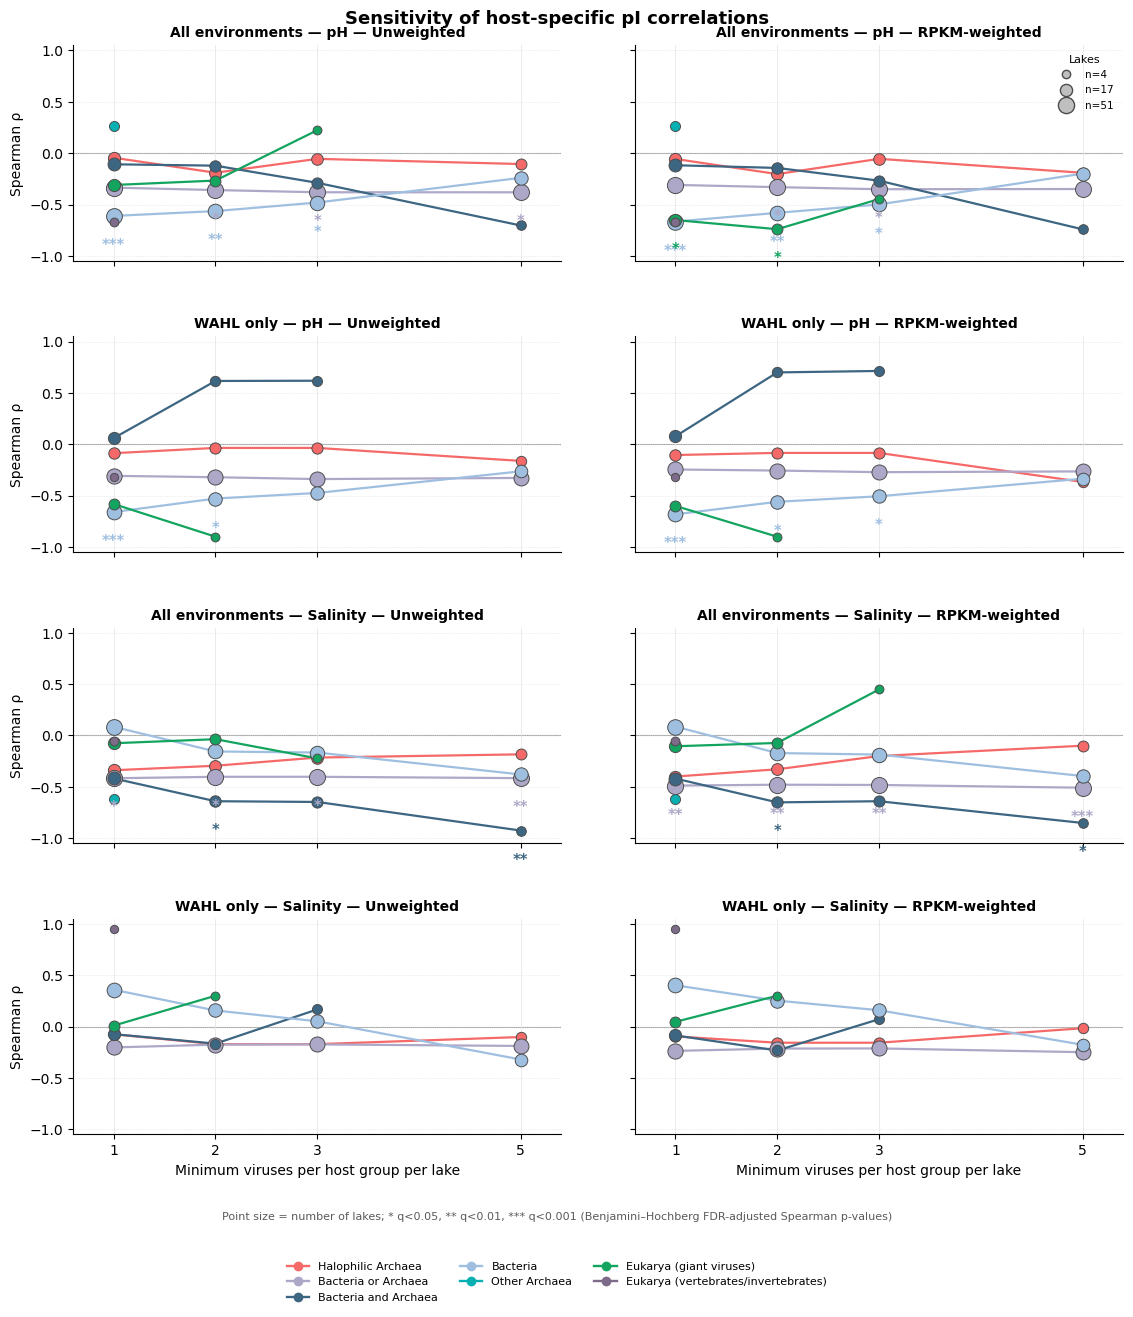


Saved:
/Users/skoog/Desktop/Supplementary_Fig4_all_and_WAHL_host_sensitivity_FDR.png
/Users/skoog/Desktop/Supplementary_Fig4_all_and_WAHL_host_sensitivity_FDR.svg


In [32]:
# ===== SUPPLEMENTARY FIG. 4: ALL-ENVIRONMENT + WAHL HOST SENSITIVITY SWEEP =====
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from IPython.display import display

OUTDIR = "/Users/skoog/Desktop/"
os.makedirs(OUTDIR,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","svg.fonttype":"none","text.usetex":False})

PICOL,WEIGHT_COL = "Median_pI","rpkm"
THRESHOLDS = (1,2,3,5)
MIN_LAKES_FOR_TEST = 4
SCOPES = ("All environments","WAHL only")
WEIGHTINGS = ("Unweighted median","RPKM-weighted median")

SENS_GROUPS = (
    "Halophilic Archaea",
    "Bacteria or Archaea",
    "Bacteria and Archaea",
    "Bacteria",
    "Other Archaea",
    "Eukarya (giant viruses)",
    "Eukarya (vertebrates/invertebrates)"
)

DEFAULT_HOST_COLORS = {
    "Halophilic Archaea":"#FF6868",
    "Bacteria or Archaea":"#AEA8C8",
    "Bacteria and Archaea":"#416A82",
    "Bacteria":"#9FC2E3",
    "Other Archaea":"#11B4B2",
    "Eukarya (giant viruses)":"#12A45D",
    "Eukarya (vertebrates/invertebrates)":"#7D6B89"
}

_existing_palette = globals().get("HOST_COLORS",globals().get("HOST_PALETTE",{}))
HOST_COLORS_SENS = {g:_existing_palette.get(g,DEFAULT_HOST_COLORS[g]) for g in SENS_GROUPS}

def _normalize_host(value):
    value = str(value).strip()
    return {
        "Eukarya (vertebrates/ invertebrates)":"Eukarya (vertebrates/invertebrates)",
        "Eukarya (vertebrates / invertebrates)":"Eukarya (vertebrates/invertebrates)",
        "Thermophilic Archaea":"Other Archaea",
        "Methanogen Archaea":"Other Archaea"
    }.get(value,value)

def _is_true(value):
    if pd.isna(value): return False
    if isinstance(value,(bool,np.bool_)): return bool(value)
    return str(value).strip().lower() in {"true","1","yes","y"}

def _safe_median(values):
    values = pd.to_numeric(pd.Series(values),errors="coerce").dropna().to_numpy(float)
    return float(np.median(values)) if len(values) else np.nan

def _weighted_median(values,weights):
    values,weights = np.asarray(values,float),np.asarray(weights,float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values,weights = values[keep],weights[keep]
    if not len(values): return np.nan
    order = np.argsort(values)
    values,weights = values[order],weights[order]
    cumulative = (np.cumsum(weights)-0.5*weights)/weights.sum()
    return float(np.interp(0.5,cumulative,values))

def _sens_group_iphop(row):
    if not _is_true(row.get("has_iphop",False)): return np.nan

    direct = np.nan
    if callable(globals().get("_host_group_iphop")):
        try: direct = _normalize_host(_host_group_iphop(row))
        except Exception: direct = np.nan

    ecology = _normalize_host(row.get("Host_ecology",row.get("Host_broad","Unknown/Other")))
    existing = _normalize_host(row.get("Host_group","Unknown/Other"))
    domain = str(row.get("host_domain","")).strip()
    phylum = str(row.get("host_phylum","")).strip()

    if direct in SENS_GROUPS: return direct
    if direct == "Bacteria" or domain == "Bacteria": return "Bacteria"
    if direct in {"Archaea","Other Archaea"} or domain == "Archaea":
        return "Halophilic Archaea" if phylum == "Halobacteriota" else "Other Archaea"
    if direct == "Eukarya" or domain in {"Eukarya","Eukaryota"}:
        if ecology in {"Eukarya (giant viruses)","Eukarya (vertebrates/invertebrates)"}: return ecology
        if existing in {"Eukarya (giant viruses)","Eukarya (vertebrates/invertebrates)"}: return existing
        return "Eukarya (giant viruses)"
    return np.nan

def _sens_group_combined(row):
    if _is_true(row.get("has_iphop",False)):
        return _sens_group_iphop(row)

    family = str(row.get("family","")).strip().casefold()
    ecology = _normalize_host(row.get("Host_ecology",row.get("Host_broad","Unknown/Other")))
    existing = _normalize_host(row.get("Host_group","Unknown/Other"))

    if family == "unclassified caudoviricetes": return "Bacteria or Archaea"
    if ecology == "Halophilic Archaea": return "Halophilic Archaea"
    if ecology in {"Thermophilic Archaea","Other Archaea","Methanogen Archaea"}: return "Other Archaea"
    if ecology == "Bacteria": return "Bacteria"
    if ecology == "Eukarya (giant viruses)": return "Eukarya (giant viruses)"
    if ecology == "Eukarya (vertebrates/invertebrates)": return "Eukarya (vertebrates/invertebrates)"
    if ecology in {"Bacteria and Archaea","Bacteria or Archaea"}: return ecology
    if existing in SENS_GROUPS: return existing
    return np.nan

def _prepare_sensitivity_data(host_df):
    d = host_df.copy()
    required = [PICOL,"pH","Salinity",WEIGHT_COL,"family","has_iphop",
                "Host_group","Environment_Bin","name_full"]
    missing = [c for c in required if c not in d.columns]
    if missing: raise KeyError(f"Missing required columns: {missing}")

    if "Host_ecology" not in d.columns:
        if isinstance(globals().get("host_ecology"),dict):
            d["Host_ecology"] = d["family"].astype(str).str.strip().map(host_ecology).fillna("Unknown/Other")
        elif "Host_broad" in d.columns:
            d["Host_ecology"] = d["Host_broad"]
        else:
            d["Host_ecology"] = "Unknown/Other"

    for c in [PICOL,"pH","Salinity",WEIGHT_COL]:
        d[c] = pd.to_numeric(d[c],errors="coerce")

    d["host_group_sensitivity"] = d.apply(_sens_group_combined,axis=1)
    d = d[d["host_group_sensitivity"].isin(SENS_GROUPS)].copy()
    d = d.dropna(subset=[PICOL,"name_full","host_group_sensitivity"])

    id_col = next((c for c in ["contig_id","virus_id","genome_id","sequence_id"] if c in d.columns),None)
    if id_col: d = d.drop_duplicates(subset=[id_col,"name_full"])

    print("\nViruses retained across all environments:")
    print(d["host_group_sensitivity"].value_counts().reindex(SENS_GROUPS,fill_value=0).to_string())
    return d

def _subset_scope(d,scope):
    if scope == "All environments": return d.copy()
    if scope == "WAHL only":
        return d[d["Environment_Bin"].astype(str).str.upper()
                 .str.contains("WATL|WAHL",regex=True,na=False)].copy()
    raise ValueError(f"Unknown scope: {scope}")

def _summarize_host_lakes(d,weighting):
    rows = []
    for (group,lake),g in d.groupby(["host_group_sensitivity","name_full"],sort=False):
        pi = _safe_median(g[PICOL]) if weighting == "Unweighted median" else \
             _weighted_median(g[PICOL].to_numpy(float),g[WEIGHT_COL].to_numpy(float))

        rows.append({
            "host_group":group,
            "name_full":lake,
            "weighting":weighting,
            "pI":pi,
            "pH":_safe_median(g["pH"]),
            "Salinity":_safe_median(g["Salinity"]),
            "n_viruses":int(len(g)),
            "total_RPKM":float(g[WEIGHT_COL].where(g[WEIGHT_COL] > 0).sum())
        })

    out = pd.DataFrame(rows)
    return out.dropna(subset=["pI"]).reset_index(drop=True) if len(out) else out

def build_sensitivity_sweep(host_df):
    prepared = _prepare_sensitivity_data(host_df)
    test_rows,lake_frames = [],[]

    for scope in SCOPES:
        scoped = _subset_scope(prepared,scope)

        print(f"\n{scope} — lakes represented by host group:")
        print(scoped.groupby("host_group_sensitivity")["name_full"].nunique()
              .reindex(SENS_GROUPS,fill_value=0).to_string())

        for weighting in WEIGHTINGS:
            lake_all = _summarize_host_lakes(scoped,weighting)
            if lake_all.empty: continue

            lake_all.insert(0,"scope",scope)
            lake_all.insert(1,"scheme","iPHoP-prioritized + family-inferred")

            for threshold in THRESHOLDS:
                lake_all[f"eligible_n{threshold}"] = lake_all["n_viruses"] >= threshold

            lake_frames.append(lake_all)

            for threshold in THRESHOLDS:
                eligible = lake_all[lake_all["n_viruses"] >= threshold]

                for group in SENS_GROUPS:
                    group_data = eligible[eligible["host_group"] == group]

                    for predictor in ("pH","Salinity"):
                        test = group_data.dropna(subset=["pI",predictor])
                        n_lakes,rho,p_raw = len(test),np.nan,np.nan

                        if n_lakes >= MIN_LAKES_FOR_TEST and test["pI"].nunique() > 1 and test[predictor].nunique() > 1:
                            result = spearmanr(test["pI"].to_numpy(float),test[predictor].to_numpy(float))
                            rho,p_raw = float(result.statistic),float(result.pvalue)

                        test_rows.append({
                            "scope":scope,
                            "scheme":"iPHoP-prioritized + family-inferred",
                            "weighting":weighting,
                            "threshold":threshold,
                            "host_group":group,
                            "predictor":predictor,
                            "n_lakes":int(n_lakes),
                            "n_viruses_total":int(test["n_viruses"].sum()) if n_lakes else 0,
                            "minimum_viruses_per_lake":int(test["n_viruses"].min()) if n_lakes else np.nan,
                            "median_viruses_per_lake":float(test["n_viruses"].median()) if n_lakes else np.nan,
                            "maximum_viruses_per_lake":int(test["n_viruses"].max()) if n_lakes else np.nan,
                            "lake_virus_counts":"; ".join(
                                f"{r.name_full}:{int(r.n_viruses)}"
                                for r in test.sort_values("name_full").itertuples()
                            ),
                            "rho":rho,
                            "p_raw":p_raw
                        })

    tests = pd.DataFrame(test_rows)
    lakes = pd.concat(lake_frames,ignore_index=True) if lake_frames else pd.DataFrame()
    tests["q_fdr"] = np.nan

    # BH-FDR across host groups within each scope × weighting × threshold × predictor.
    for _,idx in tests.groupby(["scope","weighting","threshold","predictor"]).groups.items():
        idx = np.asarray(list(idx),int)
        p = tests.loc[idx,"p_raw"].to_numpy(float)
        valid = np.isfinite(p)

        if valid.any():
            tests.loc[idx[valid],"q_fdr"] = multipletests(
                p[valid],method="fdr_bh"
            )[1]

    test_csv = os.path.join(OUTDIR,"Supplementary_Fig4_host_sensitivity_all_and_WAHL_tests.csv")
    lake_csv = os.path.join(OUTDIR,"Supplementary_Fig4_host_sensitivity_all_and_WAHL_lake_inputs.csv")
    xlsx = os.path.join(OUTDIR,"Supplementary_Fig4_host_sensitivity_all_and_WAHL.xlsx")

    tests.to_csv(test_csv,index=False)
    lakes.to_csv(lake_csv,index=False)

    with pd.ExcelWriter(xlsx,engine="openpyxl") as writer:
        tests.to_excel(writer,sheet_name="sensitivity_tests",index=False)
        lakes.to_excel(writer,sheet_name="lake_level_inputs",index=False)
        tests[tests["scope"] == "All environments"].to_excel(
            writer,sheet_name="all_environment_tests",index=False
        )
        tests[tests["scope"] == "WAHL only"].to_excel(
            writer,sheet_name="WAHL_tests",index=False
        )

    display(
        tests[["scope","weighting","threshold","host_group","predictor",
               "n_lakes","n_viruses_total","rho","p_raw","q_fdr"]]
        .sort_values(["scope","predictor","weighting","host_group","threshold"])
        .round(4)
    )

    print("\nSaved:")
    print(test_csv)
    print(lake_csv)
    print(xlsx)
    return tests,lakes

def _q_stars(q):
    if pd.isna(q): return ""
    if q < 0.001: return "***"
    if q < 0.01: return "**"
    if q < 0.05: return "*"
    return ""

def plot_sensitivity_sweep(tests,out_stem):
    plot_data = tests.copy()
    valid_n = plot_data.loc[
        plot_data["rho"].notna() & (plot_data["n_lakes"] > 0),"n_lakes"
    ].to_numpy(float)

    n_min = int(np.nanmin(valid_n)) if len(valid_n) else 1
    n_max = int(np.nanmax(valid_n)) if len(valid_n) else 1

    def point_size(n):
        if n_max <= n_min: return 65
        scaled = (np.sqrt(float(n))-np.sqrt(n_min))/(np.sqrt(n_max)-np.sqrt(n_min))
        return 36+100*scaled

    specs = [
        ("All environments","pH","Unweighted median"),
        ("All environments","pH","RPKM-weighted median"),
        ("WAHL only","pH","Unweighted median"),
        ("WAHL only","pH","RPKM-weighted median"),
        ("All environments","Salinity","Unweighted median"),
        ("All environments","Salinity","RPKM-weighted median"),
        ("WAHL only","Salinity","Unweighted median"),
        ("WAHL only","Salinity","RPKM-weighted median")
    ]

    fig,axes = plt.subplots(4,2,figsize=(11.8,13.2),sharex=True,sharey=True)

    for ax,(scope,predictor,weighting) in zip(axes.flat,specs):
        panel = plot_data[
            (plot_data["scope"] == scope) &
            (plot_data["predictor"] == predictor) &
            (plot_data["weighting"] == weighting)
        ]

        ax.axhline(0,color="0.65",lw=0.8,zorder=0)
        for threshold in THRESHOLDS:
            ax.axvline(threshold,color="0.91",lw=0.6,zorder=0)

        for group in SENS_GROUPS:
            g = panel[panel["host_group"] == group].sort_values("threshold").dropna(subset=["rho"])
            if g.empty: continue

            x = g["threshold"].to_numpy(float)
            y = g["rho"].to_numpy(float)
            color = HOST_COLORS_SENS[group]
            ax.plot(x,y,color=color,lw=1.6,zorder=2)

            for r in g.itertuples():
                ax.scatter(
                    float(r.threshold),float(r.rho),
                    s=point_size(r.n_lakes),
                    marker="o",
                    facecolor=color,
                    edgecolor="0.3",
                    lw=0.7,
                    zorder=4
                )

                stars = _q_stars(r.q_fdr)
                if stars:
                    offset = 8 if r.rho >= 0 else -15
                    va = "bottom" if r.rho >= 0 else "top"

                    ax.annotate(
                        stars,
                        (float(r.threshold),float(r.rho)),
                        xytext=(0,offset),
                        textcoords="offset points",
                        ha="center",
                        va=va,
                        fontsize=10.5,
                        fontweight="bold",
                        color=color,
                        clip_on=False,
                        zorder=6
                    )

        ax.set_title(
            f"{scope} — {predictor} — {weighting.replace(' median','')}",
            fontsize=10,
            fontweight="bold"
        )
        ax.set_xticks(THRESHOLDS)
        ax.set_xlim(0.6,5.4)
        ax.set_ylim(-1.05,1.05)
        ax.grid(axis="y",ls=":",lw=0.5,color="0.87")
        ax.set_axisbelow(True)

        for spine in ("top","right"):
            ax.spines[spine].set_visible(False)

    for row in range(4):
        axes[row,0].set_ylabel("Spearman ρ")

    axes[3,0].set_xlabel("Minimum viruses per host group per lake")
    axes[3,1].set_xlabel("Minimum viruses per host group per lake")

    host_handles = [
        Line2D([],[],color=HOST_COLORS_SENS[g],marker="o",lw=1.7,ms=6,label=g)
        for g in SENS_GROUPS
    ]

    fig.legend(
        handles=host_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5,0.005)
    )

    if len(valid_n):
        refs = sorted(set([
            int(np.nanmin(valid_n)),
            int(np.nanmedian(valid_n)),
            int(np.nanmax(valid_n))
        ]))

        axes[0,1].legend(
            handles=[
                Line2D(
                    [],[],
                    marker="o",
                    ls="None",
                    markersize=np.sqrt(point_size(n)),
                    markerfacecolor="0.75",
                    markeredgecolor="0.3",
                    label=f"n={n}"
                )
                for n in refs
            ],
            title="Lakes",
            loc="upper right",
            frameon=False,
            fontsize=7.5,
            title_fontsize=8
        )

    fig.suptitle(
        "Sensitivity of host-specific pI correlations",
        fontsize=13,
        fontweight="bold",
        y=0.992
    )

    fig.text(
        0.5,0.075,
        "Point size = number of lakes; * q<0.05, ** q<0.01, *** q<0.001 "
        "(Benjamini–Hochberg FDR-adjusted Spearman p-values)",
        ha="center",
        fontsize=8,
        color="0.35"
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.98,
        top=0.965,
        bottom=0.14,
        wspace=0.15,
        hspace=0.35
    )

    png_path = out_stem+".png"
    svg_path = out_stem+".svg"

    fig.savefig(png_path,dpi=300,bbox_inches="tight")
    fig.savefig(svg_path,format="svg",bbox_inches="tight")
    plt.show()

    print("\nSaved:")
    print(png_path)
    print(svg_path)

host_sensitivity_all,host_sensitivity_lake_inputs = build_sensitivity_sweep(host_df_all)

plot_sensitivity_sweep(
    host_sensitivity_all,
    os.path.join(OUTDIR,"Supplementary_Fig4_all_and_WAHL_host_sensitivity_FDR")
)

Rows excluded because host identity was mixed, unresolved, or unsupported: 7,724

Viruses retained across all environments:
host_group_sensitivity
Halophilic Archaea                     128
Bacteria                               925
Other Archaea                           12
Eukarya (giant viruses)                 69
Eukarya (vertebrates/invertebrates)      6

All environments — lakes represented by host group:
host_group_sensitivity
Halophilic Archaea                     17
Bacteria                               46
Other Archaea                           8
Eukarya (giant viruses)                17
Eukarya (vertebrates/invertebrates)     5

WAHL only — lakes represented by host group:
host_group_sensitivity
Halophilic Archaea                     13
Bacteria                               35
Other Archaea                           4
Eukarya (giant viruses)                11
Eukarya (vertebrates/invertebrates)     4


,scope,weighting,threshold,host_group,predictor,n_lakes,n_viruses_total,rho,p_raw,q_fdr
43,All environments,RPKM-weighted median,1,Bacteria,Salinity,44,923,0.0856,0.5805,0.8582
53,All environments,RPKM-weighted median,2,Bacteria,Salinity,34,913,-0.1719,0.3311,0.4966
63,All environments,RPKM-weighted median,3,Bacteria,Salinity,32,909,-0.1866,0.3066,0.4911
73,All environments,RPKM-weighted median,5,Bacteria,Salinity,24,880,-0.3954,0.0558,0.1117
47,All environments,RPKM-weighted median,1,Eukarya (giant viruses),Salinity,17,69,-0.1057,0.6865,0.8582
...,...,...,...,...,...,...,...,...,...,...
110,WAHL only,Unweighted median,5,Halophilic Archaea,pH,9,101,-0.1617,0.6776,0.6776
84,WAHL only,Unweighted median,1,Other Archaea,pH,4,4,NaN,NaN,NaN
94,WAHL only,Unweighted median,2,Other Archaea,pH,0,0,NaN,NaN,NaN
104,WAHL only,Unweighted median,3,Other Archaea,pH,0,0,NaN,NaN,NaN



Saved:
/Users/skoog/Desktop/Supplementary_Fig4_resolved_host_sensitivity_tests.csv
/Users/skoog/Desktop/Supplementary_Fig4_resolved_host_sensitivity_lake_inputs.csv
/Users/skoog/Desktop/Supplementary_Fig4_resolved_host_sensitivity.xlsx


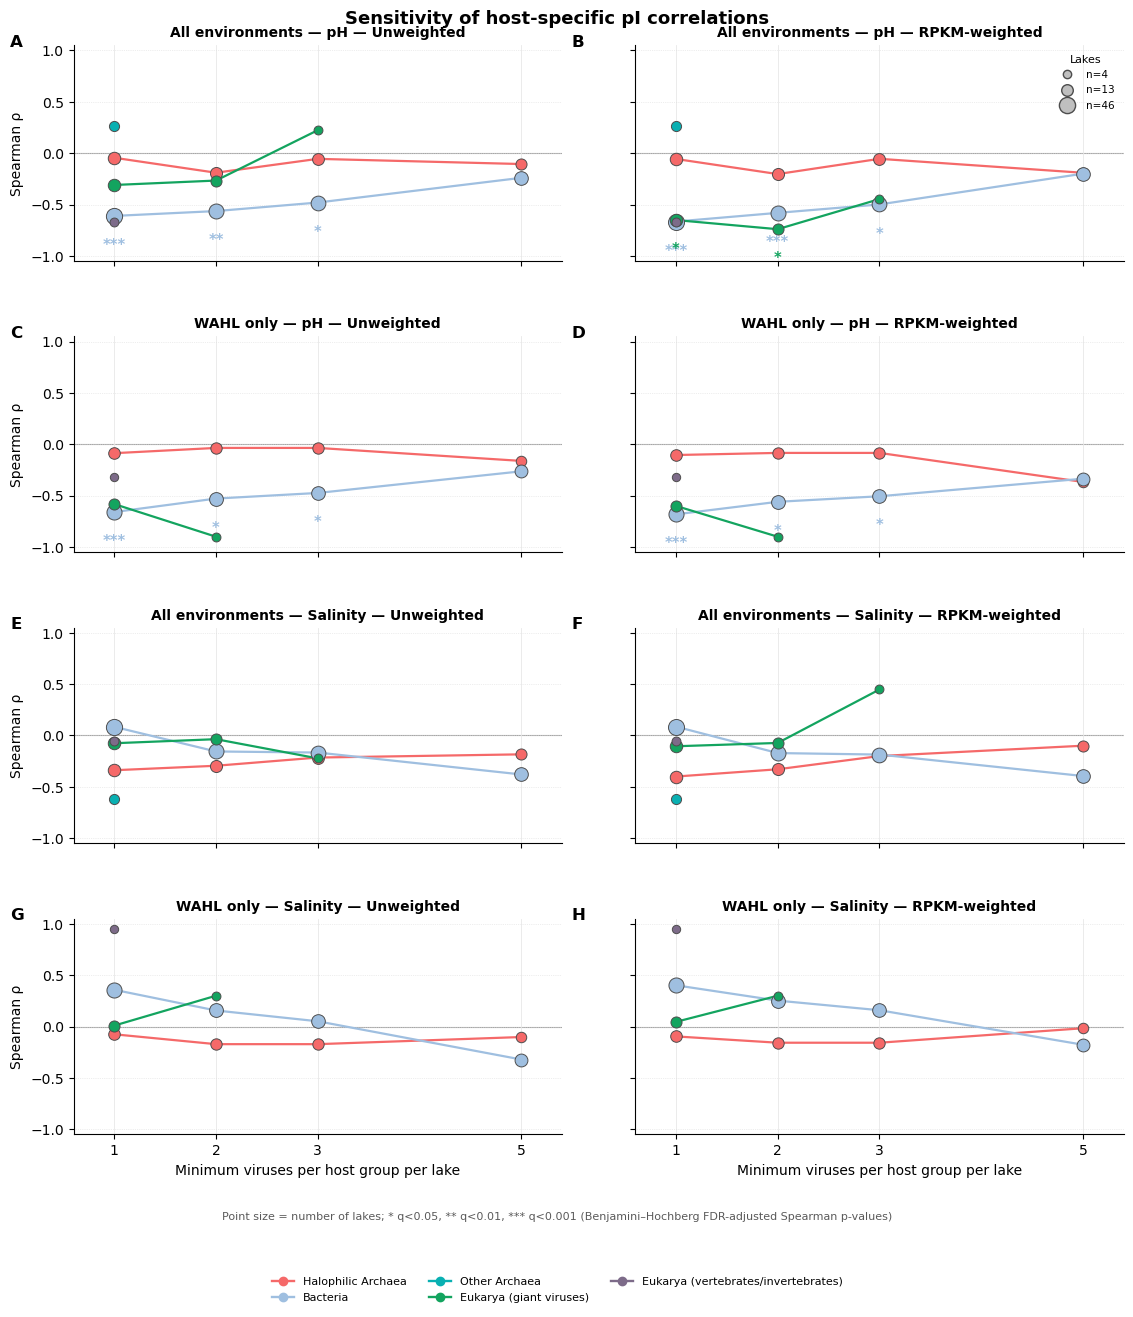


Saved:
/Users/skoog/Desktop/Supplementary_Fig4_resolved_hosts_all_and_WAHL_FDR.png
/Users/skoog/Desktop/Supplementary_Fig4_resolved_hosts_all_and_WAHL_FDR.svg


In [30]:
# SENSITIVITY SWEEP FOR  HOST GROUPS 
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from IPython.display import display

OUTDIR = "/Users/skoog/Desktop/"
os.makedirs(OUTDIR,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","svg.fonttype":"none","text.usetex":False})

PICOL,WEIGHT_COL = "Median_pI","rpkm"
THRESHOLDS = (1,2,3,5)
MIN_LAKES_FOR_TEST = 4
SCOPES = ("All environments","WAHL only")
WEIGHTINGS = ("Unweighted median","RPKM-weighted median")

SENS_GROUPS = (
    "Halophilic Archaea",
    "Bacteria",
    "Other Archaea",
    "Eukarya (giant viruses)",
    "Eukarya (vertebrates/invertebrates)"
)
EXCLUDED_GROUPS = {"Bacteria or Archaea","Bacteria and Archaea"}

DEFAULT_HOST_COLORS = {
    "Halophilic Archaea":"#FF6868",
    "Bacteria":"#9FC2E3",
    "Other Archaea":"#11B4B2",
    "Eukarya (giant viruses)":"#12A45D",
    "Eukarya (vertebrates/invertebrates)":"#7D6B89"
}
_existing_palette = globals().get("HOST_COLORS",globals().get("HOST_PALETTE",{}))
HOST_COLORS_SENS = {g:_existing_palette.get(g,DEFAULT_HOST_COLORS[g]) for g in SENS_GROUPS}

def _normalize_host(value):
    value = str(value).strip()
    return {
        "Eukarya (vertebrates/ invertebrates)":"Eukarya (vertebrates/invertebrates)",
        "Eukarya (vertebrates / invertebrates)":"Eukarya (vertebrates/invertebrates)",
        "Thermophilic Archaea":"Other Archaea",
        "Methanogen Archaea":"Other Archaea"
    }.get(value,value)

def _is_true(value):
    if pd.isna(value): return False
    if isinstance(value,(bool,np.bool_)): return bool(value)
    return str(value).strip().lower() in {"true","1","yes","y"}

def _safe_median(values):
    values = pd.to_numeric(pd.Series(values),errors="coerce").dropna().to_numpy(float)
    return float(np.median(values)) if len(values) else np.nan

def _weighted_median(values,weights):
    values,weights = np.asarray(values,float),np.asarray(weights,float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values,weights = values[keep],weights[keep]
    if not len(values): return np.nan
    order = np.argsort(values)
    values,weights = values[order],weights[order]
    cumulative = (np.cumsum(weights)-0.5*weights)/weights.sum()
    return float(np.interp(0.5,cumulative,values))

def _sens_group_iphop(row):
    if not _is_true(row.get("has_iphop",False)): return np.nan

    direct = np.nan
    if callable(globals().get("_host_group_iphop")):
        try: direct = _normalize_host(_host_group_iphop(row))
        except Exception: direct = np.nan

    ecology = _normalize_host(row.get("Host_ecology",row.get("Host_broad","Unknown/Other")))
    existing = _normalize_host(row.get("Host_group","Unknown/Other"))
    domain = str(row.get("host_domain","")).strip()
    phylum = str(row.get("host_phylum","")).strip()

    if direct in EXCLUDED_GROUPS: return np.nan
    if direct in SENS_GROUPS: return direct
    if direct == "Bacteria" or domain == "Bacteria": return "Bacteria"
    if direct in {"Archaea","Other Archaea"} or domain == "Archaea":
        return "Halophilic Archaea" if phylum == "Halobacteriota" else "Other Archaea"
    if direct == "Eukarya" or domain in {"Eukarya","Eukaryota"}:
        if ecology in SENS_GROUPS: return ecology
        if existing in SENS_GROUPS: return existing
        return "Eukarya (giant viruses)"
    return np.nan

def _sens_group_combined(row):
    if _is_true(row.get("has_iphop",False)):
        return _sens_group_iphop(row)

    family = str(row.get("family","")).strip().casefold()
    ecology = _normalize_host(row.get("Host_ecology",row.get("Host_broad","Unknown/Other")))
    existing = _normalize_host(row.get("Host_group","Unknown/Other"))

    if family == "unclassified caudoviricetes": return np.nan
    if ecology in EXCLUDED_GROUPS or existing in EXCLUDED_GROUPS: return np.nan

    if ecology == "Halophilic Archaea": return "Halophilic Archaea"
    if ecology in {"Thermophilic Archaea","Other Archaea","Methanogen Archaea"}: return "Other Archaea"
    if ecology == "Bacteria": return "Bacteria"
    if ecology == "Eukarya (giant viruses)": return "Eukarya (giant viruses)"
    if ecology == "Eukarya (vertebrates/invertebrates)": return "Eukarya (vertebrates/invertebrates)"
    if existing in SENS_GROUPS: return existing
    return np.nan

def _prepare_sensitivity_data(host_df):
    d = host_df.copy()
    required = [PICOL,"pH","Salinity",WEIGHT_COL,"family","has_iphop",
                "Host_group","Environment_Bin","name_full"]
    missing = [c for c in required if c not in d.columns]
    if missing: raise KeyError(f"Missing required columns: {missing}")

    if "Host_ecology" not in d.columns:
        if isinstance(globals().get("host_ecology"),dict):
            d["Host_ecology"] = d["family"].astype(str).str.strip().map(host_ecology).fillna("Unknown/Other")
        elif "Host_broad" in d.columns:
            d["Host_ecology"] = d["Host_broad"]
        else:
            d["Host_ecology"] = "Unknown/Other"

    for c in [PICOL,"pH","Salinity",WEIGHT_COL]:
        d[c] = pd.to_numeric(d[c],errors="coerce")

    d["host_group_sensitivity"] = d.apply(_sens_group_combined,axis=1)
    excluded_n = int(d["host_group_sensitivity"].isna().sum())
    d = d[d["host_group_sensitivity"].isin(SENS_GROUPS)].copy()
    d = d.dropna(subset=[PICOL,"name_full","host_group_sensitivity"])

    id_col = next((c for c in ["contig_id","virus_id","genome_id","sequence_id"] if c in d.columns),None)
    if id_col: d = d.drop_duplicates(subset=[id_col,"name_full"])

    print(f"Rows excluded because host identity was mixed, unresolved, or unsupported: {excluded_n:,}")
    print("\nViruses retained across all environments:")
    print(d["host_group_sensitivity"].value_counts().reindex(SENS_GROUPS,fill_value=0).to_string())
    return d

def _subset_scope(d,scope):
    if scope == "All environments": return d.copy()
    if scope == "WAHL only":
        return d[d["Environment_Bin"].astype(str).str.upper()
                 .str.contains("WATL|WAHL",regex=True,na=False)].copy()
    raise ValueError(f"Unknown scope: {scope}")

def _summarize_host_lakes(d,weighting):
    rows = []
    for (group,lake),g in d.groupby(["host_group_sensitivity","name_full"],sort=False):
        if weighting == "Unweighted median":
            pi = _safe_median(g[PICOL])
        else:
            pi = _weighted_median(g[PICOL].to_numpy(float),g[WEIGHT_COL].to_numpy(float))

        rows.append({
            "host_group":group,
            "name_full":lake,
            "weighting":weighting,
            "pI":pi,
            "pH":_safe_median(g["pH"]),
            "Salinity":_safe_median(g["Salinity"]),
            "n_viruses":int(len(g)),
            "total_RPKM":float(g[WEIGHT_COL].where(g[WEIGHT_COL] > 0).sum())
        })

    out = pd.DataFrame(rows)
    return out.dropna(subset=["pI"]).reset_index(drop=True) if len(out) else out

def build_sensitivity_sweep(host_df):
    prepared = _prepare_sensitivity_data(host_df)
    test_rows,lake_frames = [],[]

    for scope in SCOPES:
        scoped = _subset_scope(prepared,scope)

        print(f"\n{scope} — lakes represented by host group:")
        print(scoped.groupby("host_group_sensitivity")["name_full"].nunique()
              .reindex(SENS_GROUPS,fill_value=0).to_string())

        for weighting in WEIGHTINGS:
            lake_all = _summarize_host_lakes(scoped,weighting)
            if lake_all.empty: continue

            lake_all.insert(0,"scope",scope)
            lake_all.insert(1,"scheme","iPHoP-prioritized + family-inferred; resolved hosts only")

            for threshold in THRESHOLDS:
                lake_all[f"eligible_n{threshold}"] = lake_all["n_viruses"] >= threshold
            lake_frames.append(lake_all)

            for threshold in THRESHOLDS:
                eligible = lake_all[lake_all["n_viruses"] >= threshold]

                for group in SENS_GROUPS:
                    group_data = eligible[eligible["host_group"] == group]

                    for predictor in ("pH","Salinity"):
                        test = group_data.dropna(subset=["pI",predictor])
                        n_lakes,rho,p_raw = len(test),np.nan,np.nan

                        if n_lakes >= MIN_LAKES_FOR_TEST and test["pI"].nunique() > 1 and test[predictor].nunique() > 1:
                            result = spearmanr(test["pI"].to_numpy(float),test[predictor].to_numpy(float))
                            rho,p_raw = float(result.statistic),float(result.pvalue)

                        test_rows.append({
                            "scope":scope,
                            "scheme":"iPHoP-prioritized + family-inferred; resolved hosts only",
                            "weighting":weighting,
                            "threshold":threshold,
                            "host_group":group,
                            "predictor":predictor,
                            "n_lakes":int(n_lakes),
                            "n_viruses_total":int(test["n_viruses"].sum()) if n_lakes else 0,
                            "minimum_viruses_per_lake":int(test["n_viruses"].min()) if n_lakes else np.nan,
                            "median_viruses_per_lake":float(test["n_viruses"].median()) if n_lakes else np.nan,
                            "maximum_viruses_per_lake":int(test["n_viruses"].max()) if n_lakes else np.nan,
                            "lake_virus_counts":"; ".join(
                                f"{r.name_full}:{int(r.n_viruses)}"
                                for r in test.sort_values("name_full").itertuples()
                            ),
                            "rho":rho,
                            "p_raw":p_raw
                        })

    tests = pd.DataFrame(test_rows)
    lakes = pd.concat(lake_frames,ignore_index=True) if lake_frames else pd.DataFrame()
    tests["q_fdr"] = np.nan

    for _,idx in tests.groupby(["scope","weighting","threshold","predictor"]).groups.items():
        idx = np.asarray(list(idx),int)
        p = tests.loc[idx,"p_raw"].to_numpy(float)
        valid = np.isfinite(p)
        if valid.any():
            tests.loc[idx[valid],"q_fdr"] = multipletests(p[valid],method="fdr_bh")[1]

    test_csv = os.path.join(OUTDIR,"Supplementary_Fig4_resolved_host_sensitivity_tests.csv")
    lake_csv = os.path.join(OUTDIR,"Supplementary_Fig4_resolved_host_sensitivity_lake_inputs.csv")
    xlsx = os.path.join(OUTDIR,"Supplementary_Fig4_resolved_host_sensitivity.xlsx")

    tests.to_csv(test_csv,index=False)
    lakes.to_csv(lake_csv,index=False)

    with pd.ExcelWriter(xlsx,engine="openpyxl") as writer:
        tests.to_excel(writer,sheet_name="sensitivity_tests",index=False)
        lakes.to_excel(writer,sheet_name="lake_level_inputs",index=False)
        tests[tests["scope"] == "All environments"].to_excel(
            writer,sheet_name="all_environment_tests",index=False
        )
        tests[tests["scope"] == "WAHL only"].to_excel(
            writer,sheet_name="WAHL_tests",index=False
        )

    display(
        tests[["scope","weighting","threshold","host_group","predictor",
               "n_lakes","n_viruses_total","rho","p_raw","q_fdr"]]
        .sort_values(["scope","predictor","weighting","host_group","threshold"])
        .round(4)
    )

    print("\nSaved:")
    print(test_csv)
    print(lake_csv)
    print(xlsx)
    return tests,lakes

def _q_stars(q):
    if pd.isna(q): return ""
    if q < 0.001: return "***"
    if q < 0.01: return "**"
    if q < 0.05: return "*"
    return ""

def plot_sensitivity_sweep(tests,out_stem):
    plot_data = tests.copy()
    valid_n = plot_data.loc[
        plot_data["rho"].notna() & (plot_data["n_lakes"] > 0),"n_lakes"
    ].to_numpy(float)

    n_min = int(np.nanmin(valid_n)) if len(valid_n) else 1
    n_max = int(np.nanmax(valid_n)) if len(valid_n) else 1

    def point_size(n):
        if n_max <= n_min: return 65
        scaled = (np.sqrt(float(n))-np.sqrt(n_min))/(np.sqrt(n_max)-np.sqrt(n_min))
        return 36+100*scaled

    specs = [
        ("All environments","pH","Unweighted median"),
        ("All environments","pH","RPKM-weighted median"),
        ("WAHL only","pH","Unweighted median"),
        ("WAHL only","pH","RPKM-weighted median"),
        ("All environments","Salinity","Unweighted median"),
        ("All environments","Salinity","RPKM-weighted median"),
        ("WAHL only","Salinity","Unweighted median"),
        ("WAHL only","Salinity","RPKM-weighted median")
    ]

    fig,axes = plt.subplots(4,2,figsize=(11.8,13.2),sharex=True,sharey=True)

    for panel_letter,(ax,(scope,predictor,weighting)) in enumerate(zip(axes.flat,specs)):
        panel = plot_data[
            (plot_data["scope"] == scope) &
            (plot_data["predictor"] == predictor) &
            (plot_data["weighting"] == weighting)
        ]

        ax.axhline(0,color="0.65",lw=0.8,zorder=0)
        for threshold in THRESHOLDS:
            ax.axvline(threshold,color="0.91",lw=0.6,zorder=0)

        for group in SENS_GROUPS:
            g = panel[panel["host_group"] == group].sort_values("threshold").dropna(subset=["rho"])
            if g.empty: continue

            x = g["threshold"].to_numpy(float)
            y = g["rho"].to_numpy(float)
            color = HOST_COLORS_SENS[group]
            ax.plot(x,y,color=color,lw=1.6,zorder=2)

            for r in g.itertuples():
                ax.scatter(float(r.threshold),float(r.rho),s=point_size(r.n_lakes),
                           marker="o",facecolor=color,edgecolor="0.3",lw=0.7,zorder=4)

                stars = _q_stars(r.q_fdr)
                if stars:
                    offset = 8 if r.rho >= 0 else -15
                    va = "bottom" if r.rho >= 0 else "top"
                    ax.annotate(stars,(float(r.threshold),float(r.rho)),xytext=(0,offset),
                                textcoords="offset points",ha="center",va=va,fontsize=10.5,
                                fontweight="bold",color=color,clip_on=False,zorder=6)

        ax.text(-0.13,1.05,chr(65+panel_letter),transform=ax.transAxes,
                fontsize=12,fontweight="bold",va="top")
        ax.set_title(f"{scope} — {predictor} — {weighting.replace(' median','')}",
                     fontsize=10,fontweight="bold")
        ax.set_xticks(THRESHOLDS)
        ax.set_xlim(0.6,5.4)
        ax.set_ylim(-1.05,1.05)
        ax.grid(axis="y",ls=":",lw=0.5,color="0.87")
        ax.set_axisbelow(True)
        for spine in ("top","right"): ax.spines[spine].set_visible(False)

    for row in range(4):
        axes[row,0].set_ylabel("Spearman ρ")

    axes[3,0].set_xlabel("Minimum viruses per host group per lake")
    axes[3,1].set_xlabel("Minimum viruses per host group per lake")

    host_handles = [
        Line2D([],[],color=HOST_COLORS_SENS[g],marker="o",lw=1.7,ms=6,label=g)
        for g in SENS_GROUPS
    ]
    fig.legend(handles=host_handles,loc="lower center",ncol=3,frameon=False,
               fontsize=8,bbox_to_anchor=(0.5,0.005))

    if len(valid_n):
        refs = sorted(set([
            int(np.nanmin(valid_n)),
            int(np.nanmedian(valid_n)),
            int(np.nanmax(valid_n))
        ]))
        axes[0,1].legend(
            handles=[
                Line2D([],[],marker="o",ls="None",markersize=np.sqrt(point_size(n)),
                       markerfacecolor="0.75",markeredgecolor="0.3",label=f"n={n}")
                for n in refs
            ],
            title="Lakes",loc="upper right",frameon=False,
            fontsize=7.5,title_fontsize=8
        )

    fig.suptitle("Sensitivity of host-specific pI correlations",
                 fontsize=13,fontweight="bold",y=0.992)
    fig.text(
        0.5,0.075,
        "Point size = number of lakes; * q<0.05, ** q<0.01, *** q<0.001 "
        "(Benjamini–Hochberg FDR-adjusted Spearman p-values)",
        ha="center",fontsize=8,color="0.35"
    )
    fig.subplots_adjust(left=0.09,right=0.98,top=0.965,bottom=0.14,
                        wspace=0.15,hspace=0.35)

    png_path = out_stem+".png"
    svg_path = out_stem+".svg"
    fig.savefig(png_path,dpi=300,bbox_inches="tight")
    fig.savefig(svg_path,format="svg",bbox_inches="tight")
    plt.show()

    print("\nSaved:")
    print(png_path)
    print(svg_path)

host_sensitivity_resolved,host_sensitivity_lake_inputs = build_sensitivity_sweep(host_df_all)

plot_sensitivity_sweep(
    host_sensitivity_resolved,
    os.path.join(OUTDIR,"Supplementary_Fig4_resolved_hosts_all_and_WAHL_FDR")
)